In [17]:

# ============================================================
# STEP 0: IMPORT REQUIRED LIBRARIES
# Project: Credit Card Customer Segmentation
# ============================================================

# 1. General Python libraries
import os
import warnings
from pathlib import Path

# 2. Data manipulation and numerical calculations
import numpy as np
import pandas as pd

# 3. Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Data preprocessing
from sklearn.preprocessing import StandardScaler

# 5. Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# 6. Clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

# 7. Hierarchical clustering and dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 8. Nearest-neighbour analysis for DBSCAN tuning
from sklearn.neighbors import NearestNeighbors

# 9. Model saving and loading
import joblib

# 10. Display tables and notebook outputs
from IPython.display import display

# ============================================================
# NOTEBOOK CONFIGURATION
# ============================================================

# Set a fixed seed for reproducible random operations.
RANDOM_STATE = 42

# Display warnings during development only when needed.
warnings.filterwarnings("default")

# Improve the default appearance of charts.
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

# Display all columns in DataFrames.
pd.set_option("display.max_columns", None)

# Make wide tables easier to inspect.
pd.set_option("display.width", 150)

# Display numerical values with consistent precision.
pd.set_option("display.precision", 3)

# Display plots directly inside the Jupyter Notebook.
%matplotlib inline

print("All project libraries imported successfully.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Project random seed:", RANDOM_STATE)
print("Notebook configuration completed.")

All project libraries imported successfully.
NumPy version: 2.3.2
Pandas version: 2.3.1
Project random seed: 42
Notebook configuration completed.


In [18]:
# =============================================================================
# PROJECT : CREDIT CARD CUSTOMER SEGMENTATION
# TECHNIQUE: UNSUPERVISED MACHINE LEARNING
# STEP 1  : DATA LOADING, QUALITY AUDIT & INITIAL INVESTIGATION
# VERSION : CLEAN / LOGICAL / EXAM-READY
# =============================================================================
#
#
# =============================================================================
# GLOBAL DISPLAY SETTINGS
# =============================================================================

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.3f}"
)


# =============================================================================
# 0.1 REPORT FORMATTING UTILITIES
# =============================================================================

WIDTH = 88


def print_header(title, subtitle=None):
    """Print a consistent report heading."""

    print("\n" + "=" * WIDTH)
    print(title.center(WIDTH))

    if subtitle:
        print(subtitle.center(WIDTH))

    print("=" * WIDTH)


def print_section(number, title):
    """Print a numbered section heading."""

    print(f"\n{'─' * WIDTH}")
    print(f"  {number}. {title}")
    print("─" * WIDTH)


def show_table(data, title=None, index=False):
    """Display a dataframe with an optional title."""

    if title:
        print(f"\n{title}")

    if isinstance(data, pd.Series):
        data = data.to_frame()

    if index:
        display(data)
    else:
        display(data.reset_index(drop=True))


# =============================================================================
# STEP 1
# DATA LOADING, QUALITY AUDIT & INITIAL INVESTIGATION
# =============================================================================

print_header(
    "CREDIT CARD CUSTOMER SEGMENTATION",
    "STEP 1 | DATA LOADING, QUALITY AUDIT & INITIAL INVESTIGATION"
)


# =============================================================================
# 1.1 DATASET LOADING
# =============================================================================

print_section("1.1", "DATASET LOADING")


FILE_NAME = "CC GENERAL.csv"


# Possible locations for the dataset.
candidate_paths = [

    Path.cwd() / FILE_NAME,

    Path.cwd() / "data" / FILE_NAME,

    Path.cwd() / "dataset" / FILE_NAME,

    Path.cwd().parent / FILE_NAME,

    Path.cwd().parent / "data" / FILE_NAME,

    Path.home() / FILE_NAME

]


csv_path = next(
    (
        path
        for path in candidate_paths
        if path.is_file()
    ),
    None
)


df_original = None
source_description = None


# -------------------------------------------------------------------------
# Optional ZIP archive fallback
# -------------------------------------------------------------------------

if csv_path is None:

    archive_candidates = [

        Path.cwd() / "archive.zip",

        Path.cwd().parent / "archive.zip",

        Path.cwd() / "data" / "archive.zip"

    ]


    archive_path = next(
        (
            path
            for path in archive_candidates
            if path.is_file()
        ),
        None
    )


    if archive_path is not None:

        with zipfile.ZipFile(
            archive_path,
            "r"
        ) as archive:

            matching_members = [

                name
                for name in archive.namelist()

                if Path(name).name.lower()
                == FILE_NAME.lower()

            ]


            if matching_members:

                selected_member = matching_members[0]


                with archive.open(
                    selected_member
                ) as file:

                    df_original = pd.read_csv(file)


                source_description = (
                    f"{archive_path} :: "
                    f"{selected_member}"
                )


# -------------------------------------------------------------------------
# Load CSV directly if found
# -------------------------------------------------------------------------

if csv_path is not None:

    df_original = pd.read_csv(csv_path)

    source_description = str(csv_path)


# -------------------------------------------------------------------------
# Validate loading
# -------------------------------------------------------------------------

if df_original is None:

    raise FileNotFoundError(

        f"Could not locate '{FILE_NAME}'.\n"

        "Place the CSV in the notebook folder, "
        "data/, dataset/, or provide a valid path."

    )


if df_original.empty:

    raise ValueError(
        "The loaded dataset is empty."
    )


print(f"Dataset source : {source_description}")
print(f"Rows           : {len(df_original):,}")
print(f"Columns        : {df_original.shape[1]:,}")


# =============================================================================
# 1.2 INITIAL DATA PREVIEW AND STRUCTURE
# =============================================================================

print_section(
    "1.2",
    "INITIAL DATA PREVIEW AND STRUCTURE"
)


print("\nFirst five records:")

display(
    df_original.head()
)


print("\nReproducible random sample:")

display(
    df_original.sample(
        n=min(5, len(df_original)),
        random_state=42
    )
)


print("\nDataset shape:")

print(
    f"Rows    : {df_original.shape[0]:,}"
)

print(
    f"Columns : {df_original.shape[1]:,}"
)


print("\nColumn names:")

for index, column in enumerate(
    df_original.columns,
    start=1
):

    print(
        f"{index:02d}. {column}"
    )


print("\nData types:")

display(
    df_original.dtypes
    .to_frame("Data Type")
)


# =============================================================================
# 1.3 BASIC DATA QUALITY AUDIT
# =============================================================================

print_section(
    "1.3",
    "BASIC DATA QUALITY AUDIT"
)


# -------------------------------------------------------------------------
# Duplicate rows
# -------------------------------------------------------------------------

duplicate_count = (
    df_original
    .duplicated()
    .sum()
)


duplicate_percentage = (

    duplicate_count
    / len(df_original)
    * 100

)


print(
    f"Duplicate rows     : "
    f"{duplicate_count:,}"
)


print(
    f"Duplicate %        : "
    f"{duplicate_percentage:.3f}%"
)


# -------------------------------------------------------------------------
# Missing values
# -------------------------------------------------------------------------

missing_count = (
    df_original
    .isna()
    .sum()
)


missing_percentage = (

    df_original
    .isna()
    .mean()
    * 100

)


missing_summary = pd.DataFrame({

    "Missing_Count":
        missing_count,

    "Missing_Percentage":
        missing_percentage

})


missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)


show_table(
    missing_summary,
    "Missing-value summary:"
)


# -------------------------------------------------------------------------
# Infinite values
# -------------------------------------------------------------------------

numeric_columns = (
    df_original
    .select_dtypes(
        include=np.number
    )
    .columns
)


infinite_summary = pd.Series(
    0,
    index=numeric_columns,
    dtype=int
)


if len(numeric_columns) > 0:

    infinite_summary = (
        np.isinf(
            df_original[numeric_columns]
        )
        .sum()
        .sort_values(
            ascending=False
        )
    )


print("\nInfinite-value summary:")

display(
    infinite_summary
    .to_frame("Infinite_Count")
)


# =============================================================================
# 1.4 MISSING-VALUE INVESTIGATION
# =============================================================================

print_section(
    "1.4",
    "MISSING-VALUE INVESTIGATION"
)


missing_columns = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
)


if missing_columns.empty:

    print(
        "No missing values were detected."
    )

else:

    print(
        "Columns containing missing values:"
    )

    display(
        missing_columns
    )


    print(
        "\nMissing-value columns will be "
        "handled during preprocessing."
    )


# -------------------------------------------------------------------------
# Important project-specific missing-value check
# -------------------------------------------------------------------------

for column in [
    "CREDIT_LIMIT",
    "MINIMUM_PAYMENTS"
]:

    if column in df_original.columns:

        count = (
            df_original[column]
            .isna()
            .sum()
        )

        percentage = (
            df_original[column]
            .isna()
            .mean()
            * 100
        )

        print(
            f"\n{column}: "
            f"{count:,} missing "
            f"({percentage:.3f}%)"
        )


# =============================================================================
# 1.5 NUMERIC DESCRIPTIVE STATISTICS
# =============================================================================

print_section(
    "1.5",
    "NUMERIC DESCRIPTIVE STATISTICS"
)


numeric_summary = (
    df_original
    .select_dtypes(
        include=np.number
    )
    .describe()
    .T
)


numeric_summary[
    "missing_count"
] = (
    df_original
    .select_dtypes(
        include=np.number
    )
    .isna()
    .sum()
)


numeric_summary[
    "missing_percentage"
] = (

    numeric_summary[
        "missing_count"
    ]
    / len(df_original)
    * 100

)


show_table(
    numeric_summary,
    "Complete numeric descriptive statistics:"
)


# =============================================================================
# 1.6 VALUE-RANGE AND PROPORTION VALIDATION
# =============================================================================

print_section(
    "1.6",
    "VALUE-RANGE AND PROPORTION VALIDATION"
)


# -------------------------------------------------------------------------
# Columns expected to contain proportions / frequencies
# -------------------------------------------------------------------------

range_columns = [

    "BALANCE_FREQUENCY",

    "PURCHASES_FREQUENCY",

    "ONEOFF_PURCHASES_FREQUENCY",

    "PURCHASES_INSTALLMENTS_FREQUENCY",

    "CASH_ADVANCE_FREQUENCY",

    "PRC_FULL_PAYMENT"

]


range_results = []


for column in range_columns:

    if column not in df_original.columns:
        continue


    values = (
        df_original[column]
        .dropna()
    )


    if values.empty:
        continue


    minimum = values.min()
    maximum = values.max()


    invalid_count = (
        (values < 0)
        | (values > 1)
    ).sum()


    range_results.append({

        "Feature":
            column,

        "Minimum":
            minimum,

        "Maximum":
            maximum,

        "Invalid_Outside_0_1":
            invalid_count,

        "Status":
            (
                "Valid"
                if invalid_count == 0
                else "Review Required"
            )

    })


range_results = pd.DataFrame(
    range_results
)


if not range_results.empty:

    show_table(
        range_results,
        "Proportion/frequency validation:"
    )


# =============================================================================
# 1.7 PURCHASE COMPONENT CONSISTENCY
# =============================================================================

print_section(
    "1.7",
    "PURCHASE COMPONENT CONSISTENCY"
)


purchase_columns = [

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES"

]


if all(
    column in df_original.columns
    for column in purchase_columns
):

    purchase_check = pd.DataFrame({

        "PURCHASES":
            df_original["PURCHASES"],

        "ONEOFF_PURCHASES":
            df_original["ONEOFF_PURCHASES"],

        "INSTALLMENTS_PURCHASES":
            df_original[
                "INSTALLMENTS_PURCHASES"
            ]

    })


    purchase_check[
        "Calculated_Total"
    ] = (

        purchase_check[
            "ONEOFF_PURCHASES"
        ]

        +

        purchase_check[
            "INSTALLMENTS_PURCHASES"
        ]

    )


    purchase_check[
        "Absolute_Difference"
    ] = (

        (
            purchase_check["PURCHASES"]

            -

            purchase_check[
                "Calculated_Total"
            ]
        )
        .abs()

    )


    inconsistent_count = (

        purchase_check[
            "Absolute_Difference"
        ]
        > 0.01
    ).sum()


    inconsistent_percentage = (

        inconsistent_count
        / len(purchase_check)
        * 100

    )


    print(
        f"Rows with purchase-component "
        f"difference > 0.01: "
        f"{inconsistent_count:,}"
    )


    print(
        f"Percentage of affected rows: "
        f"{inconsistent_percentage:.3f}%"
    )


    show_table(

        purchase_check
        .sort_values(
            "Absolute_Difference",
            ascending=False
        )
        .head(10),

        "Largest purchase-component differences:"

    )


else:

    print(
        "Required purchase columns "
        "are not all available."
    )


# =============================================================================
# 1.8 FINANCIAL AND TRANSACTION-COUNT VALIDATION
# =============================================================================

print_section(
    "1.8",
    "FINANCIAL AND TRANSACTION-COUNT VALIDATION"
)


financial_columns = [

    "BALANCE",

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES",

    "CASH_ADVANCE",

    "CREDIT_LIMIT",

    "PAYMENTS",

    "MINIMUM_PAYMENTS",

    "PRC_FULL_PAYMENT"

]


financial_results = []


for column in financial_columns:

    if column not in df_original.columns:
        continue


    values = (
        df_original[column]
        .dropna()
    )


    if values.empty:
        continue


    negative_count = (
        values < 0
    ).sum()


    zero_count = (
        values == 0
    ).sum()


    financial_results.append({

        "Feature":
            column,

        "Minimum":
            values.min(),

        "Maximum":
            values.max(),

        "Negative_Count":
            negative_count,

        "Zero_Count":
            zero_count,

        "Negative_Percentage":
            negative_count
            / len(values)
            * 100,

        "Zero_Percentage":
            zero_count
            / len(values)
            * 100

    })


financial_results = pd.DataFrame(
    financial_results
)


if not financial_results.empty:

    show_table(
        financial_results,
        "Financial feature validation:"
    )


# -------------------------------------------------------------------------
# Transaction-count validation
# -------------------------------------------------------------------------

transaction_columns = [

    "PURCHASES_TRX",

    "CASH_ADVANCE_TRX",

    "INSTALLMENTS_PURCHASES"

]


transaction_results = []


for column in transaction_columns:

    if column not in df_original.columns:
        continue


    values = (
        df_original[column]
        .dropna()
    )


    transaction_results.append({

        "Feature":
            column,

        "Minimum":
            values.min(),

        "Maximum":
            values.max(),

        "Negative_Count":
            (values < 0).sum(),

        "Zero_Count":
            (values == 0).sum()

    })


transaction_results = pd.DataFrame(
    transaction_results
)


if not transaction_results.empty:

    show_table(
        transaction_results,
        "Transaction-count validation:"
    )


# =============================================================================
# 1.9 TENURE VALIDATION
# =============================================================================

print_section(
    "1.9",
    "TENURE VALIDATION"
)


if "TENURE" in df_original.columns:

    tenure_values = (
        df_original["TENURE"]
        .dropna()
    )


    expected_tenure = (
        tenure_values
        .between(1, 12)
    )


    invalid_tenure_count = (
        ~expected_tenure
    ).sum()


    print(
        f"Minimum tenure : "
        f"{tenure_values.min():.0f}"
    )


    print(
        f"Maximum tenure : "
        f"{tenure_values.max():.0f}"
    )


    print(
        f"Invalid tenure values: "
        f"{invalid_tenure_count:,}"
    )


    tenure_distribution = (
        df_original["TENURE"]
        .value_counts(
            dropna=False
        )
        .sort_index()
        .to_frame(
            "Customer_Count"
        )
    )


    tenure_distribution[
        "Percentage"
    ] = (

        tenure_distribution[
            "Customer_Count"
        ]
        / len(df_original)
        * 100

    )


    show_table(
        tenure_distribution,
        "Tenure distribution:"
    )


else:

    print(
        "TENURE column is not available."
    )


# =============================================================================
# 1.10 IDENTIFIER COLUMN AND WORKING DATAFRAME
# =============================================================================

print_section(
    "1.10",
    "IDENTIFIER COLUMN AND WORKING DATAFRAME"
)


# Keep the original dataset untouched.
df = df_original.copy(
    deep=True
)


# CUST_ID is an identifier and should not be
# used as a behavioural clustering feature.

if "CUST_ID" in df.columns:

    df = df.drop(
        columns=["CUST_ID"]
    )

    print(
        "CUST_ID removed from the "
        "working analysis dataframe."
    )

else:

    print(
        "CUST_ID column not found."
    )


print(
    f"\nOriginal shape : "
    f"{df_original.shape}"
)


print(
    f"Working shape  : "
    f"{df.shape}"
)


# =============================================================================
# 1.11 FINAL STEP-1 DATA INTEGRITY CHECK
# =============================================================================

print_section(
    "1.11",
    "FINAL DATA INTEGRITY CHECK"
)


print(
    f"Original rows : "
    f"{len(df_original):,}"
)


print(
    f"Working rows  : "
    f"{len(df):,}"
)


print(
    f"Original columns : "
    f"{df_original.shape[1]:,}"
)


print(
    f"Working columns  : "
    f"{df.shape[1]:,}"
)


print(
    f"Missing values in working dataframe : "
    f"{df.isna().sum().sum():,}"
)


working_numeric = (
    df
    .select_dtypes(
        include=np.number
    )
)


working_infinite_count = (

    np.isinf(
        working_numeric
    )
    .sum()
    .sum()

)


print(
    f"Infinite numeric values : "
    f"{working_infinite_count:,}"
)


# =============================================================================
# 1.12 STEP-1 CONCLUSION
# =============================================================================

print_section(
    "1.12",
    "STEP-1 CONCLUSION"
)


print(
    "STEP 1 completed successfully."
)


print(
    "\nKey points:"
)


print(
    "• Dataset loaded and validated."
)


print(
    "• Dataset structure and data types inspected."
)


print(
    "• Duplicate and missing values identified."
)


print(
    "• Infinite values checked."
)


print(
    "• Numeric descriptive statistics reviewed."
)


print(
    "• Frequency/proportion ranges validated."
)


print(
    "• Purchase-component consistency checked."
)


print(
    "• Financial and transaction values reviewed."
)


print(
    "• TENURE values validated."
)


print(
    "• CUST_ID excluded from behavioural analysis."
)


print(
    "• Original dataset preserved in df_original."
)


print(
    "• Working dataframe stored in df."
)


print(
    "\nNo imputation, outlier capping, log transformation, "
    "or scaling is performed in Step 1."
)


print(
    "These preprocessing operations will be performed "
    "in the dedicated preprocessing step."
)


# =============================================================================
# END OF STEP 1
# =============================================================================


                           CREDIT CARD CUSTOMER SEGMENTATION                            
              STEP 1 | DATA LOADING, QUALITY AUDIT & INITIAL INVESTIGATION              

────────────────────────────────────────────────────────────────────────────────────────
  1.1. DATASET LOADING
────────────────────────────────────────────────────────────────────────────────────────
Dataset source : C:\Users\urenp\CC GENERAL.csv
Rows           : 8,950
Columns        : 18

────────────────────────────────────────────────────────────────────────────────────────
  1.2. INITIAL DATA PREVIEW AND STRUCTURE
────────────────────────────────────────────────────────────────────────────────────────

First five records:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.901,0.818,95.400,0.000,95.400,0.000,0.167,0.000,0.083,0.000,0,2,"1,000.000",201.802,139.510,0.000,12
1,C10002,"3,202.467",0.909,0.000,0.000,0.000,"6,442.945",0.000,0.000,0.000,0.250,4,0,"7,000.000","4,103.033","1,072.340",0.222,12
2,C10003,"2,495.149",1.000,773.170,773.170,0.000,0.000,1.000,1.000,0.000,0.000,0,12,"7,500.000",622.067,627.285,0.000,12
3,C10004,"1,666.671",0.636,"1,499.000","1,499.000",0.000,205.788,0.083,0.083,0.000,0.083,1,1,"7,500.000",0.000,NaN,0.000,12
4,C10005,817.714,1.000,16.000,16.000,0.000,0.000,0.083,0.083,0.000,0.000,0,1,"1,200.000",678.335,244.791,0.000,12



Reproducible random sample:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7669,C17875,16.835,0.455,15.000,15.000,0.000,209.025,0.091,0.091,0.000,0.091,1,1,"7,500.000",430.213,86.960,0.000,11
6125,C16296,540.021,1.000,612.230,495.610,116.620,"1,708.923",0.667,0.167,0.500,0.333,10,10,"2,000.000","1,642.069",419.956,0.000,12
7028,C17219,119.238,1.000,342.740,0.000,342.740,0.000,1.000,0.000,1.000,0.000,0,20,"2,000.000",327.166,165.207,0.000,12
3019,C13108,894.082,1.000,"1,901.710","1,853.110",48.600,206.619,0.667,0.667,0.417,0.083,1,33,"1,500.000",947.130,220.745,0.000,12
3479,C13576,"1,294.145",1.000,"3,059.100","1,836.980","1,222.120",0.000,1.000,0.417,1.000,0.000,0,42,"7,000.000","5,560.034",497.638,0.083,12



Dataset shape:
Rows    : 8,950
Columns : 18

Column names:
01. CUST_ID
02. BALANCE
03. BALANCE_FREQUENCY
04. PURCHASES
05. ONEOFF_PURCHASES
06. INSTALLMENTS_PURCHASES
07. CASH_ADVANCE
08. PURCHASES_FREQUENCY
09. ONEOFF_PURCHASES_FREQUENCY
10. PURCHASES_INSTALLMENTS_FREQUENCY
11. CASH_ADVANCE_FREQUENCY
12. CASH_ADVANCE_TRX
13. PURCHASES_TRX
14. CREDIT_LIMIT
15. PAYMENTS
16. MINIMUM_PAYMENTS
17. PRC_FULL_PAYMENT
18. TENURE

Data types:


...


Transaction-count validation:


,Feature,Minimum,Maximum,Negative_Count,Zero_Count
0,PURCHASES_TRX,0.000,358.000,0,2044
1,CASH_ADVANCE_TRX,0.000,123.000,0,4628
2,INSTALLMENTS_PURCHASES,0.000,"22,500.000",0,3916



────────────────────────────────────────────────────────────────────────────────────────
  1.9. TENURE VALIDATION
────────────────────────────────────────────────────────────────────────────────────────
Minimum tenure : 6
Maximum tenure : 12
Invalid tenure values: 0

Tenure distribution:


,Customer_Count,Percentage
0,204,2.279
1,190,2.123
2,196,2.190
3,175,1.955
4,236,2.637
5,365,4.078
6,7584,84.737



────────────────────────────────────────────────────────────────────────────────────────
  1.10. IDENTIFIER COLUMN AND WORKING DATAFRAME
────────────────────────────────────────────────────────────────────────────────────────
CUST_ID removed from the working analysis dataframe.

Original shape : (8950, 18)
Working shape  : (8950, 17)

────────────────────────────────────────────────────────────────────────────────────────
  1.11. FINAL DATA INTEGRITY CHECK
────────────────────────────────────────────────────────────────────────────────────────
Original rows : 8,950
Working rows  : 8,950
Original columns : 18
Working columns  : 17
Missing values in working dataframe : 314
Infinite numeric values : 0

────────────────────────────────────────────────────────────────────────────────────────
  1.12. STEP-1 CONCLUSION
────────────────────────────────────────────────────────────────────────────────────────
STEP 1 completed successfully.

Key points:
• Dataset loaded and validated.
• Dataset 


                          STEP 2: EXPLORATORY DATA ANALYSIS                          
Objective : Understand distributions, data quality and relationships.
Approach  : Statistics, visualisations, integrity checks and correlations.
Data rule : No customer rows or features are automatically removed.

Customer records          : 8,950
All dataframe columns     : 17
Numeric features          : 17
Original missing cells    : 314
Missing numeric cells     : 314
Infinite numeric cells    : 0

No positive or negative infinite values were detected.

Note: Infinite values are represented as missing in numeric_df for analysis. They are not replaced in the original df.

-------------------------------------------------------------------------------------
2.1 | FEATURE GROUPS
-------------------------------------------------------------------------------------

BALANCE
Features: BALANCE, BALANCE_FREQUENCY

PURCHASE BEHAVIOUR
Features: PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_

,count,mean,median,std,min,max,missing_count,missing_percent,skewness
BALANCE,"8,950.000","1,564.475",873.385,"2,081.532",0.000,"19,043.139",0,0.000,2.393
BALANCE_FREQUENCY,"8,950.000",0.877,1.000,0.237,0.000,1.000,0,0.000,-2.023
PURCHASES,"8,950.000","1,003.205",361.280,"2,136.635",0.000,"49,039.570",0,0.000,8.144
ONEOFF_PURCHASES,"8,950.000",592.437,38.000,"1,659.888",0.000,"40,761.250",0,0.000,10.045
INSTALLMENTS_PURCHASES,"8,950.000",411.068,89.000,904.338,0.000,"22,500.000",0,0.000,7.299
CASH_ADVANCE,"8,950.000",978.871,0.000,"2,097.164",0.000,"47,137.212",0,0.000,5.167
PURCHASES_FREQUENCY,"8,950.000",0.490,0.500,0.401,0.000,1.000,0,0.000,0.060
ONEOFF_PURCHASES_FREQUENCY,"8,950.000",0.202,0.083,0.298,0.000,1.000,0,0.000,1.536
PURCHASES_INSTALLMENTS_FREQUENCY,"8,950.000",0.364,0.167,0.397,0.000,1.000,0,0.000,0.509
CASH_ADVANCE_FREQUENCY,"8,950.000",0.135,0.000,0.200,0.000,1.500,0,0.000,1.829



Skewness interpretation:
  Near 0        : approximately symmetric
  Positive      : right-skewed
  Negative      : left-skewed
  Large absolute values: investigate with plots and feature definitions

Features with |skewness| >= 2.0


,skewness
MINIMUM_PAYMENTS,13.623
ONEOFF_PURCHASES,10.045
PURCHASES,8.144
INSTALLMENTS_PURCHASES,7.299
PAYMENTS,5.908
CASH_ADVANCE_TRX,5.721
CASH_ADVANCE,5.167
PURCHASES_TRX,4.631
TENURE,-2.943
BALANCE,2.393



-------------------------------------------------------------------------------------
2.2A | MISSING-VALUE ANALYSIS
-------------------------------------------------------------------------------------

Original Missing Values by Numeric Feature


,missing_count,missing_percent
feature,,
MINIMUM_PAYMENTS,313,3.497
CREDIT_LIMIT,1,0.011


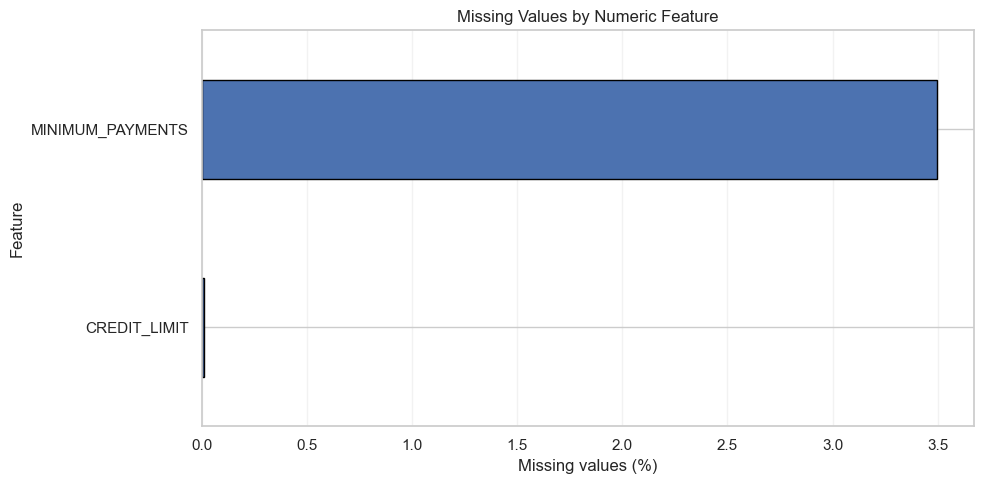


Missing values and infinite values are separate data-quality issues. Neither is automatically imputed in this step.

-------------------------------------------------------------------------------------
2.2B | FINANCIAL AMOUNT DISTRIBUTIONS
-------------------------------------------------------------------------------------


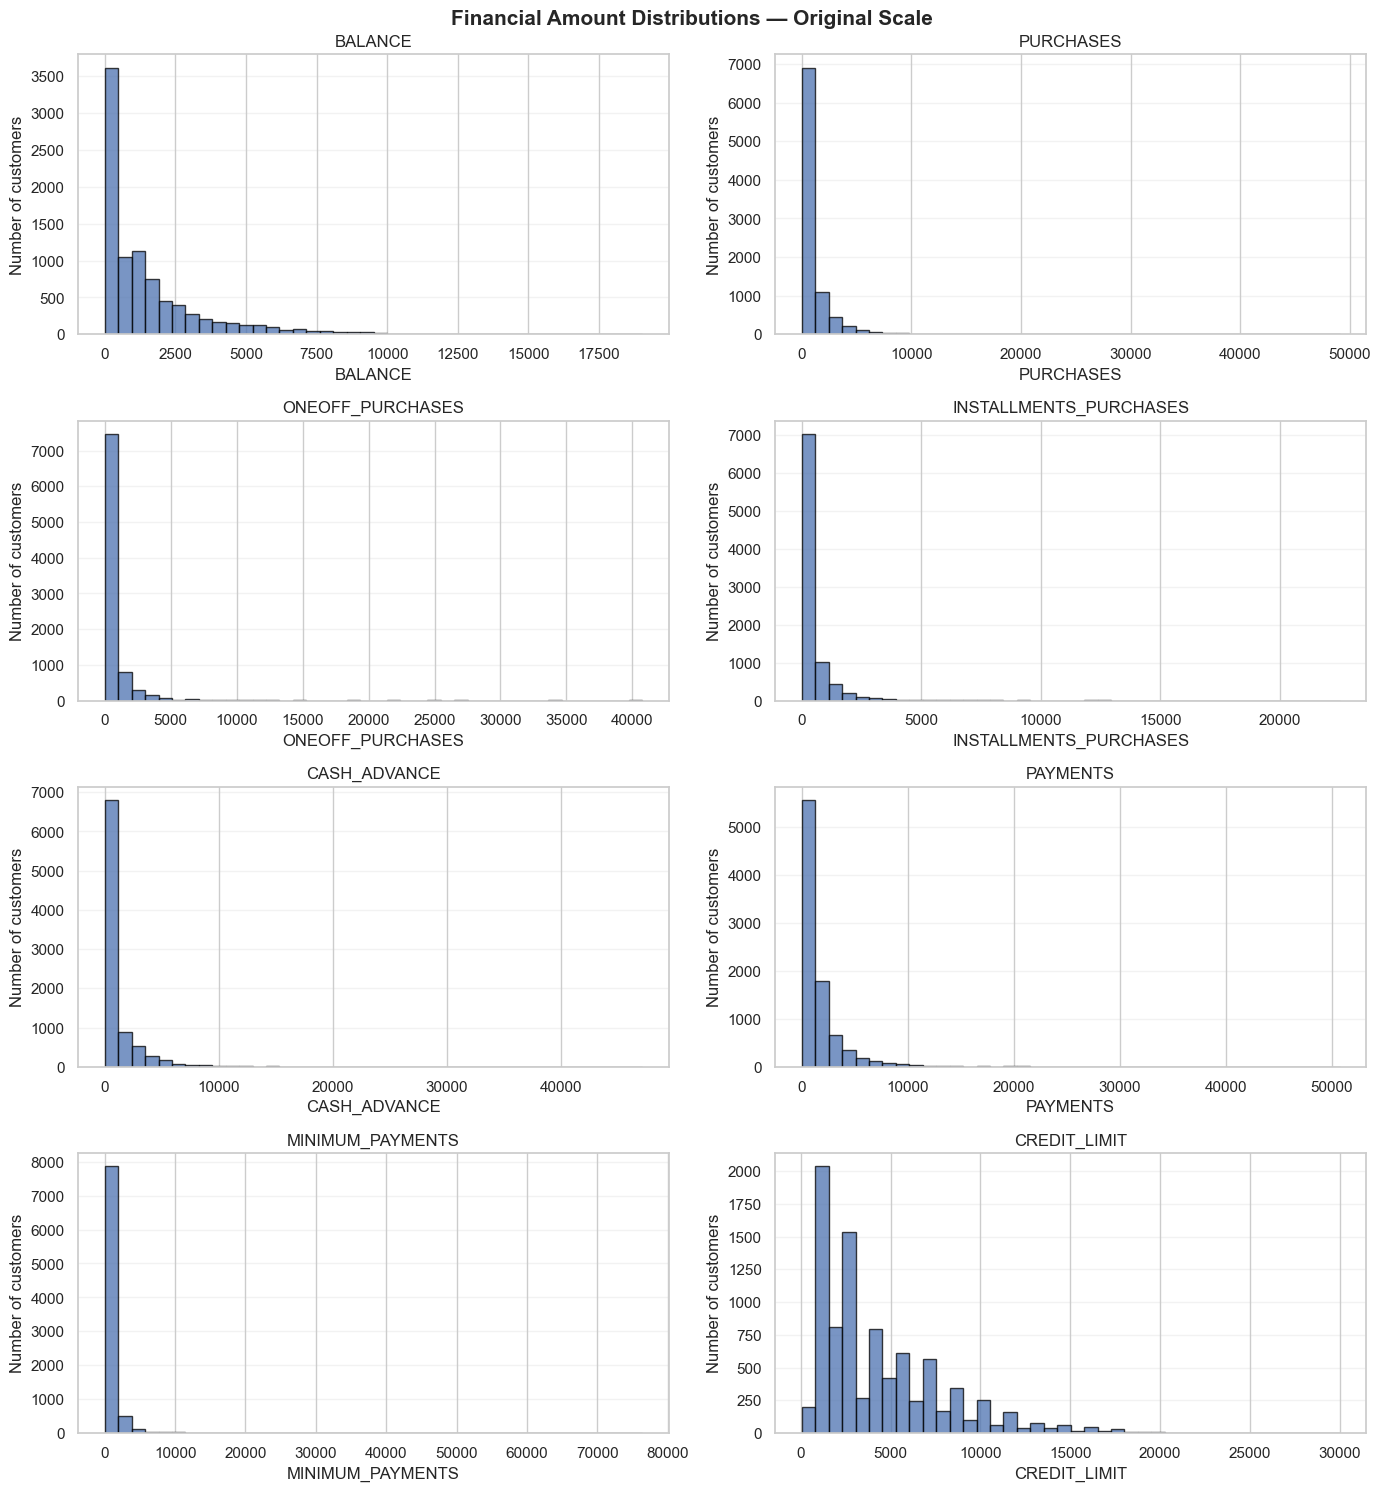


-------------------------------------------------------------------------------------
2.2C | SKEWNESS INVESTIGATION USING LOG1P
-------------------------------------------------------------------------------------
These are exploratory visualisations of log(1 + value). They do not replace the original feature values.


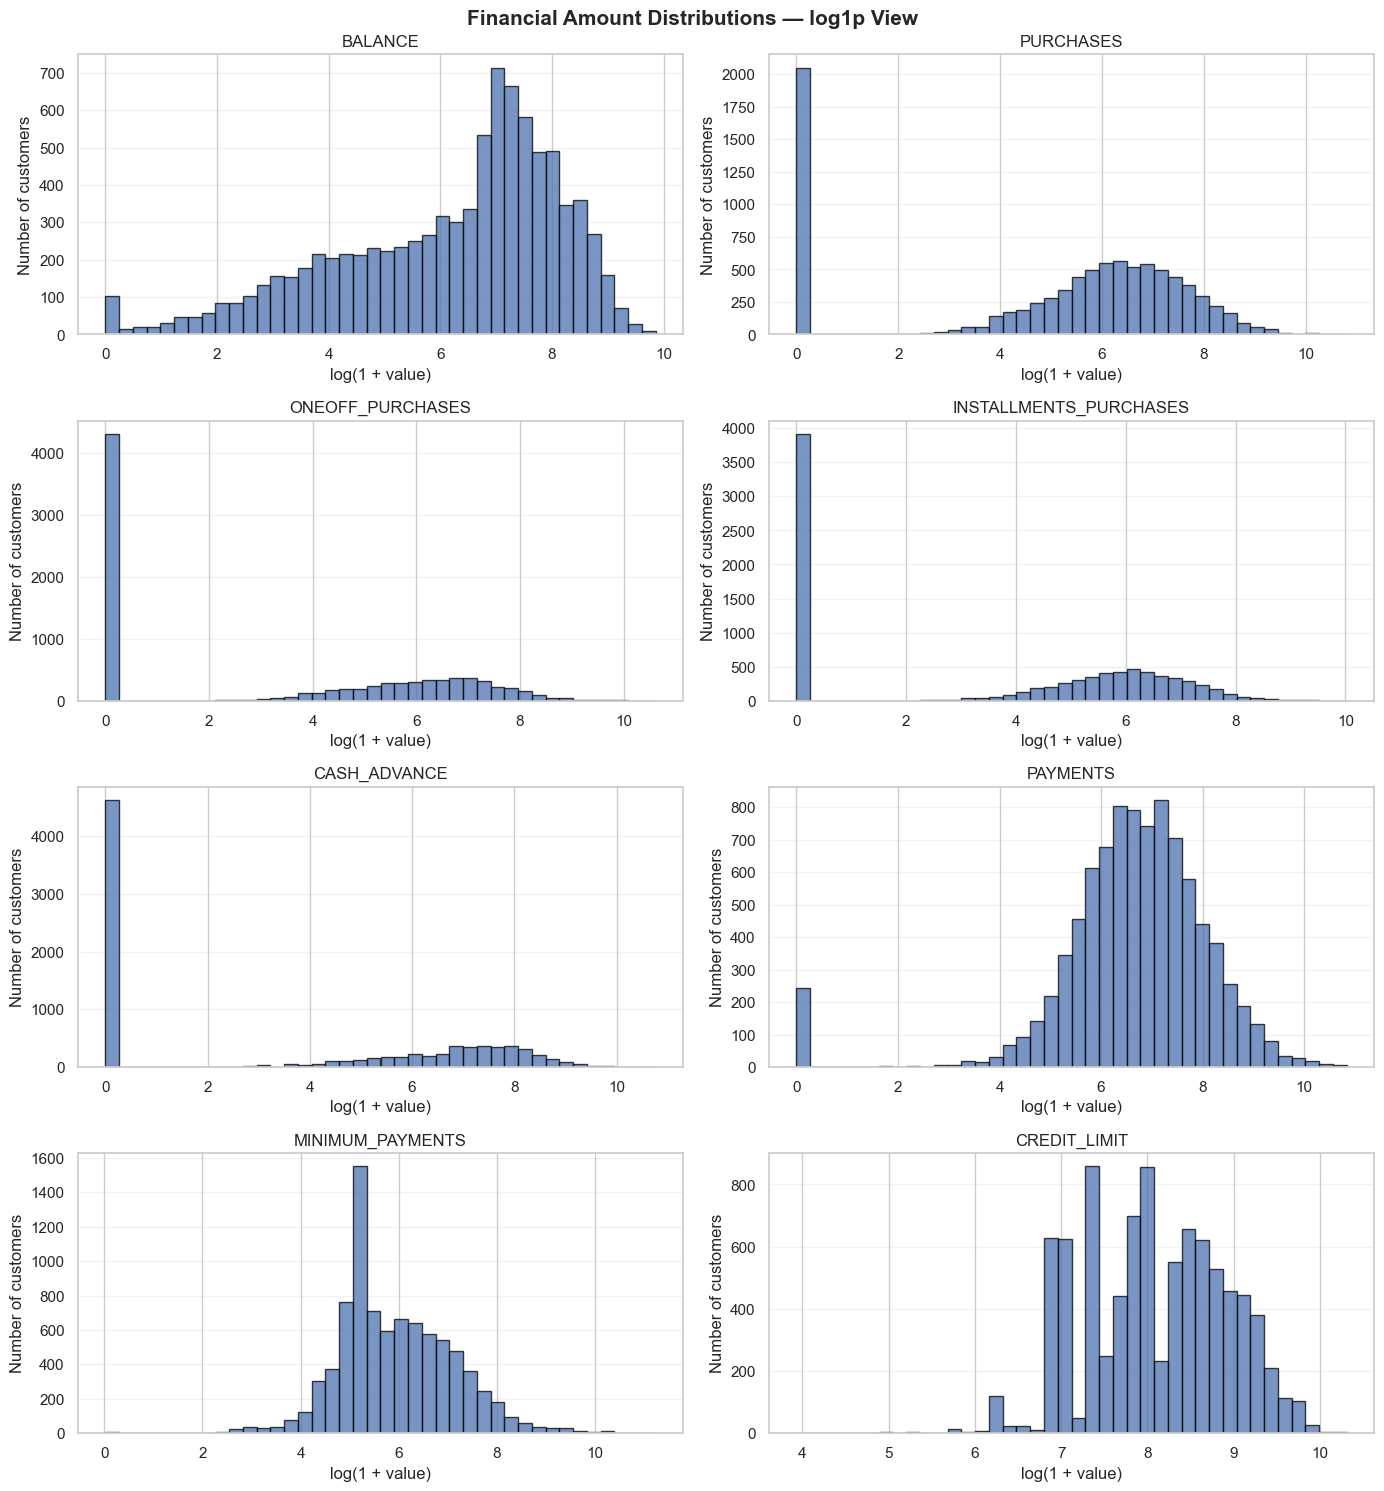


-------------------------------------------------------------------------------------
2.2D | BOXPLOT INVESTIGATION
-------------------------------------------------------------------------------------
Boxplots highlight values outside the usual distribution spread. Such values may be valid customer behaviours.


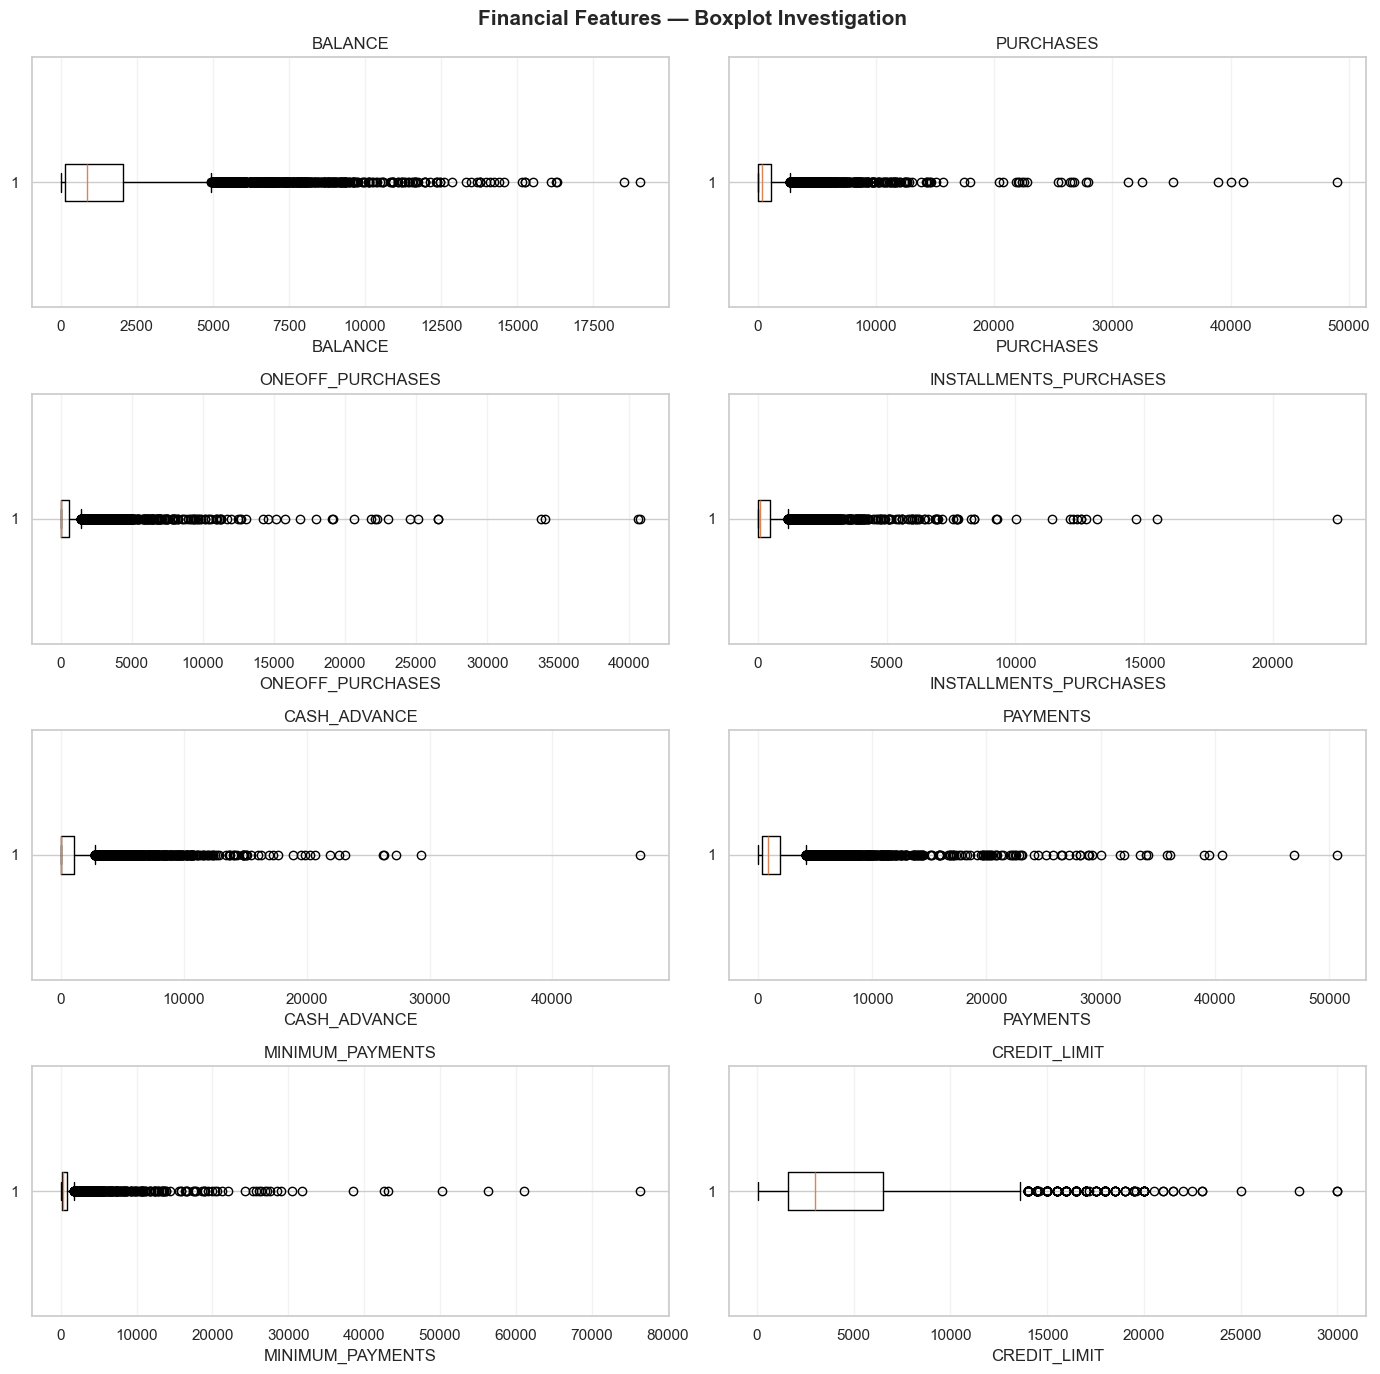


-------------------------------------------------------------------------------------
2.2E | IQR EXTREME-VALUE SCREENING
-------------------------------------------------------------------------------------

IQR Screening Results


,Q1,Q3,IQR,lower_bound,upper_bound,flagged_count,flagged_percent
feature,,,,,,,
BALANCE,128.282,"2,054.140","1,925.858","-2,760.505","4,942.927",695,7.765
PURCHASES,39.635,"1,110.130","1,070.495","-1,566.108","2,715.873",808,9.028
ONEOFF_PURCHASES,0.000,577.405,577.405,-866.108,"1,443.512",1013,11.318
INSTALLMENTS_PURCHASES,0.000,468.638,468.638,-702.956,"1,171.594",867,9.687
CASH_ADVANCE,0.000,"1,113.821","1,113.821","-1,670.732","2,784.553",1030,11.508
PAYMENTS,383.276,"1,901.134","1,517.858","-1,893.511","4,177.922",808,9.028
MINIMUM_PAYMENTS,169.124,825.485,656.362,-815.419,"1,810.028",841,9.737
CREDIT_LIMIT,"1,600.000","6,500.000","4,900.000","-5,750.000","13,850.000",248,2.771



The 1.5 × IQR rule is a screening convention, not proof of a data error. Flagged observations are retained for further investigation.

-------------------------------------------------------------------------------------
2.2F | NEGATIVE FINANCIAL AMOUNT CHECK
-------------------------------------------------------------------------------------

Negative Values in Candidate Amount Features


,negative_count,negative_percent
feature,,
BALANCE,0,0.000
PURCHASES,0,0.000
ONEOFF_PURCHASES,0,0.000
INSTALLMENTS_PURCHASES,0,0.000
CASH_ADVANCE,0,0.000
PAYMENTS,0,0.000
MINIMUM_PAYMENTS,0,0.000
CREDIT_LIMIT,0,0.000



No negative values were detected in the available amount features.

-------------------------------------------------------------------------------------
2.3 | ZERO-VALUE AND LOW-ACTIVITY ANALYSIS
-------------------------------------------------------------------------------------

Zero-Value Summary by Feature


,valid_count,zero_count,zero_percent,nonzero_count
PRC_FULL_PAYMENT,8950,5903,65.955,3047
CASH_ADVANCE_FREQUENCY,8950,4628,51.709,4322
CASH_ADVANCE,8950,4628,51.709,4322
CASH_ADVANCE_TRX,8950,4628,51.709,4322
ONEOFF_PURCHASES_FREQUENCY,8950,4302,48.067,4648
ONEOFF_PURCHASES,8950,4302,48.067,4648
INSTALLMENTS_PURCHASES,8950,3916,43.754,5034
PURCHASES_INSTALLMENTS_FREQUENCY,8950,3915,43.743,5035
PURCHASES,8950,2044,22.838,6906
PURCHASES_TRX,8950,2044,22.838,6906



A zero may represent no activity for the observation period. Its meaning depends on the feature definition; zero is not automatically equivalent to missing data.


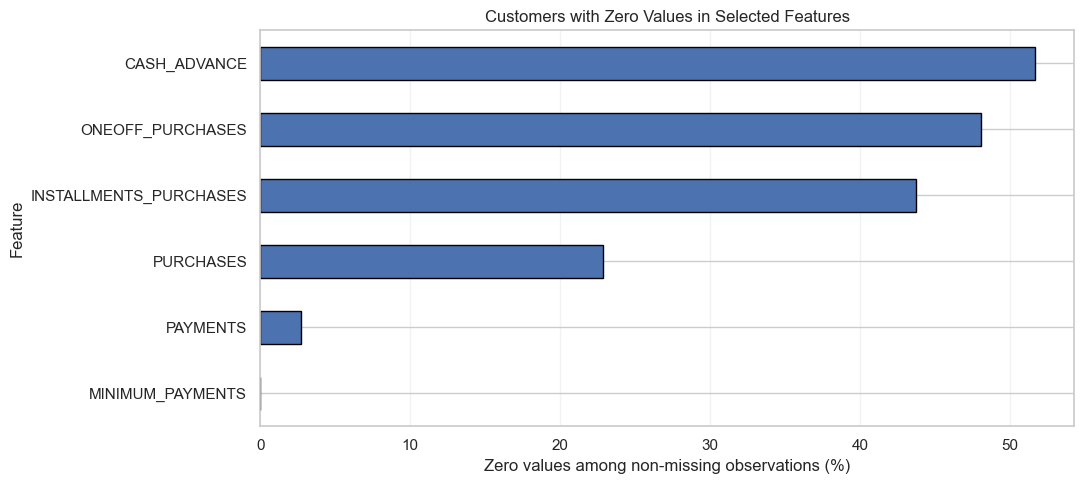


-------------------------------------------------------------------------------------
2.3A | FREQUENCY AND TENURE DISTRIBUTIONS
-------------------------------------------------------------------------------------


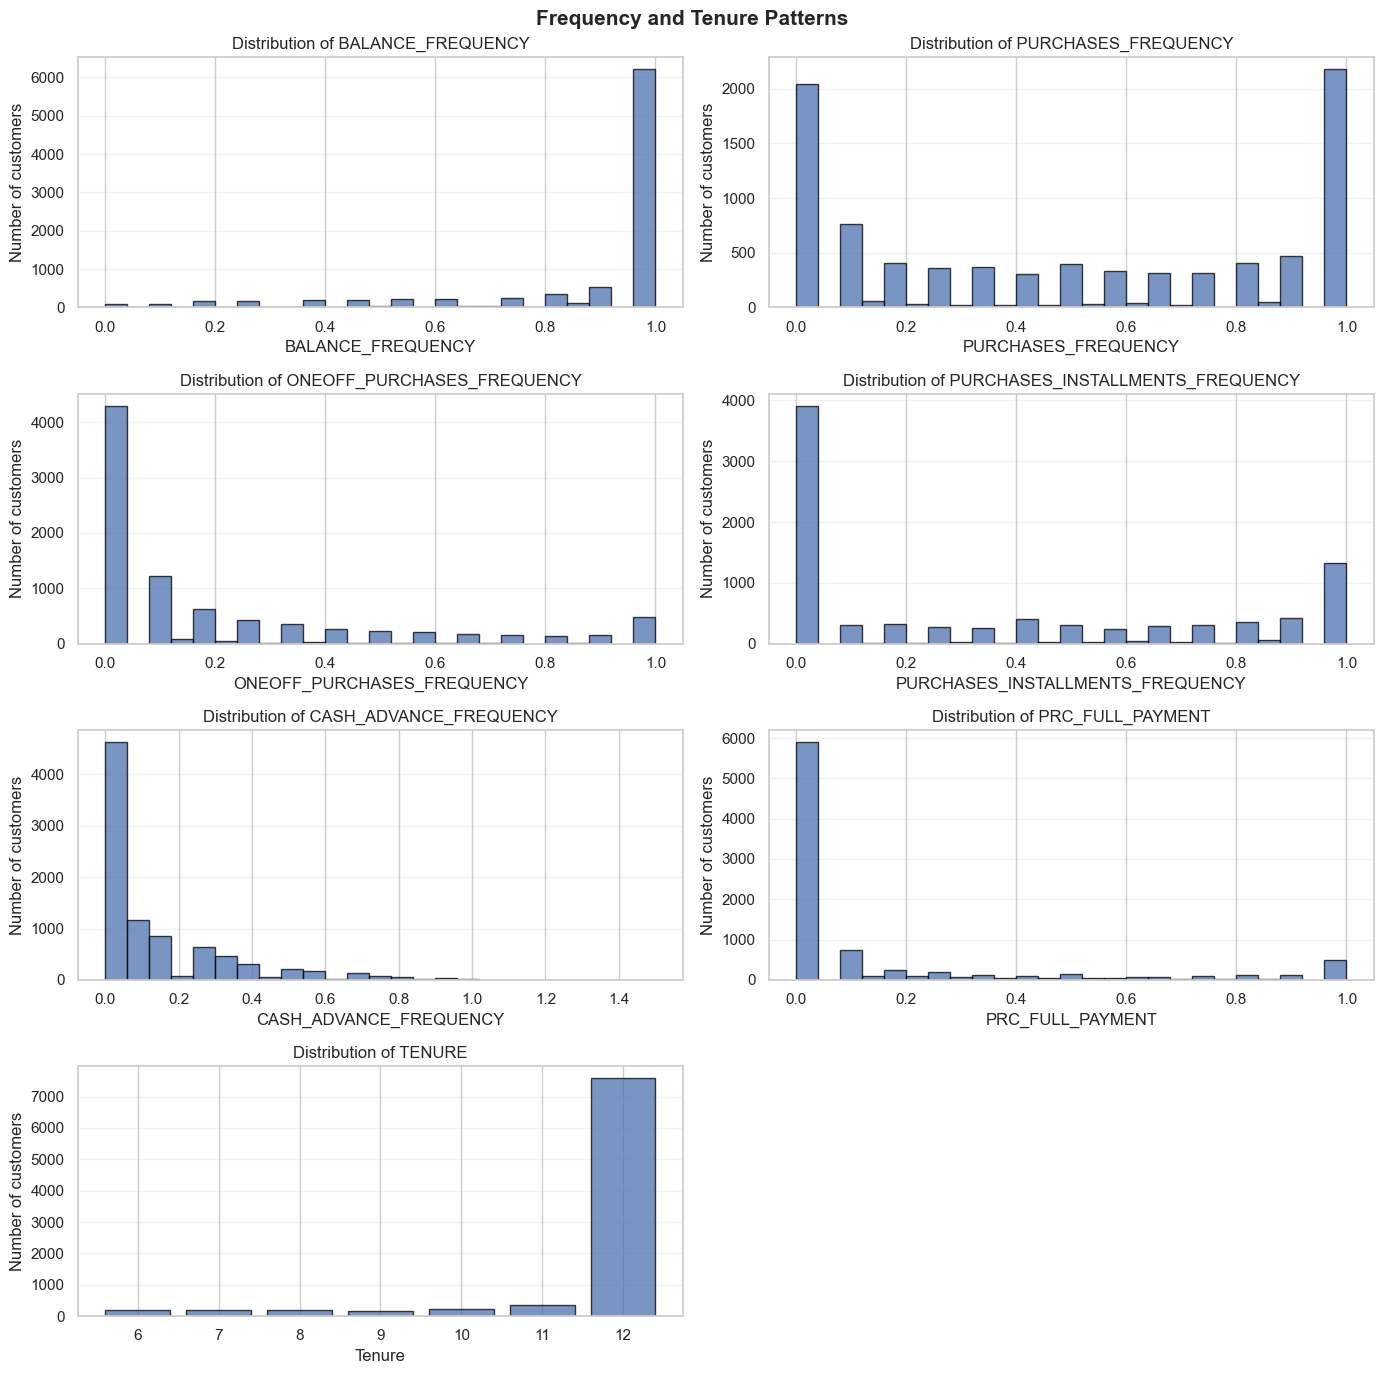


TENURE Distribution


,customer_count,percentage
TENURE,,
6,204,2.279
7,190,2.123
8,196,2.190
9,175,1.955
10,236,2.637
11,365,4.078
12,7584,84.737



-------------------------------------------------------------------------------------
2.3B | FREQUENCY RANGE VALIDATION
-------------------------------------------------------------------------------------

Frequency/Proportion Range Check


,minimum,maximum,below_zero_count,above_one_count,outside_0_1_count
feature,,,,,
BALANCE_FREQUENCY,0.000,1.000,0,0,0
PURCHASES_FREQUENCY,0.000,1.000,0,0,0
ONEOFF_PURCHASES_FREQUENCY,0.000,1.000,0,0,0
PURCHASES_INSTALLMENTS_FREQUENCY,0.000,1.000,0,0,0
CASH_ADVANCE_FREQUENCY,0.000,1.500,0,8,8
PRC_FULL_PAYMENT,0.000,1.000,0,0,0



Unusual values for CASH_ADVANCE_FREQUENCY:


...

,CASH_ADVANCE,PURCHASES,CREDIT_LIMIT,BALANCE,CASH_ADVANCE_TRX,PURCHASES_TRX
2159,"47,137.212",431.930,"19,600.000","10,905.054",123,21
1059,"29,282.109","3,719.000","15,500.000","8,823.284",26,61
71,"27,296.486","4,523.270","7,000.000","2,990.422",27,33
7254,"26,268.700","1,750.660","8,500.000","4,530.205",10,36
7645,"26,194.050",0.000,"9,000.000","7,081.171",69,0
2454,"23,130.821",0.000,"15,000.000","10,915.551",23,0
883,"22,665.778",0.000,"18,500.000","14,581.459",30,0
6371,"21,943.849",0.000,"13,000.000","4,529.896",12,0
3806,"20,712.670","4,995.800","16,500.000","14,100.251",36,34
6455,"20,277.331","1,490.750","11,000.000","9,110.969",22,5



Median PURCHASES across customers: 361.28
Top CASH_ADVANCE customers who are also at/above median PURCHASES: 6 / 10

For this descriptive check, “high PURCHASES” means PURCHASES at or above the overall customer median.

-------------------------------------------------------------------------------------
2.3E | CUSTOMERS WITH ZERO PURCHASES
-------------------------------------------------------------------------------------
Customers with PURCHASES = 0 : 2,044
Customers with valid PURCHASES : 8,950
Percentage with PURCHASES = 0 : 22.84%

-------------------------------------------------------------------------------------
2.4 | PURCHASE-COMPONENT CONSISTENCY CHECK
-------------------------------------------------------------------------------------
Rows with all three values: 8,950
Tolerance: 0.01
Rows exceeding tolerance: 19
Mismatch percentage among complete rows: 0.212%

Largest Purchase-Component Differences


,source_row_index,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,component_sum,signed_difference,absolute_difference
6857,6857,"5,629.410",0.000,"6,229.410","6,229.410",-600.000,600.000
5231,5231,205.060,0.000,607.760,607.760,-402.700,402.700
5967,5967,279.760,0.000,578.550,578.550,-298.790,298.790
6803,6803,339.110,611.650,12.410,624.060,-284.950,284.950
8834,8834,510.000,0.000,780.000,780.000,-270.000,270.000
6790,6790,426.250,0.000,653.550,653.550,-227.300,227.300
5846,5846,486.270,580.200,0.000,580.200,-93.930,93.930
510,510,400.410,0.000,489.390,489.390,-88.980,88.980
5737,5737,0.000,0.000,66.950,66.950,-66.950,66.950
908,908,"3,393.250","3,364.590",77.660,"3,442.250",-49.000,49.000



Check the dataset documentation and inspect the flagged rows before changing any values.
The components may not necessarily sum exactly under every data definition.

-------------------------------------------------------------------------------------
2.5 | PEARSON FEATURE CORRELATION
-------------------------------------------------------------------------------------

Pearson Correlation Matrix


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000,0.320,0.180,0.160,0.130,0.500,-0.080,0.070,-0.060,0.450,0.390,0.150,0.530,0.320,0.400,-0.320,0.070
BALANCE_FREQUENCY,0.320,1.000,0.130,0.100,0.120,0.100,0.230,0.200,0.180,0.190,0.140,0.190,0.100,0.070,0.130,-0.100,0.120
PURCHASES,0.180,0.130,1.000,0.920,0.680,-0.050,0.390,0.500,0.320,-0.120,-0.070,0.690,0.360,0.600,0.090,0.180,0.090
ONEOFF_PURCHASES,0.160,0.100,0.920,1.000,0.330,-0.030,0.260,0.520,0.130,-0.080,-0.050,0.550,0.320,0.570,0.050,0.130,0.060
INSTALLMENTS_PURCHASES,0.130,0.120,0.680,0.330,1.000,-0.060,0.440,0.210,0.510,-0.130,-0.070,0.630,0.260,0.380,0.130,0.180,0.090
CASH_ADVANCE,0.500,0.100,-0.050,-0.030,-0.060,1.000,-0.220,-0.090,-0.180,0.630,0.660,-0.080,0.300,0.450,0.140,-0.150,-0.070
PURCHASES_FREQUENCY,-0.080,0.230,0.390,0.260,0.440,-0.220,1.000,0.500,0.860,-0.310,-0.200,0.570,0.120,0.100,0.000,0.310,0.060
ONEOFF_PURCHASES_FREQUENCY,0.070,0.200,0.500,0.520,0.210,-0.090,0.500,1.000,0.140,-0.110,-0.070,0.540,0.300,0.240,-0.030,0.160,0.080
PURCHASES_INSTALLMENTS_FREQUENCY,-0.060,0.180,0.320,0.130,0.510,-0.180,0.860,0.140,1.000,-0.260,-0.170,0.530,0.060,0.090,0.030,0.250,0.070
CASH_ADVANCE_FREQUENCY,0.450,0.190,-0.120,-0.080,-0.130,0.630,-0.310,-0.110,-0.260,1.000,0.800,-0.130,0.130,0.180,0.100,-0.250,-0.130


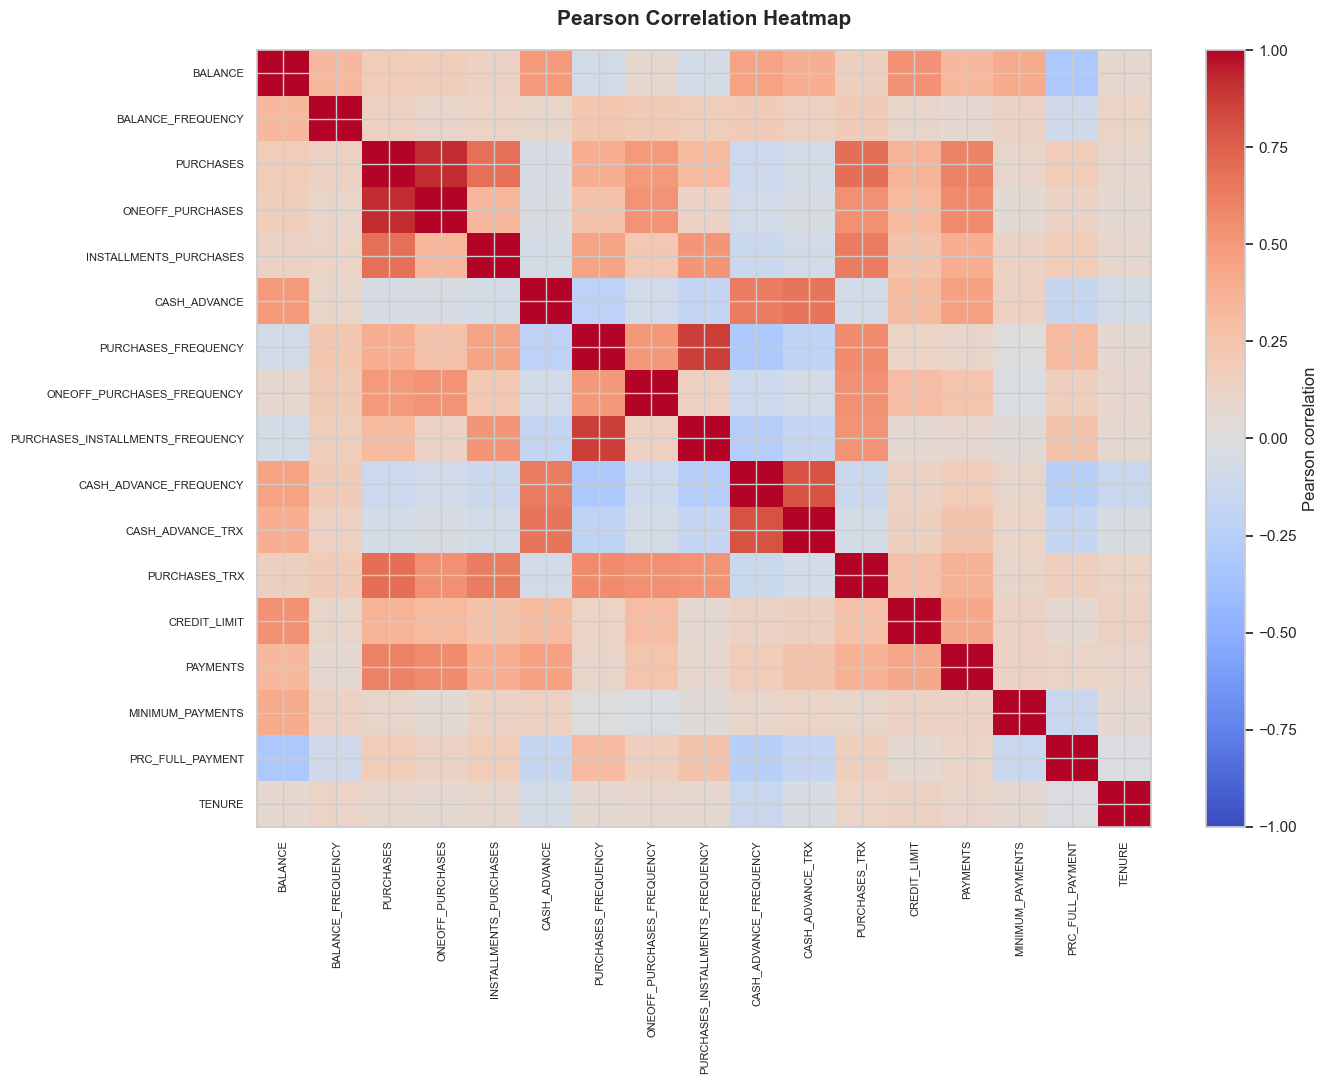


-------------------------------------------------------------------------------------
2.5A | STRONG PEARSON CORRELATION PAIRS
-------------------------------------------------------------------------------------

Pearson Pairs with |r| >= 0.80


,feature_1,feature_2,correlation,absolute_correlation
0,PURCHASES,ONEOFF_PURCHASES,0.917,0.917
1,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.863,0.863



High correlation may indicate overlapping information. It does not by itself prove that a feature should be removed.

-------------------------------------------------------------------------------------
2.5B | SPEARMAN CORRELATION CHECK
-------------------------------------------------------------------------------------

Spearman Pairs with |rho| >= 0.80


,feature_1,feature_2,correlation,absolute_correlation
0,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.983,0.983
1,ONEOFF_PURCHASES,ONEOFF_PURCHASES_FREQUENCY,0.952,0.952
2,CASH_ADVANCE,CASH_ADVANCE_TRX,0.952,0.952
3,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.941,0.941
4,PURCHASES_FREQUENCY,PURCHASES_TRX,0.924,0.924
5,INSTALLMENTS_PURCHASES,PURCHASES_INSTALLMENTS_FREQUENCY,0.923,0.923
6,BALANCE,MINIMUM_PAYMENTS,0.900,0.900
7,PURCHASES,PURCHASES_TRX,0.885,0.885
8,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.852,0.852



Pearson measures linear association; Spearman measures rank-based monotonic association. Neither establishes causation.

-------------------------------------------------------------------------------------
2.5C | PEARSON VS SPEARMAN COMPARISON
-------------------------------------------------------------------------------------
Pairs above the threshold in Pearson but not Spearman:
[('PURCHASES', 'ONEOFF_PURCHASES')]

Pairs above the threshold in Spearman but not Pearson:
[('BALANCE', 'MINIMUM_PAYMENTS'), ('CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY'), ('CASH_ADVANCE', 'CASH_ADVANCE_TRX'), ('CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX'), ('INSTALLMENTS_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY'), ('ONEOFF_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY'), ('PURCHASES', 'PURCHASES_TRX'), ('PURCHASES_FREQUENCY', 'PURCHASES_TRX')]

Differences can arise because Pearson and Spearman capture different types of association. Investigate feature meaning and plots before making feature-selection decis

,finding,evidence,recommended_next_action
0,Missing numeric values,314 missing cells; largest affected feature: M...,Choose a justified missing-value strategy duri...
1,Infinite values,0 infinite numeric cells,Investigate the source of any infinities befor...
2,Skewed features,11 features meet the skewness threshold,Review distributions and consider transformati...
3,Negative financial amounts,0 negative amount cells across listed features,Check feature definitions and data validity; d...
4,Potential extreme values,6310 feature-level flags (the same customer ma...,Review the distributions and retain valid cust...
5,Features with many zeros,4 features have at least 50% zeros among non-m...,Determine whether zeros indicate meaningful in...
6,Frequency/proportion range,8 values outside 0–1 in checked columns,Verify variable definitions and investigate un...
7,Purchase-component consistency,19 of 8950 complete rows exceed tolerance,Verify definitions and flagged records before ...
8,Pearson correlation,2 pairs meet the absolute threshold,Review overlapping features in light of the cl...
9,Spearman correlation,9 pairs meet the absolute threshold,Compare rank-based relationships with Pearson ...



                             STEP 2: FINAL QUALITY CHECKS                            
Original dataframe rows : 8,950
Numeric analysis rows   : 8,950
Numeric feature count   : 17
Analysis row-count check: PASSED
Original dataframe unchanged: PASSED

Questions to address in preprocessing:
1. Which missing-value strategy is justified by each feature?
2. Do any infinite or unusual values need correction?
3. Should skewed features be transformed, and why?
4. Are IQR-flagged observations valid customer behaviours?
5. Do correlated features create unintended weighting?
6. Which features need scaling for the chosen clustering method?
7. Should any feature be excluded based on its meaning or quality?
8. Should the rough PURCHASES/CREDIT_LIMIT ratio be used as an additional behavioural feature?
9. How should zero-purchase customers be represented during segmentation?
10. Should highly cash-advance-oriented customers be interpreted as a distinct behavioural pattern?

STEP 2 COMPLETE

EDA is com

In [19]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# Project: Credit Card Customer Segmentation
# Purpose: Understand customer behaviour before preprocessing
# ============================================================
#
#
# ------------------------------------------------------------
# 2.0 | CONFIGURATION AND HELPER FUNCTIONS
# ------------------------------------------------------------

CORRELATION_THRESHOLD = 0.80
SKEWNESS_THRESHOLD = 2.00
HIGH_ZERO_THRESHOLD = 50.00
IQR_MULTIPLIER = 1.50
PURCHASE_TOLERANCE = 0.01


def eda_header(title):
    print("\n" + "=" * 85)
    print(title.center(85))
    print("=" * 85)


def eda_section(title):
    print("\n" + "-" * 85)
    print(title)
    print("-" * 85)


def display_table(table, title=None, decimals=3):

    if title:
        print(f"\n{title}")

    if isinstance(table, pd.Series):
        table = table.to_frame()

    display(table.round(decimals))


def extract_correlation_pairs(corr_matrix, threshold=0.80):
    """Extract unique correlation pairs meeting an absolute threshold."""

    upper = corr_matrix.where(
        np.triu(
            np.ones(corr_matrix.shape, dtype=bool),
            k=1
        )
    )

    pairs = (
        upper.stack()
        .rename("correlation")
        .reset_index()
    )

    pairs.columns = [
        "feature_1",
        "feature_2",
        "correlation"
    ]

    pairs["absolute_correlation"] = (
        pairs["correlation"].abs()
    )

    pairs = pairs[
        pairs["absolute_correlation"] >= threshold
    ].copy()

    return pairs.sort_values(
        "absolute_correlation",
        ascending=False
    ).reset_index(drop=True)


def plot_histograms(data, columns, title, log1p=False):
    """Plot numeric feature distributions without changing source data."""

    if not columns:
        print("No eligible columns are available for this plot.")
        return

    ncols = 2
    nrows = int(np.ceil(len(columns) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(14, 3.8 * nrows),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, col in zip(axes, columns):

        values = data[col].dropna()

        if values.empty:
            ax.set_visible(False)
            continue

        if log1p:

            if (values < 0).any():

                ax.text(
                    0.5,
                    0.5,
                    "Negative values found\nlog1p view skipped",
                    ha="center",
                    va="center",
                    transform=ax.transAxes
                )

                ax.set_title(
                    f"{col} — log1p skipped"
                )

                continue

            values = np.log1p(values)
            xlabel = "log(1 + value)"

        else:
            xlabel = col

        ax.hist(
            values,
            bins=40,
            edgecolor="black",
            alpha=0.75
        )

        ax.set_title(col)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Number of customers")
        ax.grid(
            axis="y",
            alpha=0.25
        )

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(
        title,
        fontsize=15,
        fontweight="bold"
    )

    fig.tight_layout()
    plt.show()


def plot_horizontal_boxplots(data, columns, title):
    """Plot horizontal boxplots for numeric features."""

    if not columns:
        print("No eligible columns are available for boxplots.")
        return

    ncols = 2
    nrows = int(np.ceil(len(columns) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(14, 3.5 * nrows),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, col in zip(axes, columns):

        values = data[col].dropna()

        if values.empty:
            ax.set_visible(False)
            continue

        try:
            ax.boxplot(
                values,
                orientation="horizontal"
            )

        except TypeError:

            # Compatibility with older Matplotlib versions.
            ax.boxplot(
                values,
                vert=False
            )

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.grid(
            axis="x",
            alpha=0.25
        )

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(
        title,
        fontsize=15,
        fontweight="bold"
    )

    fig.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 2.0A | INPUT VALIDATION AND DATA INTEGRITY
# ------------------------------------------------------------

if "df" not in globals():

    raise NameError(
        "Run Step 1 first. The dataframe 'df' was not found."
    )


if not isinstance(df, pd.DataFrame):

    raise TypeError(
        "'df' must be a pandas DataFrame."
    )


if df.empty:

    raise ValueError(
        "'df' is empty. Check the data-loading step."
    )


if df.columns.duplicated().any():

    duplicated_names = df.columns[
        df.columns.duplicated(keep=False)
    ].tolist()

    raise ValueError(
        f"Duplicate column names found: {duplicated_names}. "
        "Resolve these before continuing."
    )


# Keep a deep snapshot to verify that EDA does not modify df.
df_snapshot = df.copy(deep=True)


# Numeric analysis copy.
# The original dataframe remains untouched.
numeric_df = df.select_dtypes(
    include="number"
).copy()


if numeric_df.empty:

    raise ValueError(
        "No numeric features were found in df."
    )


# Count infinite values before replacing them
# in the analysis copy.
infinite_counts = pd.Series(
    np.isinf(
        numeric_df.to_numpy()
    ).sum(axis=0),
    index=numeric_df.columns,
    name="infinite_count"
)


# Replace infinities only inside numeric_df.
# Original df remains unchanged.
numeric_df = numeric_df.replace(
    [np.inf, -np.inf],
    np.nan
)


eda_header(
    "STEP 2: EXPLORATORY DATA ANALYSIS"
)


print(
    "Objective : Understand distributions, data quality and relationships."
)

print(
    "Approach  : Statistics, visualisations, integrity checks and correlations."
)

print(
    "Data rule : No customer rows or features are automatically removed."
)


print(
    f"\nCustomer records          : {len(df):,}"
)

print(
    f"All dataframe columns     : {df.shape[1]:,}"
)

print(
    f"Numeric features          : {numeric_df.shape[1]:,}"
)

print(
    f"Original missing cells    : "
    f"{int(df.isna().sum().sum()):,}"
)

print(
    f"Missing numeric cells     : "
    f"{int(df.select_dtypes(include='number').isna().sum().sum()):,}"
)

print(
    f"Infinite numeric cells    : "
    f"{int(infinite_counts.sum()):,}"
)


if infinite_counts.sum() > 0:

    display_table(
        infinite_counts[
            infinite_counts > 0
        ],
        "Features Containing Infinite Values"
    )

else:

    print(
        "\nNo positive or negative infinite values were detected."
    )


print(
    "\nNote: Infinite values are represented as missing in "
    "numeric_df for analysis. They are not replaced in the "
    "original df."
)


# ------------------------------------------------------------
# 2.1 | FEATURE GROUPS
# ------------------------------------------------------------

eda_section(
    "2.1 | FEATURE GROUPS"
)


feature_groups = {

    "BALANCE": [
        "BALANCE",
        "BALANCE_FREQUENCY"
    ],

    "PURCHASE BEHAVIOUR": [
        "PURCHASES",
        "ONEOFF_PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "PURCHASES_FREQUENCY",
        "ONEOFF_PURCHASES_FREQUENCY",
        "PURCHASES_INSTALLMENTS_FREQUENCY",
        "PURCHASES_TRX"
    ],

    "CASH ADVANCE": [
        "CASH_ADVANCE",
        "CASH_ADVANCE_FREQUENCY",
        "CASH_ADVANCE_TRX"
    ],

    "CREDIT AND PAYMENTS": [
        "CREDIT_LIMIT",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "PRC_FULL_PAYMENT"
    ],

    "ACTIVITY AND TENURE": [
        "BALANCE_FREQUENCY",
        "PURCHASES_FREQUENCY",
        "CASH_ADVANCE_FREQUENCY",
        "PRC_FULL_PAYMENT",
        "TENURE"
    ],

    "TRANSACTION COUNTS": [
        "PURCHASES_TRX",
        "CASH_ADVANCE_TRX"
    ]
}


for group_name, columns in feature_groups.items():

    available = [
        col
        for col in columns
        if col in numeric_df.columns
    ]

    print(f"\n{group_name}")

    print(
        "Features:",
        ", ".join(available)
        if available
        else "None available"
    )


print(
    "\nSome features appear in multiple groups because they "
    "describe different aspects of related customer behaviours."
)


# ------------------------------------------------------------
# 2.2 | DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

eda_section(
    "2.2 | DESCRIPTIVE STATISTICS"
)


descriptive_stats = numeric_df.describe().T


descriptive_stats["median"] = (
    numeric_df.median()
)

descriptive_stats["missing_count"] = (
    numeric_df.isna().sum()
)

descriptive_stats["missing_percent"] = (
    numeric_df.isna().mean() * 100
)

descriptive_stats["skewness"] = (
    numeric_df.skew()
)


stats_columns = [
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
    "missing_count",
    "missing_percent",
    "skewness"
]


display_table(
    descriptive_stats[stats_columns],
    "Numerical Feature Summary"
)


print(
    "\nSkewness interpretation:"
)

print(
    "  Near 0        : approximately symmetric"
)

print(
    "  Positive      : right-skewed"
)

print(
    "  Negative      : left-skewed"
)

print(
    "  Large absolute values: investigate with plots "
    "and feature definitions"
)


# Identify high-skew features for investigation.
# No automatic transformation is performed here.

skewness = (
    numeric_df.skew()
    .dropna()
)


high_skew = skewness[
    skewness.abs() >= SKEWNESS_THRESHOLD
].sort_values(
    key=lambda x: x.abs(),
    ascending=False
)


if high_skew.empty:

    print(
        "\nNo features met the selected absolute "
        "skewness threshold."
    )

else:

    display_table(
        high_skew.rename("skewness"),
        f"Features with |skewness| >= "
        f"{SKEWNESS_THRESHOLD:.1f}"
    )


# ------------------------------------------------------------
# 2.2A | MISSING-VALUE ANALYSIS
# ------------------------------------------------------------

eda_section(
    "2.2A | MISSING-VALUE ANALYSIS"
)


# Report actual nulls separately from infinities.
original_numeric = df.select_dtypes(
    include="number"
)


missing_summary = pd.DataFrame({

    "feature": original_numeric.columns,

    "missing_count": (
        original_numeric.isna().sum().values
    ),

    "missing_percent": (
        original_numeric.isna().mean().values * 100
    )
})


missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_count",
    ascending=False
).reset_index(
    drop=True
)


if missing_summary.empty:

    print(
        "No original missing values were found "
        "in numeric features."
    )

else:

    display_table(
        missing_summary.set_index("feature"),
        "Original Missing Values by Numeric Feature"
    )

    plt.figure(
        figsize=(10, 5)
    )

    missing_summary.sort_values(
        "missing_percent"
    ).set_index(
        "feature"
    )["missing_percent"].plot(
        kind="barh",
        edgecolor="black"
    )

    plt.title(
        "Missing Values by Numeric Feature"
    )

    plt.xlabel(
        "Missing values (%)"
    )

    plt.ylabel(
        "Feature"
    )

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


print(
    "\nMissing values and infinite values are separate "
    "data-quality issues. Neither is automatically "
    "imputed in this step."
)


# ------------------------------------------------------------
# 2.2B | FINANCIAL AMOUNT DISTRIBUTIONS
# ------------------------------------------------------------

eda_section(
    "2.2B | FINANCIAL AMOUNT DISTRIBUTIONS"
)


amount_candidates = [

    "BALANCE",

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES",

    "CASH_ADVANCE",

    "PAYMENTS",

    "MINIMUM_PAYMENTS",

    "CREDIT_LIMIT"

]


amount_columns = [

    col
    for col in amount_candidates
    if col in numeric_df.columns

]


plot_histograms(

    numeric_df,

    amount_columns,

    "Financial Amount Distributions — Original Scale"

)


# ------------------------------------------------------------
# 2.2C | LOG1P DISTRIBUTIONS
# ------------------------------------------------------------

eda_section(
    "2.2C | SKEWNESS INVESTIGATION USING LOG1P"
)


print(
    "These are exploratory visualisations of "
    "log(1 + value). They do not replace the "
    "original feature values."
)


plot_histograms(

    numeric_df,

    amount_columns,

    "Financial Amount Distributions — log1p View",

    log1p=True

)


# ------------------------------------------------------------
# 2.2D | BOXPLOTS
# ------------------------------------------------------------

eda_section(
    "2.2D | BOXPLOT INVESTIGATION"
)


print(
    "Boxplots highlight values outside the usual "
    "distribution spread. Such values may be valid "
    "customer behaviours."
)


plot_horizontal_boxplots(

    numeric_df,

    amount_columns,

    "Financial Features — Boxplot Investigation"

)


# ------------------------------------------------------------
# 2.2E | IQR EXTREME-VALUE SCREENING
# ------------------------------------------------------------

eda_section(
    "2.2E | IQR EXTREME-VALUE SCREENING"
)


iqr_rows = []


for col in amount_columns:

    values = numeric_df[col].dropna()


    if values.empty:
        continue


    q1 = values.quantile(0.25)

    q3 = values.quantile(0.75)

    iqr = q3 - q1


    lower_bound = (
        q1 - IQR_MULTIPLIER * iqr
    )

    upper_bound = (
        q3 + IQR_MULTIPLIER * iqr
    )


    flagged = (
        (values < lower_bound)
        |
        (values > upper_bound)
    )


    iqr_rows.append({

        "feature": col,

        "Q1": q1,

        "Q3": q3,

        "IQR": iqr,

        "lower_bound": lower_bound,

        "upper_bound": upper_bound,

        "flagged_count": int(
            flagged.sum()
        ),

        "flagged_percent": float(
            flagged.mean() * 100
        )

    })


iqr_summary = pd.DataFrame(
    iqr_rows
)


if iqr_summary.empty:

    print(
        "IQR screening could not be performed."
    )

else:

    display_table(

        iqr_summary.set_index("feature"),

        "IQR Screening Results",

        decimals=3

    )


print(
    "\nThe 1.5 × IQR rule is a screening convention, "
    "not proof of a data error. Flagged observations "
    "are retained for further investigation."
)


# ------------------------------------------------------------
# 2.2F | NEGATIVE AMOUNT CHECK
# ------------------------------------------------------------

eda_section(
    "2.2F | NEGATIVE FINANCIAL AMOUNT CHECK"
)


negative_rows = []


for col in amount_columns:

    values = numeric_df[col].dropna()

    negative_count = int(
        (values < 0).sum()
    )


    negative_rows.append({

        "feature": col,

        "negative_count": negative_count,

        "negative_percent": (

            float(
                (values < 0).mean() * 100
            )

            if len(values)
            else np.nan

        )

    })


negative_summary = pd.DataFrame(
    negative_rows
)


if negative_summary.empty:

    print(
        "No candidate amount columns were available."
    )

else:

    display_table(

        negative_summary.set_index("feature"),

        "Negative Values in Candidate Amount Features"

    )


    if (
        negative_summary["negative_count"] > 0
    ).any():

        print(
            "\nReview negative amounts against the "
            "dataset definitions. Do not automatically "
            "remove them."
        )

        print(
            "Adjustments or refunds may be possible "
            "depending on how the data was collected."
        )

    else:

        print(
            "\nNo negative values were detected "
            "in the available amount features."
        )


# ------------------------------------------------------------
# 2.3 | ZERO-VALUE AND LOW-ACTIVITY ANALYSIS
# ------------------------------------------------------------

eda_section(
    "2.3 | ZERO-VALUE AND LOW-ACTIVITY ANALYSIS"
)


# Zero percentages use non-missing observations
# as the denominator.

valid_counts = (
    numeric_df.notna().sum()
)

zero_counts = (
    numeric_df.eq(0).sum()
)


zero_summary = pd.DataFrame({

    "valid_count": valid_counts,

    "zero_count": zero_counts,

    "zero_percent": (

        zero_counts.div(
            valid_counts.replace(
                0,
                np.nan
            )
        ) * 100

    ),

    "nonzero_count": (
        valid_counts - zero_counts
    )

}).sort_values(
    "zero_percent",
    ascending=False
)


display_table(
    zero_summary,
    "Zero-Value Summary by Feature"
)


print(
    "\nA zero may represent no activity for the "
    "observation period. Its meaning depends on "
    "the feature definition; zero is not automatically "
    "equivalent to missing data."
)


zero_focus_candidates = [

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES",

    "CASH_ADVANCE",

    "PAYMENTS",

    "MINIMUM_PAYMENTS"

]


zero_focus_columns = [

    col
    for col in zero_focus_candidates
    if col in numeric_df.columns

]


if zero_focus_columns:

    focus_valid = (
        numeric_df[
            zero_focus_columns
        ].notna().sum()
    )

    focus_zeros = (
        numeric_df[
            zero_focus_columns
        ].eq(0).sum()
    )


    zero_percent = (

        focus_zeros.div(
            focus_valid.replace(
                0,
                np.nan
            )
        ) * 100

    ).dropna().sort_values()


    plt.figure(
        figsize=(11, 5)
    )


    zero_percent.plot(
        kind="barh",
        edgecolor="black"
    )


    plt.title(
        "Customers with Zero Values "
        "in Selected Features"
    )

    plt.xlabel(
        "Zero values among non-missing observations (%)"
    )

    plt.ylabel(
        "Feature"
    )

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 2.3A | FREQUENCY AND TENURE DISTRIBUTIONS
# ------------------------------------------------------------

eda_section(
    "2.3A | FREQUENCY AND TENURE DISTRIBUTIONS"
)


frequency_candidates = [

    "BALANCE_FREQUENCY",

    "PURCHASES_FREQUENCY",

    "ONEOFF_PURCHASES_FREQUENCY",

    "PURCHASES_INSTALLMENTS_FREQUENCY",

    "CASH_ADVANCE_FREQUENCY",

    "PRC_FULL_PAYMENT",

    "TENURE"

]


frequency_columns = [

    col
    for col in frequency_candidates
    if col in numeric_df.columns

]


if frequency_columns:

    ncols = 2

    nrows = int(
        np.ceil(
            len(frequency_columns) / ncols
        )
    )


    fig, axes = plt.subplots(

        nrows,

        ncols,

        figsize=(14, 3.5 * nrows),

        squeeze=False

    )


    axes = axes.ravel()


    for ax, col in zip(
        axes,
        frequency_columns
    ):

        values = (
            numeric_df[col]
            .dropna()
        )


        if values.empty:

            ax.set_visible(False)

            continue


        if col == "TENURE":

            counts = (
                values
                .value_counts()
                .sort_index()
            )


            ax.bar(

                counts.index.astype(str),

                counts.values,

                edgecolor="black",

                alpha=0.75

            )


            ax.set_xlabel(
                "Tenure"
            )


        else:

            ax.hist(

                values,

                bins=25,

                edgecolor="black",

                alpha=0.75

            )


            ax.set_xlabel(
                col
            )


        ax.set_title(
            f"Distribution of {col}"
        )

        ax.set_ylabel(
            "Number of customers"
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )


    for ax in axes[
        len(frequency_columns):
    ]:

        ax.set_visible(False)


    fig.suptitle(

        "Frequency and Tenure Patterns",

        fontsize=15,

        fontweight="bold"

    )


    fig.tight_layout()

    plt.show()


# Tenure frequency table

if "TENURE" in numeric_df.columns:

    tenure_distribution = (

        numeric_df["TENURE"]

        .value_counts()

        .sort_index()

        .rename_axis("TENURE")

        .reset_index(
            name="customer_count"
        )

    )


    tenure_distribution[
        "percentage"
    ] = (

        tenure_distribution[
            "customer_count"
        ]

        / len(df)

        * 100

    )


    display_table(

        tenure_distribution.set_index(
            "TENURE"
        ),

        "TENURE Distribution"

    )


# ------------------------------------------------------------
# 2.3B | UNUSUAL FREQUENCY VALUES
# ------------------------------------------------------------

eda_section(
    "2.3B | FREQUENCY RANGE VALIDATION"
)


# These features are conventionally expected
# to represent frequencies/proportions between
# 0 and 1.

bounded_frequency_columns = [

    "BALANCE_FREQUENCY",

    "PURCHASES_FREQUENCY",

    "ONEOFF_PURCHASES_FREQUENCY",

    "PURCHASES_INSTALLMENTS_FREQUENCY",

    "CASH_ADVANCE_FREQUENCY",

    "PRC_FULL_PAYMENT"

]


frequency_range_rows = []


for col in bounded_frequency_columns:

    if col not in numeric_df.columns:
        continue


    values = (
        numeric_df[col]
        .dropna()
    )


    outside = (
        (values < 0)
        |
        (values > 1)
    )


    frequency_range_rows.append({

        "feature": col,

        "minimum": (
            values.min()
            if len(values)
            else np.nan
        ),

        "maximum": (
            values.max()
            if len(values)
            else np.nan
        ),

        "below_zero_count": int(
            (values < 0).sum()
        ),

        "above_one_count": int(
            (values > 1).sum()
        ),

        "outside_0_1_count": int(
            outside.sum()
        )

    })


frequency_range_summary = pd.DataFrame(
    frequency_range_rows
)


if frequency_range_summary.empty:

    print(
        "No recognised frequency/proportion "
        "columns were available."
    )

else:

    display_table(

        frequency_range_summary.set_index(
            "feature"
        ),

        "Frequency/Proportion Range Check"

    )


    for col in bounded_frequency_columns:

        if col not in numeric_df.columns:
            continue


        unusual_mask = (

            numeric_df[col].notna()

            & (

                (numeric_df[col] < 0)

                |

                (numeric_df[col] > 1)

            )

        )


        if unusual_mask.any():

            print(
                f"\nUnusual values for {col}:"
            )


            if "CUST_ID" in df.columns:

                examples = df.loc[
                    unusual_mask,
                    ["CUST_ID"]
                ].copy()

                examples[col] = (
                    numeric_df.loc[
                        unusual_mask,
                        col
                    ]
                )

            else:

                examples = (
                    numeric_df.loc[
                        unusual_mask,
                        [col]
                    ]
                    .copy()
                )

                examples.insert(
                    0,
                    "source_row_index",
                    examples.index
                )


            display(
                examples.head(20)
            )


print(
    "\nValues outside 0–1 are flagged for investigation, "
    "not automatically corrected. Confirm the meaning "
    "and denominator of each frequency variable before "
    "deciding whether a value is invalid."
)


# ------------------------------------------------------------
# 2.3C | CUSTOMER-LEVEL PURCHASE UTILIZATION
# ------------------------------------------------------------

eda_section(
    "2.3C | ROUGH PURCHASE-TO-CREDIT UTILIZATION"
)


if all(
    col in numeric_df.columns
    for col in [
        "PURCHASES",
        "CREDIT_LIMIT"
    ]
):

    utilization_data = numeric_df[
        [
            "PURCHASES",
            "CREDIT_LIMIT"
        ]
    ].copy()


    valid_utilization = (

        utilization_data[
            "CREDIT_LIMIT"
        ].notna()

        & utilization_data[
            "PURCHASES"
        ].notna()

        & (

            utilization_data[
                "CREDIT_LIMIT"
            ] > 0

        )

    )


    utilization_data = (
        utilization_data.loc[
            valid_utilization
        ].copy()
    )


    utilization_data[
        "purchase_credit_utilization"
    ] = (

        utilization_data[
            "PURCHASES"
        ]

        /

        utilization_data[
            "CREDIT_LIMIT"
        ]

    )


    if not utilization_data.empty:

        utilization_summary = (
            utilization_data[
                "purchase_credit_utilization"
            ].describe()
        )


        utilization_summary[
            "median"
        ] = (
            utilization_data[
                "purchase_credit_utilization"
            ].median()
        )


        display_table(

            utilization_summary.rename(
                "purchase_credit_utilization"
            ),

            "Rough PURCHASE / CREDIT_LIMIT Utilization"

        )


        print(
            "\nInterpretation:"
        )

        print(
            "This is a rough descriptive ratio, "
            "not an official bank utilization metric."
        )

        print(
            "It is calculated only where CREDIT_LIMIT "
            "is positive and both values are available."
        )


        utilization_high = (
            utilization_data[
                "purchase_credit_utilization"
            ] > 1
        ).sum()


        print(
            f"\nCustomers with PURCHASES > CREDIT_LIMIT "
            f"using this rough ratio: "
            f"{int(utilization_high):,}"
        )


    else:

        print(
            "Utilization could not be calculated "
            "because no valid positive CREDIT_LIMIT "
            "observations were available."
        )

else:

    print(
        "Utilization analysis skipped because "
        "PURCHASES or CREDIT_LIMIT is unavailable."
    )


# ------------------------------------------------------------
# 2.3D | TOP CASH-ADVANCE CUSTOMERS
# ------------------------------------------------------------

eda_section(
    "2.3D | TOP 10 CUSTOMERS BY CASH ADVANCE"
)


if "CASH_ADVANCE" in numeric_df.columns:

    cash_advance_rank = numeric_df[
        ["CASH_ADVANCE"]
    ].dropna().sort_values(
        "CASH_ADVANCE",
        ascending=False
    )


    top_cash_advance = (
        cash_advance_rank.head(10)
    )


    if not top_cash_advance.empty:

        top_cash_columns = [
            "CASH_ADVANCE"
        ]


        for col in [
            "PURCHASES",
            "CREDIT_LIMIT",
            "BALANCE",
            "CASH_ADVANCE_TRX",
            "PURCHASES_TRX"
        ]:

            if col in numeric_df.columns:

                top_cash_columns.append(
                    col
                )


        top_cash_customers = numeric_df.loc[
            top_cash_advance.index,
            top_cash_columns
        ].copy()


        if "CUST_ID" in df.columns:

            top_cash_customers.insert(

                0,

                "CUST_ID",

                df.loc[
                    top_cash_customers.index,
                    "CUST_ID"
                ]

            )


        display_table(

            top_cash_customers,

            "Top 10 Customers by CASH_ADVANCE"

        )


        # Determine whether these customers are
        # also high PURCHASES customers.
        if "PURCHASES" in numeric_df.columns:

            purchase_median = (
                numeric_df[
                    "PURCHASES"
                ].median()
            )


            top_cash_customers[
                "high_purchase_customer"
            ] = (

                top_cash_customers[
                    "PURCHASES"
                ]

                >= purchase_median

            )


            high_purchase_count = int(

                top_cash_customers[
                    "high_purchase_customer"
                ].sum()

            )


            print(
                f"\nMedian PURCHASES across customers: "
                f"{purchase_median:,.2f}"
            )


            print(
                f"Top CASH_ADVANCE customers who are "
                f"also at/above median PURCHASES: "
                f"{high_purchase_count} / "
                f"{len(top_cash_customers)}"
            )


            print(
                "\nFor this descriptive check, "
                "“high PURCHASES” means PURCHASES "
                "at or above the overall customer median."
            )

    else:

        print(
            "No valid CASH_ADVANCE observations "
            "were available."
        )

else:

    print(
        "CASH_ADVANCE analysis skipped because "
        "the feature is unavailable."
    )


# ------------------------------------------------------------
# 2.3E | CUSTOMERS WITH ZERO PURCHASES
# ------------------------------------------------------------

eda_section(
    "2.3E | CUSTOMERS WITH ZERO PURCHASES"
)


if "PURCHASES" in numeric_df.columns:

    purchases_valid = (
        numeric_df[
            "PURCHASES"
        ].notna()
    )


    zero_purchase_count = int(

        (
            numeric_df[
                "PURCHASES"
            ]
            .eq(0)
            & purchases_valid
        ).sum()

    )


    valid_purchase_count = int(
        purchases_valid.sum()
    )


    if valid_purchase_count > 0:

        zero_purchase_percentage = (

            zero_purchase_count

            /

            valid_purchase_count

            * 100

        )


        print(
            f"Customers with PURCHASES = 0 : "
            f"{zero_purchase_count:,}"
        )


        print(
            f"Customers with valid PURCHASES : "
            f"{valid_purchase_count:,}"
        )


        print(
            f"Percentage with PURCHASES = 0 : "
            f"{zero_purchase_percentage:.2f}%"
        )


    else:

        print(
            "No valid PURCHASES observations "
            "were available."
        )

else:

    print(
        "PURCHASES analysis skipped because "
        "the feature is unavailable."
    )


# ------------------------------------------------------------
# 2.4 | PURCHASE-COMPONENT CONSISTENCY CHECK
# ------------------------------------------------------------

eda_section(
    "2.4 | PURCHASE-COMPONENT CONSISTENCY CHECK"
)


purchase_columns = [

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES"

]


mismatch_count = None

compared_count = 0

mismatch_examples = pd.DataFrame()


if all(
    col in numeric_df.columns
    for col in purchase_columns
):

    purchase_check = (
        numeric_df[
            purchase_columns
        ].copy()
    )


    complete_mask = (
        purchase_check.notna().all(
            axis=1
        )
    )


    purchase_check[
        "component_sum"
    ] = (

        purchase_check[
            "ONEOFF_PURCHASES"
        ]

        +

        purchase_check[
            "INSTALLMENTS_PURCHASES"
        ]

    )


    purchase_check[
        "signed_difference"
    ] = (

        purchase_check[
            "PURCHASES"
        ]

        -

        purchase_check[
            "component_sum"
        ]

    )


    purchase_check[
        "absolute_difference"
    ] = (

        purchase_check[
            "signed_difference"
        ].abs()

    )


    mismatch_mask = (

        complete_mask

        & (

            purchase_check[
                "absolute_difference"
            ]

            > PURCHASE_TOLERANCE

        )

    )


    compared_count = int(
        complete_mask.sum()
    )


    mismatch_count = int(
        mismatch_mask.sum()
    )


    print(
        f"Rows with all three values: "
        f"{compared_count:,}"
    )


    print(
        f"Tolerance: "
        f"{PURCHASE_TOLERANCE}"
    )


    print(
        f"Rows exceeding tolerance: "
        f"{mismatch_count:,}"
    )


    if compared_count:

        print(

            f"Mismatch percentage among "
            f"complete rows: "

            f"{mismatch_count / compared_count * 100:.3f}%"

        )


    if mismatch_count:

        mismatch_examples = (

            purchase_check.loc[
                mismatch_mask
            ]

            .sort_values(
                "absolute_difference",
                ascending=False
            )

            .copy()

        )


        if "CUST_ID" in df.columns:

            mismatch_examples = pd.concat(

                [

                    df.loc[
                        mismatch_examples.index,
                        ["CUST_ID"]
                    ],

                    mismatch_examples

                ],

                axis=1

            )

        else:

            mismatch_examples.insert(

                0,

                "source_row_index",

                mismatch_examples.index

            )


        display_table(

            mismatch_examples.head(10),

            "Largest Purchase-Component Differences"

        )


        print(
            "\nCheck the dataset documentation and "
            "inspect the flagged rows before changing "
            "any values."
        )


        print(
            "The components may not necessarily sum "
            "exactly under every data definition."
        )


    else:

        print(
            "No differences exceeded the selected tolerance."
        )


else:

    print(

        "Check skipped because one or more required "
        "purchase columns are unavailable."

    )


# ------------------------------------------------------------
# 2.5 | PEARSON CORRELATION ANALYSIS
# ------------------------------------------------------------

eda_section(
    "2.5 | PEARSON FEATURE CORRELATION"
)


correlation_matrix = (
    numeric_df.corr(
        method="pearson"
    )
)


display_table(

    correlation_matrix,

    "Pearson Correlation Matrix",

    decimals=2

)


fig, ax = plt.subplots(
    figsize=(14, 11)
)


heatmap = ax.imshow(

    correlation_matrix.to_numpy(),

    cmap="coolwarm",

    vmin=-1,

    vmax=1,

    aspect="auto"

)


ax.set_xticks(
    range(
        len(
            correlation_matrix.columns
        )
    )
)


ax.set_yticks(
    range(
        len(
            correlation_matrix.index
        )
    )
)


ax.set_xticklabels(

    correlation_matrix.columns,

    rotation=90,

    fontsize=8

)


ax.set_yticklabels(

    correlation_matrix.index,

    fontsize=8

)


ax.set_title(

    "Pearson Correlation Heatmap",

    fontsize=15,

    fontweight="bold",

    pad=18

)


fig.colorbar(

    heatmap,

    ax=ax,

    label="Pearson correlation"

)


fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# 2.5A | STRONG PEARSON CORRELATION PAIRS
# ------------------------------------------------------------

eda_section(
    "2.5A | STRONG PEARSON CORRELATION PAIRS"
)


strong_pairs = extract_correlation_pairs(

    correlation_matrix,

    threshold=CORRELATION_THRESHOLD

)


if strong_pairs.empty:

    print(

        f"No Pearson pairs met "
        f"|correlation| >= "
        f"{CORRELATION_THRESHOLD:.2f}."

    )

else:

    display_table(

        strong_pairs,

        f"Pearson Pairs with |r| >= "
        f"{CORRELATION_THRESHOLD:.2f}"

    )


print(

    "\nHigh correlation may indicate overlapping "
    "information. It does not by itself prove "
    "that a feature should be removed."

)


# ------------------------------------------------------------
# 2.5B | SPEARMAN CORRELATION
# ------------------------------------------------------------

eda_section(
    "2.5B | SPEARMAN CORRELATION CHECK"
)


spearman_matrix = (
    numeric_df.corr(
        method="spearman"
    )
)


spearman_pairs = (
    extract_correlation_pairs(

        spearman_matrix,

        threshold=CORRELATION_THRESHOLD

    )
)


if spearman_pairs.empty:

    print(

        f"No Spearman pairs met "
        f"|correlation| >= "
        f"{CORRELATION_THRESHOLD:.2f}."

    )

else:

    display_table(

        spearman_pairs,

        f"Spearman Pairs with |rho| >= "
        f"{CORRELATION_THRESHOLD:.2f}"

    )


print(

    "\nPearson measures linear association; "
    "Spearman measures rank-based monotonic "
    "association. Neither establishes causation."

)


# ------------------------------------------------------------
# 2.5C | PEARSON VS SPEARMAN COMPARISON
# ------------------------------------------------------------

eda_section(
    "2.5C | PEARSON VS SPEARMAN COMPARISON"
)


pearson_keys = set(

    zip(

        strong_pairs["feature_1"],

        strong_pairs["feature_2"]

    )

)


spearman_keys = set(

    zip(

        spearman_pairs["feature_1"],

        spearman_pairs["feature_2"]

    )

)


only_pearson = (
    pearson_keys - spearman_keys
)


only_spearman = (
    spearman_keys - pearson_keys
)


print(
    "Pairs above the threshold in "
    "Pearson but not Spearman:"
)


print(

    sorted(only_pearson)

    if only_pearson

    else

    "None"

)


print(

    "\nPairs above the threshold in "
    "Spearman but not Pearson:"

)


print(

    sorted(only_spearman)

    if only_spearman

    else

    "None"

)


print(

    "\nDifferences can arise because Pearson "
    "and Spearman capture different types of "
    "association. Investigate feature meaning "
    "and plots before making feature-selection "
    "decisions."

)


# ------------------------------------------------------------
# 2.6 | EDA FINDINGS REGISTER
# ------------------------------------------------------------

eda_header(
    "STEP 2: EDA FINDINGS REGISTER"
)


findings = []


# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

if missing_summary.empty:

    findings.append({

        "finding":
            "Missing numeric values",

        "evidence":
            "No original numeric nulls detected",

        "recommended_next_action":
            "Continue data-quality review"

    })

else:

    top_missing = (
        missing_summary.iloc[0]["feature"]
    )


    top_missing_count = int(

        missing_summary.iloc[0][
            "missing_count"
        ]

    )


    top_missing_pct = float(

        missing_summary.iloc[0][
            "missing_percent"
        ]

    )


    findings.append({

        "finding":
            "Missing numeric values",

        "evidence": (

            f"{int(missing_summary['missing_count'].sum())} "
            f"missing cells; largest affected feature: "
            f"{top_missing} "
            f"({top_missing_count} cells, "
            f"{top_missing_pct:.2f}%)"

        ),

        "recommended_next_action": (

            "Choose a justified missing-value "
            "strategy during preprocessing"

        )

    })


# ------------------------------------------------------------
# Infinite values
# ------------------------------------------------------------

findings.append({

    "finding":
        "Infinite values",

    "evidence":
        f"{int(infinite_counts.sum())} "
        "infinite numeric cells",

    "recommended_next_action": (

        "Investigate the source of any infinities "
        "before modelling"

    )

})


# ------------------------------------------------------------
# Skewness
# ------------------------------------------------------------

findings.append({

    "finding":
        "Skewed features",

    "evidence":
        f"{len(high_skew)} features meet "
        "the skewness threshold",

    "recommended_next_action": (

        "Review distributions and consider "
        "transformations selectively"

    )

})


# ------------------------------------------------------------
# Negative amount values
# ------------------------------------------------------------

negative_total = (

    int(
        negative_summary[
            "negative_count"
        ].sum()
    )

    if not negative_summary.empty

    else 0

)


findings.append({

    "finding":
        "Negative financial amounts",

    "evidence": (

        f"{negative_total} negative amount "
        "cells across listed features"

    ),

    "recommended_next_action": (

        "Check feature definitions and data "
        "validity; do not delete automatically"

    )

})


# ------------------------------------------------------------
# IQR
# ------------------------------------------------------------

if iqr_summary.empty:

    iqr_evidence = (
        "IQR screening unavailable"
    )

else:

    iqr_evidence = (

        f"{int(iqr_summary['flagged_count'].sum())} "
        "feature-level flags "
        "(the same customer may be flagged "
        "in multiple features)"

    )


findings.append({

    "finding":
        "Potential extreme values",

    "evidence":
        iqr_evidence,

    "recommended_next_action": (

        "Review the distributions and retain "
        "valid customer behaviour"

    )

})


# ------------------------------------------------------------
# Zero values
# ------------------------------------------------------------

high_zero = zero_summary[
    zero_summary[
        "zero_percent"
    ] >= HIGH_ZERO_THRESHOLD
]


findings.append({

    "finding":
        "Features with many zeros",

    "evidence": (

        f"{len(high_zero)} features have at least "
        f"{HIGH_ZERO_THRESHOLD:.0f}% zeros among "
        "non-missing values"

    ),

    "recommended_next_action": (

        "Determine whether zeros indicate "
        "meaningful inactivity"

    )

})


# ------------------------------------------------------------
# Frequency range
# ------------------------------------------------------------

frequency_violations = (

    int(
        frequency_range_summary[
            "outside_0_1_count"
        ].sum()
    )

    if not frequency_range_summary.empty

    else 0

)


findings.append({

    "finding":
        "Frequency/proportion range",

    "evidence": (

        f"{frequency_violations} values outside "
        "0–1 in checked columns"

    ),

    "recommended_next_action": (

        "Verify variable definitions and "
        "investigate unusual values"

    )

})


# ------------------------------------------------------------
# Purchase consistency
# ------------------------------------------------------------

if mismatch_count is None:

    purchase_evidence = (
        "Check unavailable"
    )

else:

    purchase_evidence = (

        f"{mismatch_count} of "
        f"{compared_count} complete rows "
        "exceed tolerance"

    )


findings.append({

    "finding":
        "Purchase-component consistency",

    "evidence":
        purchase_evidence,

    "recommended_next_action": (

        "Verify definitions and flagged records "
        "before altering values"

    )

})


# ------------------------------------------------------------
# Correlations
# ------------------------------------------------------------

findings.append({

    "finding":
        "Pearson correlation",

    "evidence": (

        f"{len(strong_pairs)} pairs meet "
        "the absolute threshold"

    ),

    "recommended_next_action": (

        "Review overlapping features in light "
        "of the clustering objective"

    )

})


findings.append({

    "finding":
        "Spearman correlation",

    "evidence": (

        f"{len(spearman_pairs)} pairs meet "
        "the absolute threshold"

    ),

    "recommended_next_action": (

        "Compare rank-based relationships "
        "with Pearson results"

    )

})


# ------------------------------------------------------------
# Customer-level purchase findings
# ------------------------------------------------------------

if "PURCHASES" in numeric_df.columns:

    purchase_valid_count = int(
        numeric_df[
            "PURCHASES"
        ].notna().sum()
    )

    purchase_zero_count = int(

        (

            numeric_df[
                "PURCHASES"
            ].eq(0)

            &

            numeric_df[
                "PURCHASES"
            ].notna()

        ).sum()

    )


    if purchase_valid_count > 0:

        purchase_zero_pct = (

            purchase_zero_count
            /
            purchase_valid_count
            * 100

        )


        findings.append({

            "finding":
                "Zero-purchase customers",

            "evidence": (

                f"{purchase_zero_count:,} of "
                f"{purchase_valid_count:,} valid "
                f"PURCHASES observations are zero "
                f"({purchase_zero_pct:.2f}%)"

            ),

            "recommended_next_action": (

                "Consider zero-purchase behaviour "
                "as a potentially meaningful "
                "segmentation characteristic"

            )

        })


# ------------------------------------------------------------
# Utilization finding
# ------------------------------------------------------------

if (
    "PURCHASES" in numeric_df.columns
    and
    "CREDIT_LIMIT" in numeric_df.columns
):

    valid_utilization_count = int(
        (
            numeric_df["PURCHASES"].notna()
            &
            numeric_df["CREDIT_LIMIT"].notna()
            &
            (numeric_df["CREDIT_LIMIT"] > 0)
        ).sum()
    )


    findings.append({

        "finding":
            "Purchase-to-credit utilization",

        "evidence": (

            f"Rough PURCHASES/CREDIT_LIMIT ratio "
            f"was available for "
            f"{valid_utilization_count:,} customers"

        ),

        "recommended_next_action": (

            "Review this ratio as a behavioural "
            "feature during preprocessing and "
            "segmentation design"

        )

    })


# ------------------------------------------------------------
# Create findings dataframe
# ------------------------------------------------------------

findings_df = pd.DataFrame(
    findings
)


display_table(

    findings_df,

    "Findings and Recommended Follow-up Actions",

    decimals=3

)


# ------------------------------------------------------------
# 2.7 | FINAL QUALITY CHECKS
# ------------------------------------------------------------

eda_header(
    "STEP 2: FINAL QUALITY CHECKS"
)


print(
    f"Original dataframe rows : {len(df):,}"
)


print(
    f"Numeric analysis rows   : {len(numeric_df):,}"
)


print(
    f"Numeric feature count   : {numeric_df.shape[1]:,}"
)


# Numeric analysis retains the same customer
# row count as the original dataframe.

if len(df) == len(numeric_df):

    print(
        "Analysis row-count check: PASSED"
    )

else:

    print(
        "Analysis row-count check: FAILED — "
        "investigate before continuing"
    )


# Verify that EDA did not modify df.

dataframe_unchanged = (
    df.equals(
        df_snapshot
    )
)


print(

    "Original dataframe unchanged:",

    "PASSED"
    if dataframe_unchanged
    else
    "FAILED"

)


if not dataframe_unchanged:

    raise RuntimeError(

        "The original dataframe changed during EDA. "
        "Review the notebook before continuing."

    )


print(
    "\nQuestions to address in preprocessing:"
)


print(
    "1. Which missing-value strategy is justified "
    "by each feature?"
)


print(
    "2. Do any infinite or unusual values need correction?"
)


print(
    "3. Should skewed features be transformed, and why?"
)


print(
    "4. Are IQR-flagged observations valid customer behaviours?"
)


print(
    "5. Do correlated features create unintended weighting?"
)


print(
    "6. Which features need scaling for the chosen clustering method?"
)


print(
    "7. Should any feature be excluded based on its meaning or quality?"
)


print(
    "8. Should the rough PURCHASES/CREDIT_LIMIT ratio "
    "be used as an additional behavioural feature?"
)


print(
    "9. How should zero-purchase customers be represented "
    "during segmentation?"
)


print(
    "10. Should highly cash-advance-oriented customers "
    "be interpreted as a distinct behavioural pattern?"
)


print(
    "\n" + "=" * 85
)


print(
    "STEP 2 COMPLETE"
)


print(
    "=" * 85
)


print(

    "\nEDA is complete. No rows or features were "
    "automatically removed, no missing values were "
    "imputed, no values were capped, and the original "
    "df was not modified."

)


print(

    "\nThe dataset is now ready for the preprocessing "
    "stage, where missing-value treatment, selective "
    "transformation, outlier handling, feature "
    "selection and scaling can be performed based "
    "on these EDA findings."

)


                     STEP 3: DATA PREPROCESSING & K-MEANS CLUSTERING                      
Customer records : 8,950
Working features : 17

Original source dataframe is preserved in df_original.

------------------------------------------------------------------------------------------
3.1 | CREATE PREPROCESSING COPY
------------------------------------------------------------------------------------------
Separate preprocessing dataframe created.
Rows preserved : 8,950
Features       : 17

Numeric features : 17
Infinite values before preprocessing : 0
No infinite values require treatment.

------------------------------------------------------------------------------------------
3.1C | MISSING VALUE TREATMENT
------------------------------------------------------------------------------------------

Missing Values Before Imputation


,0
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313



Missing-Value Treatment Summary


,feature,missing_before,method,imputation_value
0,CREDIT_LIMIT,1,Median,"3,000.000"
1,MINIMUM_PAYMENTS,313,Median,312.344



Missing values after imputation : 0
Missing-value validation : PASSED

------------------------------------------------------------------------------------------
3.1D | FREQUENCY / PROPORTION RANGE REVIEW
------------------------------------------------------------------------------------------

Frequency / Proportion Validation


...


------------------------------------------------------------------------------------------
3.2D | RATIO FEATURE DECISION
------------------------------------------------------------------------------------------
Included engineered features:
• PURCHASE_TO_CREDIT_RATIO
• ONEOFF_PURCHASE_SHARE
• INSTALLMENT_PURCHASE_SHARE

Excluded engineered feature:
• CASH_ADVANCE_TO_CREDIT_RATIO

Reason:
CASH_ADVANCE_TO_CREDIT_RATIO is excluded because its extreme upper tail can disproportionately affect distance-based K-Means clustering.

------------------------------------------------------------------------------------------
3.3 | FINAL CLUSTERING FEATURE SELECTION
------------------------------------------------------------------------------------------
Core clustering features : 12
Engineered features      : 3
Final clustering features: 15

Final K-Means features:
 1. BALANCE
 2. BALANCE_FREQUENCY
 3. PURCHASES
 4. PURCHASES_FREQUENCY
 5. PURCHASES_TRX
 6. CASH_ADVANCE
 7. CASH_ADVANCE_FREQUENC

,mean,std
BALANCE,-0.000,1.000
BALANCE_FREQUENCY,0.000,1.000
PURCHASES,0.000,1.000
PURCHASES_FREQUENCY,-0.000,1.000
PURCHASES_TRX,0.000,1.000
CASH_ADVANCE,-0.000,1.000
CASH_ADVANCE_FREQUENCY,0.000,1.000
CASH_ADVANCE_TRX,-0.000,1.000
CREDIT_LIMIT,0.000,1.000
PAYMENTS,0.000,1.000



Maximum absolute mean error : 0.0000000000
Maximum standard-deviation error : 0.0000000000

                         3.4 | ELBOW METHOD & SILHOUETTE ANALYSIS                         
K-Means will be evaluated for k = 2 through k = 10.

Configuration:
init = 'k-means++'
n_init = 10
max_iter = 500
random_state = 42

K-Means Evaluation Results


,k,inertia,silhouette_score
0,2,"105,285.958",0.226
1,3,"90,529.072",0.196
2,4,"78,994.789",0.206
3,5,"71,132.911",0.219
4,6,"66,637.189",0.211
5,7,"63,069.306",0.212
6,8,"59,554.188",0.206
7,9,"56,978.386",0.212
8,10,"54,348.861",0.216



Highest Silhouette Score:
k = 2
Score = 0.2261


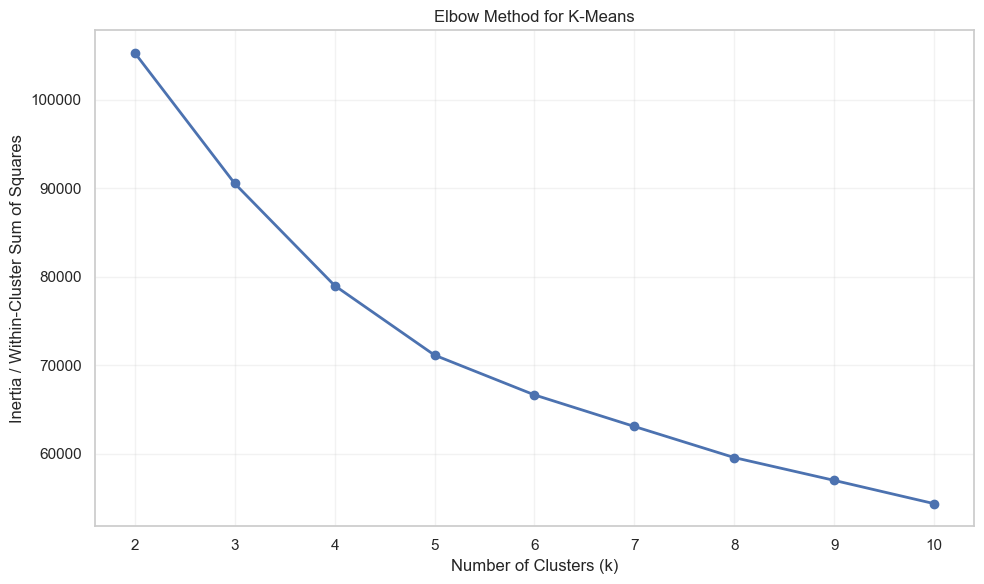

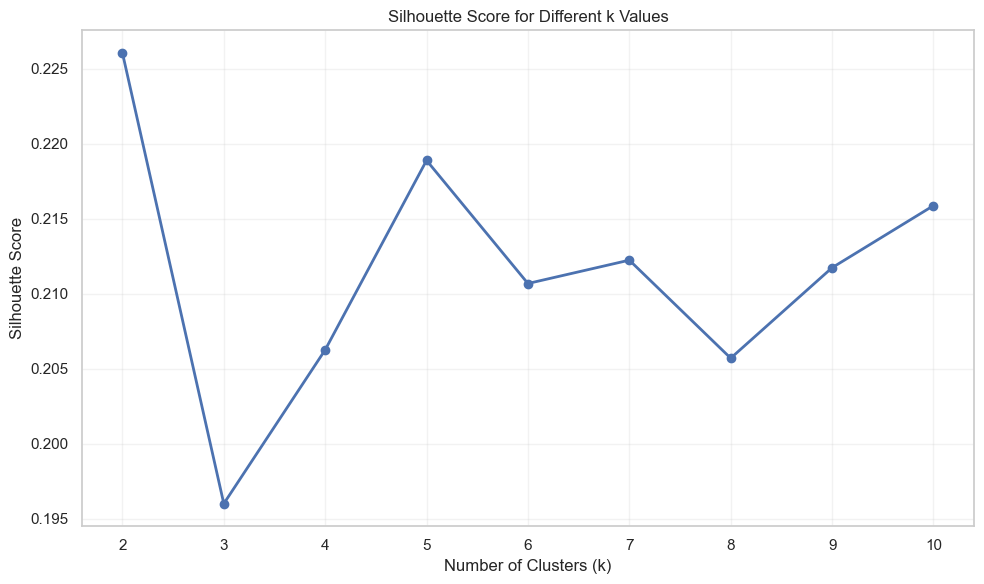


------------------------------------------------------------------------------------------
3.4D | OPTIMAL k DECISION
------------------------------------------------------------------------------------------
Selected k : 2
Selected k inertia    : 105,285.958
Selected k silhouette : 0.2261

Selection basis:
The highest Silhouette Score is used as the primary numerical criterion, while the Elbow Curve is retained as supporting evidence.

                                3.5 | FINAL K-MEANS MODEL                                 
Optimal k : 2
Inertia   : 105,285.958
Silhouette : 0.2261

KMeans_Cluster added to df.
Working clustered dataframe shape : (8950, 18)
KMeans_Cluster added to df_original.

------------------------------------------------------------------------------------------
3.5C | CLUSTER SIZE SUMMARY
------------------------------------------------------------------------------------------

Final Cluster Size Summary


,KMeans_Cluster,customer_count,percentage
0,0,5580,62.346
1,1,3370,37.654



                           3.6 | K-MEANS CLUSTER VISUALISATION                            


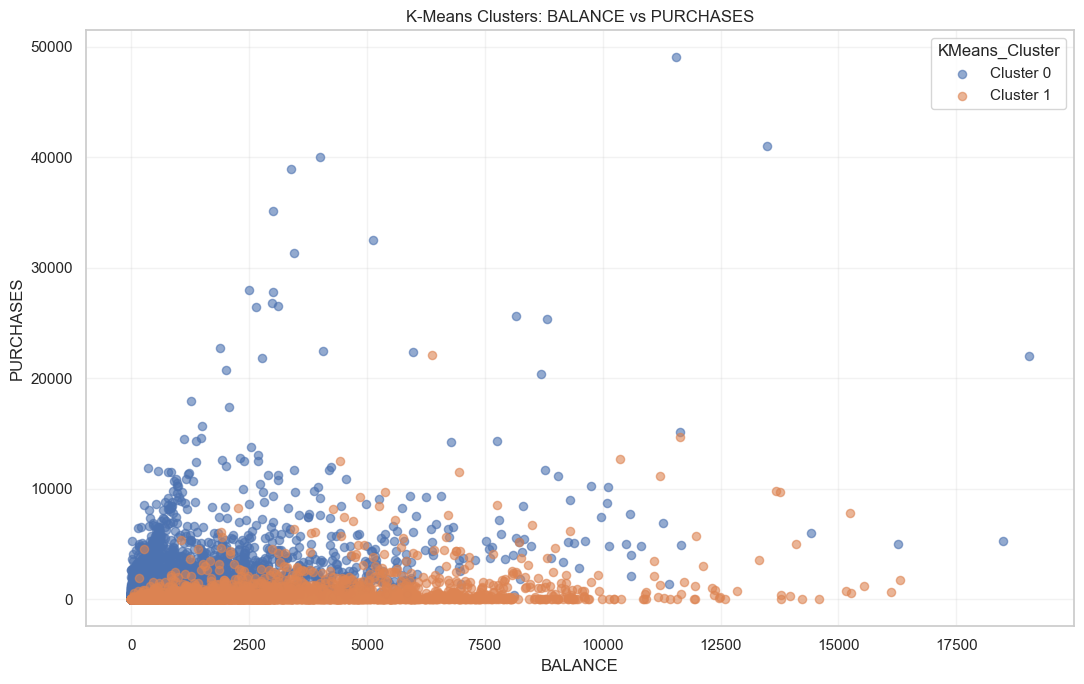

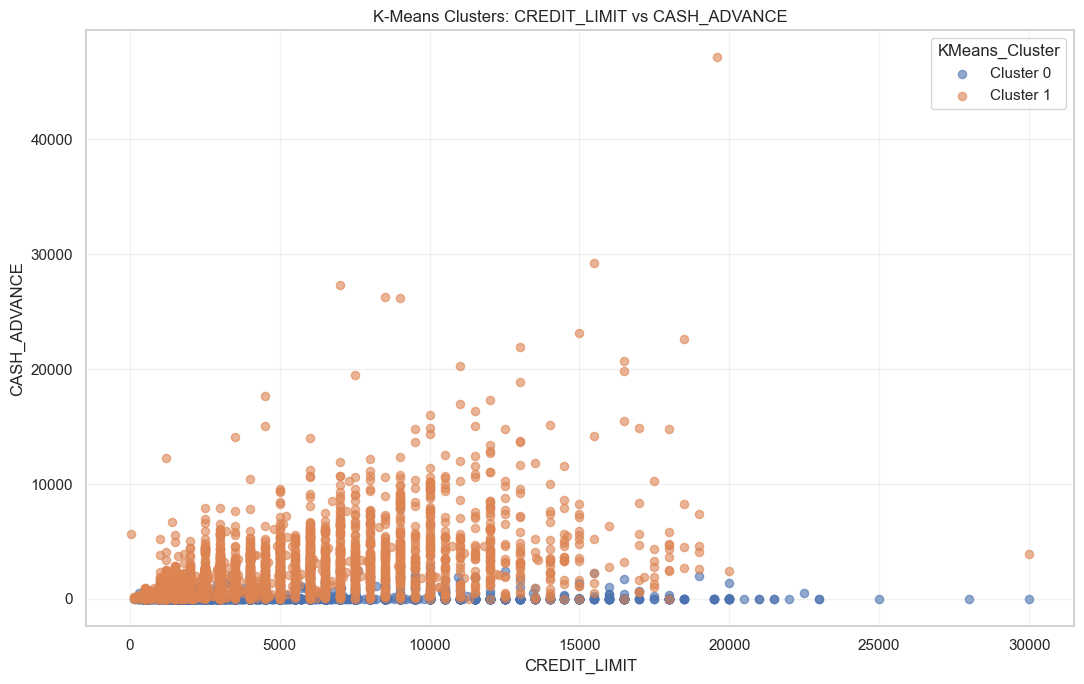

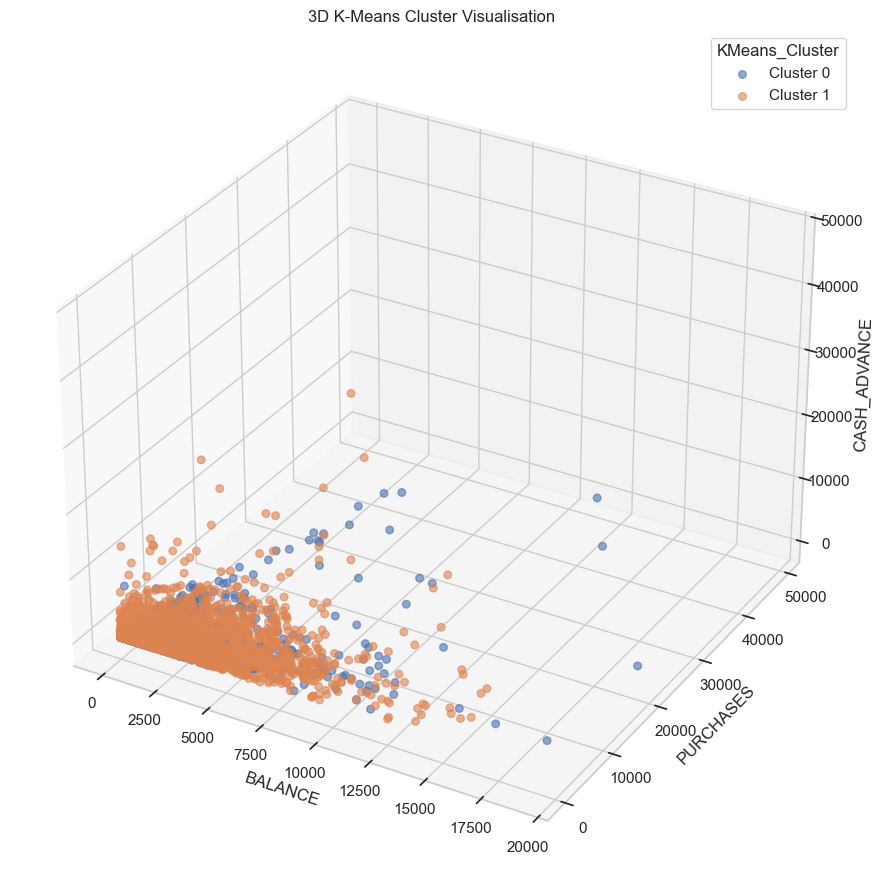


                            3.7 | PROFILE THE K-MEANS CLUSTERS                            
Cluster profiling uses original unscaled feature values.
This keeps financial values interpretable.

Mean Customer Profile by Cluster


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,CUSTOMER_COUNT,CUSTOMER_PERCENT
KMeans_Cluster,,,,,,,,
0,888.694,"1,391.712",120.241,"4,309.177","1,510.299",11.607,5580,62.346
1,"2,683.423",359.920,"2,400.579","4,801.312","2,102.128",11.368,3370,37.654



Additional Behavioural Cluster Profile


,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,PURCHASES_TRX,CASH_ADVANCE_TRX
KMeans_Cluster,,,,,,,,
0,0.854,0.677,0.269,0.517,0.027,0.225,20.316,0.469
1,0.915,0.181,0.092,0.113,0.314,0.036,5.426,7.852



Engineered Behavioural Profile


...


                            3.8 | BUSINESS PERSONA ASSIGNMENT                             
Persona names are descriptive interpretations of the observed cluster characteristics.

------------------------------------------------------------------------------------------
3.8A | FINAL PROFILE WITH BUSINESS PERSONAS
------------------------------------------------------------------------------------------

Final Cluster Profile with Business Personas


,KMeans_Cluster,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,CUSTOMER_COUNT,CUSTOMER_PERCENT,Business_Persona,Key_Characteristics
0,0,888.694,"1,391.712",120.241,"4,309.177","1,510.299",11.607,5580,62.346,Transactors,"high purchase activity, higher full-payment be..."
1,1,"2,683.423",359.920,"2,400.579","4,801.312","2,102.128",11.368,3370,37.654,Cash-Advance Reliant,"high cash-advance activity, above-average cred..."



------------------------------------------------------------------------------------------
3.8B | CLUSTER DIFFERENTIATION SUMMARY
------------------------------------------------------------------------------------------

Cluster Differentiation Summary


,KMeans_Cluster,BALANCE,PURCHASES,PURCHASES_FREQUENCY,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PRC_FULL_PAYMENT,Business_Persona,Key_Characteristics
0,0,888.694,"1,391.712",0.677,120.241,0.027,"4,309.177",0.225,Transactors,"high purchase activity, higher full-payment be..."
1,1,"2,683.423",359.920,0.181,"2,400.579",0.314,"4,801.312",0.036,Cash-Advance Reliant,"high cash-advance activity, above-average cred..."



------------------------------------------------------------------------------------------
3.8C | BUSINESS PERSONA JUSTIFICATION
------------------------------------------------------------------------------------------

Cluster 0 → Transactors
Evidence : high purchase activity, higher full-payment behaviour, higher installment-purchase activity.
Customer Count : 5,580
Customer % : 62.35%
Credit Limit : 4,309.18
Purchases : 1,391.71
Cash Advance : 120.24
Balance : 888.69

Cluster 1 → Cash-Advance Reliant
Evidence : high cash-advance activity, above-average credit limit, above-average balance.
Customer Count : 3,370
Customer % : 37.65%
Credit Limit : 4,801.31
Purchases : 359.92
Cash Advance : 2,400.58
Balance : 2,683.42

                              3.9 | FINAL K-MEANS VALIDATION                              
Selected k             : 2
Final inertia          : 105,285.958
Final silhouette score : 0.2261
Customer records       : 8,950
Unique cluster labels  : 2

Cluster assignment vali

In [20]:
# ============================================================
# STEP 3: DATA PREPROCESSING & K-MEANS CLUSTERING
# Project: Credit Card Customer Segmentation
# ============================================================
#
# 3.0  Input Validation
# 3.1  Data Preprocessing
# 3.2  Feature Engineering
# 3.3  Feature Scaling
# 3.4  Elbow Method & Silhouette Analysis
# 3.5  Final K-Means Model
# 3.6  K-Means Cluster Visualisation
# 3.7  Cluster Profiling
# 3.8  Business Persona Assignment
# 3.9  Final Validation
#
# IMPORTANT:
# Step 1 already contains all required imports.
# No imports are repeated in Step 3.
# ============================================================


# ------------------------------------------------------------
# 3.0 | CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

OUTLIER_IQR_MULTIPLIER = 3.00

SKEWNESS_TRANSFORM_THRESHOLD = 2.00

K_VALUES = range(2, 11)

N_INIT_EVALUATION = 10

N_INIT_FINAL = 20

MAX_ITER = 500

K_OPTIMAL = None


# ------------------------------------------------------------
# 3.0A | HELPER FUNCTIONS
# ------------------------------------------------------------

def clustering_header(title):

    print("\n" + "=" * 90)
    print(title.center(90))
    print("=" * 90)


def clustering_section(title):

    print("\n" + "-" * 90)
    print(title)
    print("-" * 90)


def display_clustering_table(
    table,
    title=None,
    decimals=3
):

    if title:

        print(
            f"\n{title}"
        )

    if isinstance(
        table,
        pd.Series
    ):

        table = table.to_frame()

    display(
        table.round(
            decimals
        )
    )


# ============================================================
# 3.0 | INPUT VALIDATION
# ============================================================

clustering_header(
    "STEP 3: DATA PREPROCESSING & K-MEANS CLUSTERING"
)


if "df" not in globals():

    raise NameError(
        "Run Step 1 first. "
        "The dataframe 'df' was not found."
    )


if not isinstance(
    df,
    pd.DataFrame
):

    raise TypeError(
        "'df' must be a pandas DataFrame."
    )


if df.empty:

    raise ValueError(
        "'df' is empty. "
        "Check Step 1 and Step 2."
    )


if "df_original" not in globals():

    raise NameError(
        "'df_original' was not found. "
        "Run Step 1 again so the original dataset is preserved."
    )


if len(df) != len(df_original):

    raise ValueError(
        "df and df_original have different row counts."
    )


df_before_step3 = (
    df.copy(
        deep=True
    )
)


original_rows = len(df)


print(
    f"Customer records : "
    f"{original_rows:,}"
)

print(
    f"Working features : "
    f"{df.shape[1]:,}"
)

print(
    "\nOriginal source dataframe "
    "is preserved in df_original."
)


# ============================================================
# 3.1 | CREATE PREPROCESSING COPY
# ============================================================

clustering_section(
    "3.1 | CREATE PREPROCESSING COPY"
)


df_preprocessed = (
    df.copy(
        deep=True
    )
)


print(
    "Separate preprocessing dataframe created."
)

print(
    f"Rows preserved : "
    f"{len(df_preprocessed):,}"
)

print(
    f"Features       : "
    f"{df_preprocessed.shape[1]:,}"
)


# ============================================================
# 3.1A | NUMERIC FEATURES
# ============================================================

numeric_columns = (

    df_preprocessed

    .select_dtypes(
        include="number"
    )

    .columns

    .tolist()
)


print(
    f"\nNumeric features : "
    f"{len(numeric_columns):,}"
)


# ============================================================
# 3.1B | INFINITE VALUE CHECK
# ============================================================

infinite_count = int(

    np.isinf(
        df_preprocessed[
            numeric_columns
        ].to_numpy()
    ).sum()

)


print(
    f"Infinite values before preprocessing : "
    f"{infinite_count:,}"
)


if infinite_count > 0:

    df_preprocessed[
        numeric_columns
    ] = (

        df_preprocessed[
            numeric_columns
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan
        )

    )

    print(
        "Infinite values converted to NaN."
    )

else:

    print(
        "No infinite values require treatment."
    )


# ============================================================
# 3.1C | MISSING VALUE TREATMENT
# ============================================================

clustering_section(
    "3.1C | MISSING VALUE TREATMENT"
)


missing_before = (

    df_preprocessed[
        numeric_columns
    ]

    .isna()

    .sum()
)


missing_before = (
    missing_before[
        missing_before > 0
    ]
)


if missing_before.empty:

    print(
        "No missing numeric values found."
    )

else:

    display_clustering_table(
        missing_before,
        "Missing Values Before Imputation"
    )


imputation_records = []


for col in numeric_columns:

    missing_count = int(

        df_preprocessed[
            col
        ]

        .isna()

        .sum()

    )


    if missing_count == 0:

        continue


    median_value = (

        df_preprocessed[
            col
        ]

        .median()

    )


    df_preprocessed[
        col
    ] = (

        df_preprocessed[
            col
        ]

        .fillna(
            median_value
        )

    )


    imputation_records.append({

        "feature":
            col,

        "missing_before":
            missing_count,

        "method":
            "Median",

        "imputation_value":
            median_value

    })


imputation_summary = (
    pd.DataFrame(
        imputation_records
    )
)


if imputation_summary.empty:

    print(
        "\nNo imputation was required."
    )

else:

    display_clustering_table(
        imputation_summary,
        "Missing-Value Treatment Summary"
    )


missing_after = int(

    df_preprocessed[
        numeric_columns
    ]

    .isna()

    .sum()

    .sum()

)


print(
    f"\nMissing values after imputation : "
    f"{missing_after:,}"
)


if missing_after != 0:

    raise ValueError(
        "Missing values remain after imputation."
    )


print(
    "Missing-value validation : PASSED"
)


# ============================================================
# 3.1D | FREQUENCY RANGE REVIEW
# ============================================================

clustering_section(
    "3.1D | FREQUENCY / PROPORTION RANGE REVIEW"
)


frequency_columns = [

    "BALANCE_FREQUENCY",

    "PURCHASES_FREQUENCY",

    "ONEOFF_PURCHASES_FREQUENCY",

    "PURCHASES_INSTALLMENTS_FREQUENCY",

    "CASH_ADVANCE_FREQUENCY",

    "PRC_FULL_PAYMENT"

]


frequency_columns = [

    col

    for col in frequency_columns

    if col in df_preprocessed.columns

]


frequency_records = []


for col in frequency_columns:

    values = (
        df_preprocessed[
            col
        ]
    )


    outside_count = int(

        (

            (values < 0)

            |

            (values > 1)

        ).sum()

    )


    frequency_records.append({

        "feature":
            col,

        "minimum":
            values.min(),

        "maximum":
            values.max(),

        "outside_0_1_count":
            outside_count

    })


frequency_summary = (
    pd.DataFrame(
        frequency_records
    )
)


display_clustering_table(
    frequency_summary,
    "Frequency / Proportion Validation"
)


frequency_issue_count = int(

    frequency_summary[
        "outside_0_1_count"
    ]

    .sum()

)


print(
    f"\nTotal values outside 0–1 range : "
    f"{frequency_issue_count:,}"
)


print(
    "\nDecision:"
)


print(
    "Unusual CASH_ADVANCE_FREQUENCY values are retained "
    "because the source variable definition is not changed "
    "without source-level confirmation."
)


# ============================================================
# 3.1E | PURCHASE COMPONENT CONSISTENCY
# ============================================================

clustering_section(
    "3.1E | PURCHASE-COMPONENT CONSISTENCY"
)


if all(

    col in df_preprocessed.columns

    for col in [

        "PURCHASES",

        "ONEOFF_PURCHASES",

        "INSTALLMENTS_PURCHASES"

    ]

):


    component_sum = (

        df_preprocessed[
            "ONEOFF_PURCHASES"
        ]

        +

        df_preprocessed[
            "INSTALLMENTS_PURCHASES"
        ]

    )


    purchase_difference = (

        df_preprocessed[
            "PURCHASES"
        ]

        -

        component_sum

    ).abs()


    purchase_mismatch_count = int(

        (

            purchase_difference

            > PURCHASE_TOLERANCE

        ).sum()

    )


    print(
        f"Rows exceeding tolerance : "
        f"{purchase_mismatch_count:,}"
    )


    print(
        f"Tolerance                 : "
        f"{PURCHASE_TOLERANCE}"
    )


    print(
        "\nDecision:"
    )


    print(
        "Original purchase variables are retained. "
        "No source values are automatically overwritten."
    )


else:

    purchase_mismatch_count = 0

    print(
        "Purchase-component validation skipped."
    )


# ============================================================
# 3.1F | CONTROLLED OUTLIER TREATMENT
# ============================================================

clustering_section(
    "3.1F | CONTROLLED OUTLIER TREATMENT"
)


print(
    "Method : 3 × IQR capping"
)


print(
    "\nStep 2 used 1.5 × IQR for exploratory screening."
)


print(
    "A wider 3 × IQR boundary is used here to reduce "
    "the influence of extreme financial observations "
    "without deleting customers."
)


amount_features = [

    "BALANCE",

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES",

    "CASH_ADVANCE",

    "PAYMENTS",

    "MINIMUM_PAYMENTS",

    "CREDIT_LIMIT"

]


amount_features = [

    col

    for col in amount_features

    if col in df_preprocessed.columns

]


outlier_records = []


for col in amount_features:

    q1 = (
        df_preprocessed[
            col
        ].quantile(
            0.25
        )
    )


    q3 = (
        df_preprocessed[
            col
        ].quantile(
            0.75
        )
    )


    iqr = q3 - q1


    lower_bound = (

        q1

        -

        OUTLIER_IQR_MULTIPLIER
        * iqr

    )


    upper_bound = (

        q3

        +

        OUTLIER_IQR_MULTIPLIER
        * iqr

    )


    lower_count = int(

        (

            df_preprocessed[
                col
            ]

            < lower_bound

        ).sum()

    )


    upper_count = int(

        (

            df_preprocessed[
                col
            ]

            > upper_bound

        ).sum()

    )


    df_preprocessed[
        col
    ] = (

        df_preprocessed[
            col
        ]

        .clip(

            lower=lower_bound,

            upper=upper_bound

        )

    )


    outlier_records.append({

        "feature":
            col,

        "Q1":
            q1,

        "Q3":
            q3,

        "IQR":
            iqr,

        "lower_bound":
            lower_bound,

        "upper_bound":
            upper_bound,

        "lower_capped":
            lower_count,

        "upper_capped":
            upper_count,

        "total_capped":
            lower_count + upper_count

    })


outlier_summary = (
    pd.DataFrame(
        outlier_records
    )
)


display_clustering_table(
    outlier_summary,
    "3 × IQR Outlier-Capping Summary"
)


print(
    f"\nTotal feature-level values capped : "
    f"{int(outlier_summary['total_capped'].sum()):,}"
)


print(
    "Customer rows removed : 0"
)


# ============================================================
# 3.1G | SKEWNESS REVIEW
# ============================================================

clustering_section(
    "3.1G | SKEWNESS REVIEW AFTER OUTLIER TREATMENT"
)


skewness_values = (

    df_preprocessed[
        numeric_columns
    ]

    .skew()

    .sort_values(

        key=lambda x: x.abs(),

        ascending=False

    )

)


display_clustering_table(
    skewness_values.rename(
        "skewness"
    ),
    "Feature Skewness"
)


high_skew_features = (

    skewness_values[

        skewness_values.abs()

        >=

        SKEWNESS_TRANSFORM_THRESHOLD

    ]

)


print(
    f"\nFeatures with |skewness| >= "
    f"{SKEWNESS_TRANSFORM_THRESHOLD:.1f}: "
    f"{len(high_skew_features):,}"
)


# ============================================================
# 3.1H | SELECTIVE LOG1P FOR TRANSACTION COUNTS
# ============================================================
#
# Only transaction-count variables are transformed here.
# Monetary variables remain on their capped original scale
# so that cluster profiles and engineered financial ratios
# remain interpretable.
# ============================================================

clustering_section(
    "3.1H | SELECTIVE LOG1P TRANSFORMATION"
)


transaction_count_features = [

    "PURCHASES_TRX",

    "CASH_ADVANCE_TRX"

]


log_transform_features = [

    col

    for col in transaction_count_features

    if (

        col in df_preprocessed.columns

        and

        (
            df_preprocessed[
                col
            ] >= 0
        ).all()

        and

        abs(
            df_preprocessed[
                col
            ].skew()
        )

        >=

        SKEWNESS_TRANSFORM_THRESHOLD

    )

]


if log_transform_features:

    print(
        "Selected log1p features:"
    )


    print(
        ", ".join(
            log_transform_features
        )
    )


    for col in log_transform_features:

        df_preprocessed[
            col
        ] = np.log1p(
            df_preprocessed[
                col
            ]
        )


else:

    print(
        "No transaction-count feature met "
        "the log1p transformation rule."
    )


# ============================================================
# 3.2 | FEATURE ENGINEERING
# ============================================================

clustering_section(
    "3.2 | BEHAVIOURAL FEATURE ENGINEERING"
)


print(
    "Interpretable behavioural ratios are created."
)


print(
    "Zero-purchase customers are explicitly handled."
)


# ------------------------------------------------------------
# Purchase-to-Credit Ratio
# ------------------------------------------------------------

if {

    "PURCHASES",

    "CREDIT_LIMIT"

}.issubset(
    df_preprocessed.columns
):


    df_preprocessed[
        "PURCHASE_TO_CREDIT_RATIO"
    ] = (

        df_preprocessed[
            "PURCHASES"
        ]

        /

        df_preprocessed[
            "CREDIT_LIMIT"
        ].replace(
            0,
            np.nan
        )

    )


    print(
        "Created : PURCHASE_TO_CREDIT_RATIO"
    )


# ------------------------------------------------------------
# Cash-Advance-to-Credit Ratio
# ------------------------------------------------------------

if {

    "CASH_ADVANCE",

    "CREDIT_LIMIT"

}.issubset(
    df_preprocessed.columns
):


    df_preprocessed[
        "CASH_ADVANCE_TO_CREDIT_RATIO"
    ] = (

        df_preprocessed[
            "CASH_ADVANCE"
        ]

        /

        df_preprocessed[
            "CREDIT_LIMIT"
        ].replace(
            0,
            np.nan
        )

    )


    print(
        "Created : CASH_ADVANCE_TO_CREDIT_RATIO"
    )


# ------------------------------------------------------------
# One-Off Purchase Share
# ------------------------------------------------------------

if {

    "ONEOFF_PURCHASES",

    "PURCHASES"

}.issubset(
    df_preprocessed.columns
):


    df_preprocessed[
        "ONEOFF_PURCHASE_SHARE"
    ] = np.where(

        df_preprocessed[
            "PURCHASES"
        ] > 0,

        (

            df_preprocessed[
                "ONEOFF_PURCHASES"
            ]

            /

            df_preprocessed[
                "PURCHASES"
            ]

        ),

        0

    )


    print(
        "Created : ONEOFF_PURCHASE_SHARE"
    )


# ------------------------------------------------------------
# Installment Purchase Share
# ------------------------------------------------------------

if {

    "INSTALLMENTS_PURCHASES",

    "PURCHASES"

}.issubset(
    df_preprocessed.columns
):


    df_preprocessed[
        "INSTALLMENT_PURCHASE_SHARE"
    ] = np.where(

        df_preprocessed[
            "PURCHASES"
        ] > 0,

        (

            df_preprocessed[
                "INSTALLMENTS_PURCHASES"
            ]

            /

            df_preprocessed[
                "PURCHASES"
            ]

        ),

        0

    )


    print(
        "Created : INSTALLMENT_PURCHASE_SHARE"
    )


engineered_features = [

    col

    for col in [

        "PURCHASE_TO_CREDIT_RATIO",

        "CASH_ADVANCE_TO_CREDIT_RATIO",

        "ONEOFF_PURCHASE_SHARE",

        "INSTALLMENT_PURCHASE_SHARE"

    ]

    if col in df_preprocessed.columns

]


print(
    f"\nEngineered features : "
    f"{len(engineered_features):,}"
)


# ============================================================
# 3.2A | ENGINEERED FEATURE VALIDATION
# ============================================================

clustering_section(
    "3.2A | ENGINEERED FEATURE VALIDATION"
)


ratio_validation = pd.DataFrame({

    "minimum":

        df_preprocessed[
            engineered_features
        ].min(),

    "median":

        df_preprocessed[
            engineered_features
        ].median(),

    "maximum":

        df_preprocessed[
            engineered_features
        ].max(),

    "missing":

        df_preprocessed[
            engineered_features
        ].isna().sum()

})


display_clustering_table(
    ratio_validation,
    "Engineered Feature Validation"
)


# ============================================================
# 3.2B | RATIO MISSING-VALUE HANDLING
# ============================================================

for col in engineered_features:

    if (
        df_preprocessed[
            col
        ].isna().any()
    ):

        median_value = (

            df_preprocessed[
                col
            ].median()

        )


        df_preprocessed[
            col
        ] = (

            df_preprocessed[
                col
            ]

            .fillna(
                median_value
            )

        )


engineered_missing_after = int(

    df_preprocessed[
        engineered_features
    ]

    .isna()

    .sum()

    .sum()

)


print(
    f"Missing engineered values after treatment : "
    f"{engineered_missing_after:,}"
)


if engineered_missing_after != 0:

    raise ValueError(
        "Engineered features still contain missing values."
    )


# ============================================================
# 3.2C | ENGINEERED RATIO EXTREME-VALUE REVIEW
# ============================================================

clustering_section(
    "3.2C | ENGINEERED RATIO EXTREME-VALUE REVIEW"
)


ratio_extreme_summary = pd.DataFrame({

    "feature":
        engineered_features,

    "maximum": [

        df_preprocessed[
            col
        ].max()

        for col in engineered_features

    ],

    "99th_percentile": [

        df_preprocessed[
            col
        ].quantile(
            0.99
        )

        for col in engineered_features

    ]

})


display_clustering_table(
    ratio_extreme_summary,
    "Engineered Ratio Distribution Check"
)


# ============================================================
# 3.2D | RATIO FEATURE DECISION
# ============================================================

clustering_section(
    "3.2D | RATIO FEATURE DECISION"
)


ratio_features_for_clustering = [

    "PURCHASE_TO_CREDIT_RATIO",

    "ONEOFF_PURCHASE_SHARE",

    "INSTALLMENT_PURCHASE_SHARE"

]


excluded_ratio_features = [

    "CASH_ADVANCE_TO_CREDIT_RATIO"

]


print(
    "Included engineered features:"
)


for col in ratio_features_for_clustering:

    print(
        f"• {col}"
    )


print(
    "\nExcluded engineered feature:"
)


for col in excluded_ratio_features:

    print(
        f"• {col}"
    )


print(
    "\nReason:"
)


print(
    "CASH_ADVANCE_TO_CREDIT_RATIO is excluded because "
    "its extreme upper tail can disproportionately affect "
    "distance-based K-Means clustering."
)


# ============================================================
# 3.3 | FINAL CLUSTERING FEATURE SELECTION
# ============================================================

clustering_section(
    "3.3 | FINAL CLUSTERING FEATURE SELECTION"
)


# ------------------------------------------------------------
# Core clustering features
# ------------------------------------------------------------

base_clustering_features = [

    "BALANCE",

    "BALANCE_FREQUENCY",

    "PURCHASES",

    "PURCHASES_FREQUENCY",

    "PURCHASES_TRX",

    "CASH_ADVANCE",

    "CASH_ADVANCE_FREQUENCY",

    "CASH_ADVANCE_TRX",

    "CREDIT_LIMIT",

    "PAYMENTS",

    "MINIMUM_PAYMENTS",

    "PRC_FULL_PAYMENT"

]


# ------------------------------------------------------------
# Profile-only features
# ------------------------------------------------------------
#
# These variables are retained for interpretation but are not
# used directly in K-Means to reduce redundancy / low-value
# contribution to the distance calculation.
# ------------------------------------------------------------

profile_only_features = [

    "TENURE",

    "ONEOFF_PURCHASES_FREQUENCY",

    "PURCHASES_INSTALLMENTS_FREQUENCY"

]


final_clustering_features = [

    col

    for col in (

        base_clustering_features

        +

        ratio_features_for_clustering

    )

    if col in df_preprocessed.columns

]


print(
    f"Core clustering features : "
    f"{len(base_clustering_features):,}"
)


print(
    f"Engineered features      : "
    f"{len(ratio_features_for_clustering):,}"
)


print(
    f"Final clustering features: "
    f"{len(final_clustering_features):,}"
)


print(
    "\nFinal K-Means features:"
)


for index, col in enumerate(

    final_clustering_features,

    start=1

):

    print(
        f"{index:2d}. {col}"
    )


print(
    "\nProfile-only features:"
)


for index, col in enumerate(

    profile_only_features,

    start=1

):

    print(
        f"{index:2d}. {col}"
    )


# ============================================================
# 3.3A | FEATURE SELECTION VALIDATION
# ============================================================

required_clustering_features = (

    base_clustering_features

    +

    ratio_features_for_clustering

)


missing_required_features = [

    col

    for col in required_clustering_features

    if col not in df_preprocessed.columns

]


if missing_required_features:

    raise ValueError(

        "Required clustering features are missing: "

        +

        ", ".join(
            missing_required_features
        )

    )


print(
    "\nFeature-selection validation : PASSED"
)


# ============================================================
# 3.3B | CREATE UNSCALED CLUSTERING MATRIX
# ============================================================

df_clustering = (

    df_preprocessed[
        final_clustering_features
    ]

    .copy()

)


print(
    f"\nUnscaled clustering matrix : "
    f"{df_clustering.shape}"
)


# ============================================================
# 3.3C | PRE-SCALING VALIDATION
# ============================================================

pre_scaling_missing = int(

    df_clustering
    .isna()
    .sum()
    .sum()

)


pre_scaling_infinite = int(

    np.isinf(
        df_clustering.to_numpy()
    ).sum()

)


print(
    f"Missing values  : "
    f"{pre_scaling_missing:,}"
)


print(
    f"Infinite values : "
    f"{pre_scaling_infinite:,}"
)


if pre_scaling_missing != 0:

    raise ValueError(
        "Missing values remain before scaling."
    )


if pre_scaling_infinite != 0:

    raise ValueError(
        "Infinite values remain before scaling."
    )


# ============================================================
# 3.3D | STANDARD SCALING
# ============================================================

clustering_section(
    "3.3D | STANDARD SCALING"
)


print(
    "Method : StandardScaler"
)


print(
    "Reason : K-Means uses distance calculations, "
    "so features must be placed on comparable scales."
)


scaler = StandardScaler()


X_scaled_array = scaler.fit_transform(
    df_clustering
)


X_scaled = pd.DataFrame(

    X_scaled_array,

    columns=final_clustering_features,

    index=df_clustering.index

)


print(
    f"\nScaled matrix shape : "
    f"{X_scaled.shape}"
)


# ============================================================
# 3.3E | SCALING VALIDATION
# ============================================================

scaling_validation = pd.DataFrame({

    "mean":
        X_scaled.mean(),

    "std":
        X_scaled.std(
            ddof=0
        )

})


display_clustering_table(
    scaling_validation,
    "Scaling Validation"
)


max_mean_error = float(

    X_scaled.mean()
    .abs()
    .max()

)


max_std_error = float(

    (

        X_scaled.std(
            ddof=0
        )

        - 1

    )

    .abs()
    .max()

)


print(
    f"\nMaximum absolute mean error : "
    f"{max_mean_error:.10f}"
)


print(
    f"Maximum standard-deviation error : "
    f"{max_std_error:.10f}"
)


# ============================================================
# 3.4 | ELBOW METHOD & SILHOUETTE ANALYSIS
# ============================================================

clustering_header(
    "3.4 | ELBOW METHOD & SILHOUETTE ANALYSIS"
)


print(
    "K-Means will be evaluated for k = 2 through k = 10."
)


print(
    "\nConfiguration:"
)


print(
    "init = 'k-means++'"
)


print(
    f"n_init = {N_INIT_EVALUATION}"
)


print(
    f"max_iter = {MAX_ITER}"
)


print(
    f"random_state = {RANDOM_STATE}"
)


k_results = []


k_models = {}


for k in K_VALUES:

    model = KMeans(

        n_clusters=k,

        init="k-means++",

        n_init=N_INIT_EVALUATION,

        max_iter=MAX_ITER,

        random_state=RANDOM_STATE

    )


    labels = model.fit_predict(
        X_scaled
    )


    inertia = model.inertia_


    silhouette = silhouette_score(

        X_scaled,

        labels

    )


    k_models[k] = model


    k_results.append({

        "k":
            k,

        "inertia":
            inertia,

        "silhouette_score":
            silhouette

    })


k_results_df = (
    pd.DataFrame(
        k_results
    )
)


display_clustering_table(
    k_results_df,
    "K-Means Evaluation Results",
    decimals=4
)


# ============================================================
# 3.4A | BEST SILHOUETTE
# ============================================================

best_silhouette_row = (

    k_results_df

    .loc[

        k_results_df[
            "silhouette_score"
        ].idxmax()

    ]

)


best_silhouette_k = int(

    best_silhouette_row[
        "k"
    ]

)


best_silhouette_value = float(

    best_silhouette_row[
        "silhouette_score"
    ]

)


print(
    "\nHighest Silhouette Score:"
)


print(
    f"k = {best_silhouette_k}"
)


print(
    f"Score = {best_silhouette_value:.4f}"
)


# ============================================================
# 3.4B | ELBOW CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    k_results_df["k"],

    k_results_df["inertia"],

    marker="o",

    linewidth=2

)


plt.xticks(
    list(K_VALUES)
)


plt.xlabel(
    "Number of Clusters (k)"
)


plt.ylabel(
    "Inertia / Within-Cluster Sum of Squares"
)


plt.title(
    "Elbow Method for K-Means"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ============================================================
# 3.4C | SILHOUETTE CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    k_results_df["k"],

    k_results_df[
        "silhouette_score"
    ],

    marker="o",

    linewidth=2

)


plt.xticks(
    list(K_VALUES)
)


plt.xlabel(
    "Number of Clusters (k)"
)


plt.ylabel(
    "Silhouette Score"
)


plt.title(
    "Silhouette Score for Different k Values"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ============================================================
# 3.4D | OPTIMAL k DECISION
# ============================================================

clustering_section(
    "3.4D | OPTIMAL k DECISION"
)


if K_OPTIMAL is None:

    K_OPTIMAL = best_silhouette_k


print(
    f"Selected k : "
    f"{K_OPTIMAL}"
)


if K_OPTIMAL not in K_VALUES:

    raise ValueError(
        f"K_OPTIMAL must be one of "
        f"{list(K_VALUES)}."
    )


selected_k_result = (

    k_results_df[

        k_results_df[
            "k"
        ]

        ==

        K_OPTIMAL

    ]

    .iloc[0]

)


selected_k_inertia = float(

    selected_k_result[
        "inertia"
    ]

)


selected_k_silhouette = float(

    selected_k_result[
        "silhouette_score"
    ]

)


print(
    f"Selected k inertia    : "
    f"{selected_k_inertia:,.3f}"
)


print(
    f"Selected k silhouette : "
    f"{selected_k_silhouette:.4f}"
)


print(
    "\nSelection basis:"
)


print(
    "The highest Silhouette Score is used as the "
    "primary numerical criterion, while the Elbow Curve "
    "is retained as supporting evidence."
)


# ============================================================
# 3.5 | FINAL K-MEANS MODEL
# ============================================================

clustering_header(
    "3.5 | FINAL K-MEANS MODEL"
)


final_kmeans = KMeans(

    n_clusters=K_OPTIMAL,

    init="k-means++",

    n_init=N_INIT_FINAL,

    max_iter=MAX_ITER,

    random_state=RANDOM_STATE

)


final_cluster_labels = (

    final_kmeans

    .fit_predict(
        X_scaled
    )

)


final_inertia = (

    final_kmeans
    .inertia_

)


final_silhouette = (

    silhouette_score(

        X_scaled,

        final_cluster_labels

    )

)


print(
    f"Optimal k : "
    f"{K_OPTIMAL}"
)


print(
    f"Inertia   : "
    f"{final_inertia:,.3f}"
)


print(
    f"Silhouette : "
    f"{final_silhouette:.4f}"
)


# ============================================================
# 3.5A | ADD CLUSTER LABELS TO WORKING DATA
# ============================================================

df_kmeans = (
    df.copy(
        deep=True
    )
)


df_kmeans[
    "KMeans_Cluster"
] = final_cluster_labels


print(
    "\nKMeans_Cluster added to df."
)


print(
    f"Working clustered dataframe shape : "
    f"{df_kmeans.shape}"
)


# ============================================================
# 3.5B | ADD CLUSTER LABELS TO ORIGINAL DATA
# ============================================================

df_kmeans_original = (

    df_original.copy(
        deep=True
    )

)


df_kmeans_original[
    "KMeans_Cluster"
] = final_cluster_labels


print(
    "KMeans_Cluster added to df_original."
)


# ============================================================
# 3.5C | CLUSTER SIZE SUMMARY
# ============================================================

clustering_section(
    "3.5C | CLUSTER SIZE SUMMARY"
)


cluster_counts = (

    df_kmeans[
        "KMeans_Cluster"
    ]

    .value_counts()

    .sort_index()

)


cluster_size_summary = pd.DataFrame({

    "KMeans_Cluster":
        cluster_counts.index,

    "customer_count":
        cluster_counts.values,

    "percentage":
        (

            cluster_counts.values

            /

            len(df_kmeans)

            *

            100

        )

})


display_clustering_table(
    cluster_size_summary,
    "Final Cluster Size Summary"
)


# ============================================================
# 3.6 | K-MEANS CLUSTER VISUALISATION
# ============================================================

clustering_header(
    "3.6 | K-MEANS CLUSTER VISUALISATION"
)


# ------------------------------------------------------------
# 3.6A | BALANCE VS PURCHASES
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)


for cluster in sorted(

    df_kmeans[
        "KMeans_Cluster"
    ].unique()

):

    cluster_data = (

        df_kmeans[

            df_kmeans[
                "KMeans_Cluster"
            ]

            ==

            cluster

        ]

    )


    plt.scatter(

        cluster_data[
            "BALANCE"
        ],

        cluster_data[
            "PURCHASES"
        ],

        alpha=0.60,

        s=35,

        label=f"Cluster {cluster}"

    )


plt.xlabel(
    "BALANCE"
)


plt.ylabel(
    "PURCHASES"
)


plt.title(
    "K-Means Clusters: BALANCE vs PURCHASES"
)


plt.legend(
    title="KMeans_Cluster"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ------------------------------------------------------------
# 3.6B | CREDIT LIMIT VS CASH ADVANCE
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)


for cluster in sorted(

    df_kmeans[
        "KMeans_Cluster"
    ].unique()

):

    cluster_data = (

        df_kmeans[

            df_kmeans[
                "KMeans_Cluster"
            ]

            ==

            cluster

        ]

    )


    plt.scatter(

        cluster_data[
            "CREDIT_LIMIT"
        ],

        cluster_data[
            "CASH_ADVANCE"
        ],

        alpha=0.60,

        s=35,

        label=f"Cluster {cluster}"

    )


plt.xlabel(
    "CREDIT_LIMIT"
)


plt.ylabel(
    "CASH_ADVANCE"
)


plt.title(
    "K-Means Clusters: CREDIT_LIMIT vs CASH_ADVANCE"
)


plt.legend(
    title="KMeans_Cluster"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ------------------------------------------------------------
# 3.6C | 3D VISUALISATION
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12, 9)
)


ax = fig.add_subplot(

    111,

    projection="3d"

)


for cluster in sorted(

    df_kmeans[
        "KMeans_Cluster"
    ].unique()

):

    cluster_data = (

        df_kmeans[

            df_kmeans[
                "KMeans_Cluster"
            ]

            ==

            cluster

        ]

    )


    ax.scatter(

        cluster_data[
            "BALANCE"
        ],

        cluster_data[
            "PURCHASES"
        ],

        cluster_data[
            "CASH_ADVANCE"
        ],

        alpha=0.60,

        s=30,

        label=f"Cluster {cluster}"

    )


ax.set_xlabel(
    "BALANCE"
)


ax.set_ylabel(
    "PURCHASES"
)


ax.set_zlabel(
    "CASH_ADVANCE"
)


ax.set_title(
    "3D K-Means Cluster Visualisation"
)


ax.legend(
    title="KMeans_Cluster"
)


plt.tight_layout()


plt.show()


# ============================================================
# 3.7 | CLUSTER PROFILING
# ============================================================

clustering_header(
    "3.7 | PROFILE THE K-MEANS CLUSTERS"
)


print(
    "Cluster profiling uses original unscaled feature values."
)


print(
    "This keeps financial values interpretable."
)


profile_features = [

    "BALANCE",

    "PURCHASES",

    "CASH_ADVANCE",

    "CREDIT_LIMIT",

    "PAYMENTS",

    "TENURE"

]


profile_features = [

    col

    for col in profile_features

    if col in df_kmeans.columns

]


cluster_profile = (

    df_kmeans

    .groupby(
        "KMeans_Cluster"
    )[profile_features]

    .mean()

)


cluster_profile[
    "CUSTOMER_COUNT"
] = (

    df_kmeans

    .groupby(
        "KMeans_Cluster"
    )

    .size()

)


cluster_profile[
    "CUSTOMER_PERCENT"
] = (

    cluster_profile[
        "CUSTOMER_COUNT"
    ]

    /

    len(df_kmeans)

    *

    100

)


display_clustering_table(
    cluster_profile,
    "Mean Customer Profile by Cluster"
)


# ============================================================
# 3.7A | ADDITIONAL BEHAVIOURAL PROFILE
# ============================================================

additional_profile_features = [

    "BALANCE_FREQUENCY",

    "PURCHASES_FREQUENCY",

    "ONEOFF_PURCHASES_FREQUENCY",

    "PURCHASES_INSTALLMENTS_FREQUENCY",

    "CASH_ADVANCE_FREQUENCY",

    "PRC_FULL_PAYMENT",

    "PURCHASES_TRX",

    "CASH_ADVANCE_TRX"

]


additional_profile_features = [

    col

    for col in additional_profile_features

    if col in df_kmeans.columns

]


additional_cluster_profile = (

    df_kmeans

    .groupby(
        "KMeans_Cluster"
    )[additional_profile_features]

    .mean()

)


display_clustering_table(
    additional_cluster_profile,
    "Additional Behavioural Cluster Profile"
)


# ============================================================
# 3.7B | ENGINEERED FEATURE PROFILE
# ============================================================

engineered_profile_features = [

    "PURCHASE_TO_CREDIT_RATIO",

    "ONEOFF_PURCHASE_SHARE",

    "INSTALLMENT_PURCHASE_SHARE"

]


engineered_profile_features = [

    col

    for col in engineered_profile_features

    if col in df_preprocessed.columns

]


df_profile_engineered = (

    df_preprocessed[
        engineered_profile_features
    ]

    .copy()

)


df_profile_engineered[
    "KMeans_Cluster"
] = final_cluster_labels


engineered_cluster_profile = (

    df_profile_engineered

    .groupby(
        "KMeans_Cluster"
    )[engineered_profile_features]

    .mean()

)


display_clustering_table(
    engineered_cluster_profile,
    "Engineered Behavioural Profile"
)


# ============================================================
# 3.8 | BUSINESS PERSONA ASSIGNMENT
# ============================================================

clustering_header(
    "3.8 | BUSINESS PERSONA ASSIGNMENT"
)


print(
    "Persona names are descriptive interpretations of "
    "the observed cluster characteristics."
)


overall_values = (

    df_kmeans

    .mean(
        numeric_only=True
    )

)


overall_purchase_frequency = float(

    df_kmeans[
        "PURCHASES_FREQUENCY"
    ].mean()

)


overall_cash_frequency = float(

    df_kmeans[
        "CASH_ADVANCE_FREQUENCY"
    ].mean()

)


overall_installment_frequency = float(

    df_kmeans[
        "PURCHASES_INSTALLMENTS_FREQUENCY"
    ].mean()

)


overall_full_payment = float(

    df_kmeans[
        "PRC_FULL_PAYMENT"
    ].mean()

)


persona_records = []


for cluster_id in sorted(

    df_kmeans[
        "KMeans_Cluster"
    ].unique()

):


    cluster_data = (

        df_kmeans[

            df_kmeans[
                "KMeans_Cluster"
            ]

            ==

            cluster_id

        ]

    )


    profile = (

        cluster_data

        .mean(
            numeric_only=True
        )

    )


    characteristics = []


    # --------------------------------------------------------
    # High purchase behaviour
    # --------------------------------------------------------

    if (

        profile[
            "PURCHASES"
        ]

        >

        overall_values[
            "PURCHASES"
        ]

        and

        profile[
            "PURCHASES_FREQUENCY"
        ]

        >

        overall_purchase_frequency

    ):

        characteristics.append(
            "high purchase activity"
        )


    # --------------------------------------------------------
    # High cash advance behaviour
    # --------------------------------------------------------

    if (

        profile[
            "CASH_ADVANCE"
        ]

        >

        overall_values[
            "CASH_ADVANCE"
        ]

        and

        profile[
            "CASH_ADVANCE_FREQUENCY"
        ]

        >

        overall_cash_frequency

    ):

        characteristics.append(
            "high cash-advance activity"
        )


    # --------------------------------------------------------
    # Above-average credit limit
    # --------------------------------------------------------

    if (

        profile[
            "CREDIT_LIMIT"
        ]

        >

        overall_values[
            "CREDIT_LIMIT"
        ]

    ):

        characteristics.append(
            "above-average credit limit"
        )


    # --------------------------------------------------------
    # Above-average balance
    # --------------------------------------------------------

    if (

        profile[
            "BALANCE"
        ]

        >

        overall_values[
            "BALANCE"
        ]

    ):

        characteristics.append(
            "above-average balance"
        )


    # --------------------------------------------------------
    # Higher full-payment behaviour
    # --------------------------------------------------------

    if (

        profile[
            "PRC_FULL_PAYMENT"
        ]

        >

        overall_full_payment

    ):

        characteristics.append(
            "higher full-payment behaviour"
        )


    # --------------------------------------------------------
    # Higher installment behaviour
    # --------------------------------------------------------

    if (

        profile[
            "PURCHASES_INSTALLMENTS_FREQUENCY"
        ]

        >

        overall_installment_frequency

    ):

        characteristics.append(
            "higher installment-purchase activity"
        )


    # --------------------------------------------------------
    # Low-activity behaviour
    # --------------------------------------------------------

    if (

        profile[
            "PURCHASES_FREQUENCY"
        ]

        <

        overall_purchase_frequency

        and

        profile[
            "CASH_ADVANCE_FREQUENCY"
        ]

        <

        overall_cash_frequency

    ):

        characteristics.append(
            "low purchase and cash-advance activity"
        )


    # --------------------------------------------------------
    # Persona decision
    # --------------------------------------------------------

    if (

        "high cash-advance activity"

        in

        characteristics

    ):

        persona = (
            "Cash-Advance Reliant"
        )


    elif (

        "high purchase activity"

        in

        characteristics

        and

        "higher full-payment behaviour"

        in

        characteristics

    ):

        persona = (
            "Transactors"
        )


    elif (

        "higher installment-purchase activity"

        in

        characteristics

        and

        "high purchase activity"

        in

        characteristics

    ):

        persona = (
            "Installment-Oriented Customers"
        )


    elif (

        "above-average credit limit"

        in

        characteristics

        and

        "above-average balance"

        in

        characteristics

    ):

        persona = (
            "Premium Revolvers"
        )


    elif (

        "low purchase and cash-advance activity"

        in

        characteristics

    ):

        persona = (
            "Low-Activity Cardholders"
        )


    else:

        persona = (
            "Moderate / Mixed Customers"
        )


    persona_records.append({

        "KMeans_Cluster":
            cluster_id,

        "Business_Persona":
            persona,

        "Key_Characteristics":

            ", ".join(
                characteristics
            )

            if characteristics

            else

            "Mixed behavioural profile"

    })


persona_df = pd.DataFrame(
    persona_records
)


# ============================================================
# 3.8A | FINAL PROFILE WITH PERSONAS
# ============================================================

clustering_section(
    "3.8A | FINAL PROFILE WITH BUSINESS PERSONAS"
)


# ------------------------------------------------------------
# IMPORTANT:
# Every table uses KMeans_Cluster as the common key.
# No merge with an old 'cluster' column is performed.
# ------------------------------------------------------------

final_cluster_profile = (

    cluster_profile

    .reset_index()

)


final_cluster_profile = (

    final_cluster_profile

    .merge(

        persona_df,

        on="KMeans_Cluster",

        how="left",

        validate="one_to_one"

    )

)


final_cluster_profile = (

    final_cluster_profile

    .sort_values(

        "KMeans_Cluster"

    )

    .reset_index(
        drop=True
    )

)


display_clustering_table(
    final_cluster_profile,
    "Final Cluster Profile with Business Personas"
)


# ============================================================
# 3.8B | COMPACT CLUSTER DIFFERENTIATION SUMMARY
# ============================================================

clustering_section(
    "3.8B | CLUSTER DIFFERENTIATION SUMMARY"
)


cluster_differentiation = (

    df_kmeans

    .groupby(
        "KMeans_Cluster"
    )

    .agg({

        "BALANCE":
            "mean",

        "PURCHASES":
            "mean",

        "PURCHASES_FREQUENCY":
            "mean",

        "CASH_ADVANCE":
            "mean",

        "CASH_ADVANCE_FREQUENCY":
            "mean",

        "CREDIT_LIMIT":
            "mean",

        "PRC_FULL_PAYMENT":
            "mean"

    })

)


cluster_differentiation = (

    cluster_differentiation

    .merge(

        persona_df,

        on="KMeans_Cluster",

        how="left",

        validate="one_to_one"

    )

)


display_clustering_table(
    cluster_differentiation,
    "Cluster Differentiation Summary"
)


# ============================================================
# 3.8C | PERSONA JUSTIFICATION
# ============================================================

clustering_section(
    "3.8C | BUSINESS PERSONA JUSTIFICATION"
)


for _, row in (

    final_cluster_profile

    .iterrows()

):


    cluster_id = int(
        row[
            "KMeans_Cluster"
        ]
    )


    persona = row[
        "Business_Persona"
    ]


    characteristics = row[
        "Key_Characteristics"
    ]


    print(
        f"\nCluster {cluster_id} "
        f"→ {persona}"
    )


    print(
        f"Evidence : "
        f"{characteristics}."
    )


    print(
        f"Customer Count : "
        f"{row['CUSTOMER_COUNT']:,.0f}"
    )


    print(
        f"Customer % : "
        f"{row['CUSTOMER_PERCENT']:.2f}%"
    )


    print(
        f"Credit Limit : "
        f"{row['CREDIT_LIMIT']:,.2f}"
    )


    print(
        f"Purchases : "
        f"{row['PURCHASES']:,.2f}"
    )


    print(
        f"Cash Advance : "
        f"{row['CASH_ADVANCE']:,.2f}"
    )


    print(
        f"Balance : "
        f"{row['BALANCE']:,.2f}"
    )


# ============================================================
# 3.9 | FINAL MODEL VALIDATION
# ============================================================

clustering_header(
    "3.9 | FINAL K-MEANS VALIDATION"
)


unique_clusters = np.unique(
    final_cluster_labels
)


print(
    f"Selected k             : "
    f"{K_OPTIMAL}"
)


print(
    f"Final inertia          : "
    f"{final_inertia:,.3f}"
)


print(
    f"Final silhouette score : "
    f"{final_silhouette:.4f}"
)


print(
    f"Customer records       : "
    f"{len(df_kmeans):,}"
)


print(
    f"Unique cluster labels  : "
    f"{len(unique_clusters):,}"
)


# ------------------------------------------------------------
# Cluster-count validation
# ------------------------------------------------------------

if len(
    final_cluster_labels
) != len(df):

    raise ValueError(
        "Cluster label count does not match "
        "customer count."
    )


if len(
    unique_clusters
) != K_OPTIMAL:

    raise ValueError(
        "Generated cluster count does not match K_OPTIMAL."
    )


if (
    "KMeans_Cluster"
    not in df_kmeans.columns
):

    raise ValueError(
        "KMeans_Cluster column was not created."
    )


if (
    "KMeans_Cluster"
    not in df_kmeans_original.columns
):

    raise ValueError(
        "KMeans_Cluster was not added to df_original."
    )


print(
    "\nCluster assignment validation : PASSED"
)


# ============================================================
# 3.9A | PREPROCESSING VALIDATION
# ============================================================

final_missing = int(

    df_preprocessed[
        final_clustering_features
    ]

    .isna()

    .sum()

    .sum()

)


final_infinite = int(

    np.isinf(

        df_preprocessed[
            final_clustering_features
        ].to_numpy()

    ).sum()

)


print(
    f"Final clustering missing values : "
    f"{final_missing:,}"
)


print(
    f"Final clustering infinite values : "
    f"{final_infinite:,}"
)


if final_missing != 0:

    raise ValueError(
        "Final clustering matrix contains missing values."
    )


if final_infinite != 0:

    raise ValueError(
        "Final clustering matrix contains infinite values."
    )


print(
    "Final preprocessing validation : PASSED"
)


# ============================================================
# 3.9B | SCALING VALIDATION
# ============================================================

if (

    max_mean_error > 1e-10

    or

    max_std_error > 1e-10

):

    raise ValueError(
        "Standard scaling validation failed."
    )


print(
    "StandardScaler validation : PASSED"
)


# ============================================================
# 3.9C | ORIGINAL DATAFRAME INTEGRITY
# ============================================================

if df.equals(
    df_before_step3
):

    print(
        "Original working df integrity : PASSED"
    )

else:

    raise AssertionError(
        "Original working dataframe 'df' "
        "was modified."
    )


if len(
    df_kmeans_original
) != len(df_original):

    raise ValueError(
        "Clustered original dataframe row count changed."
    )


print(
    "Original source dataframe integrity : PASSED"
)


# ============================================================
# 3.9D | CLUSTER PROFILE VALIDATION
# ============================================================

if len(
    final_cluster_profile
) != K_OPTIMAL:

    raise ValueError(
        "Final cluster profile does not contain "
        "exactly one row per cluster."
    )


if (

    final_cluster_profile[
        "Business_Persona"
    ]

    .isna()

    .any()

):

    raise ValueError(
        "One or more clusters do not have a business persona."
    )


if (

    final_cluster_profile[
        "KMeans_Cluster"
    ]

    .duplicated()

    .any()

):

    raise ValueError(
        "Duplicate KMeans_Cluster values found "
        "in final cluster profile."
    )


print(
    "Cluster profile validation : PASSED"
)


# ============================================================
# 3.9E | FINAL STEP 3 SUMMARY
# ============================================================

clustering_header(
    "STEP 3 COMPLETE"
)


print(
    "K-Means clustering and customer segmentation "
    "completed successfully."
)


print(
    f"\nOptimal k              : "
    f"{K_OPTIMAL}"
)


print(
    f"Final silhouette score : "
    f"{final_silhouette:.4f}"
)


print(
    f"Final inertia          : "
    f"{final_inertia:,.3f}"
)


print(
    f"Customers clustered    : "
    f"{len(df_kmeans):,}"
)


print(
    f"Clusters created      : "
    f"{len(unique_clusters):,}"
)


print(
    "\nPrepared objects:"
)


print(
    "• df_preprocessed"
)


print(
    "  → Cleaned and feature-engineered dataframe"
)


print(
    "• df_clustering"
)


print(
    "  → Final unscaled clustering feature matrix"
)


print(
    "• X_scaled"
)


print(
    "  → Standardized matrix used by K-Means"
)


print(
    "• k_results_df"
)


print(
    "  → Inertia and Silhouette results for k = 2–10"
)


print(
    "• final_kmeans"
)


print(
    "  → Final K-Means model"
)


print(
    "• df_kmeans"
)


print(
    "  → Working dataframe with KMeans_Cluster"
)


print(
    "• df_kmeans_original"
)


print(
    "  → Original dataframe with CUST_ID and KMeans_Cluster"
)


print(
    "• final_cluster_profile"
)


print(
    "  → Cluster means, sizes and business personas"
)


print(
    "\nThe customer dataset is now segmented and ready "
    "for final interpretation and reporting."
)


                      STEP 4: AGGLOMERATIVE HIERARCHICAL CLUSTERING                       
Customer records : 8,950
Scaled features  : 15
K-Means selected k : 2
Hierarchical chosen k : 4

------------------------------------------------------------------------------------------
4.1 | DENDROGRAM ANALYSIS
------------------------------------------------------------------------------------------
Computing Ward linkage matrix...
Ward linkage matrix created.
Linkage matrix shape : (8949, 4)

------------------------------------------------------------------------------------------
4.1A | WARD DENDROGRAM
------------------------------------------------------------------------------------------


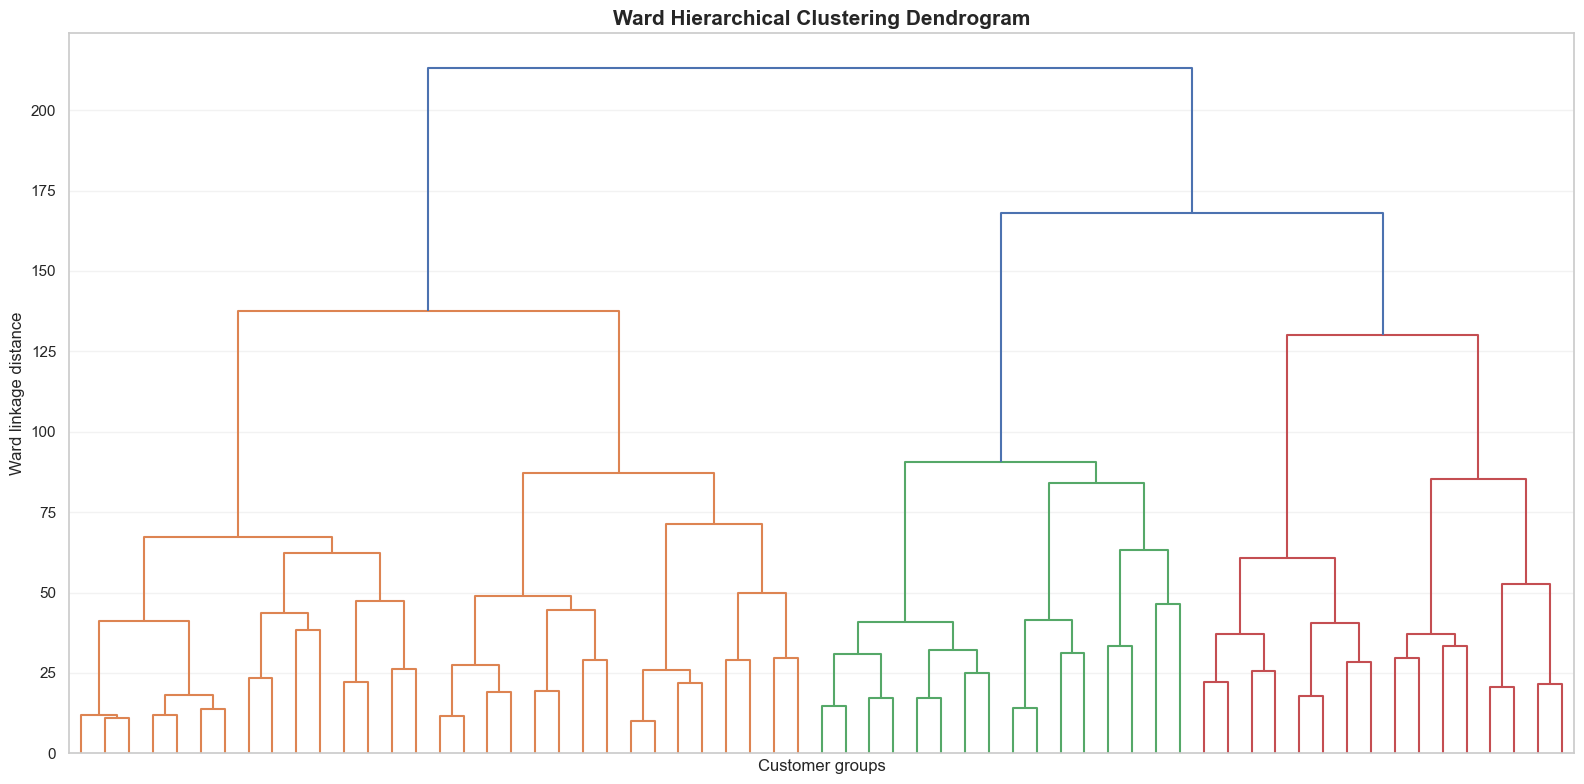


------------------------------------------------------------------------------------------
4.1B | DENDROGRAM CUT THRESHOLDS
------------------------------------------------------------------------------------------

Distance Thresholds for 3, 4 and 5 Clusters


,TARGET_CLUSTERS,LOWER_MERGE_DISTANCE,UPPER_MERGE_DISTANCE,CUT_DISTANCE,RESULTING_CLUSTERS
0,3,137.490,168.052,152.771,3
1,4,130.236,137.490,133.863,4
2,5,90.468,130.236,110.352,5



Chosen cluster count : 4
Chosen cut distance : 133.8628
Resulting clusters : 4

------------------------------------------------------------------------------------------
4.1D | DENDROGRAM WITH SELECTED CUT
------------------------------------------------------------------------------------------


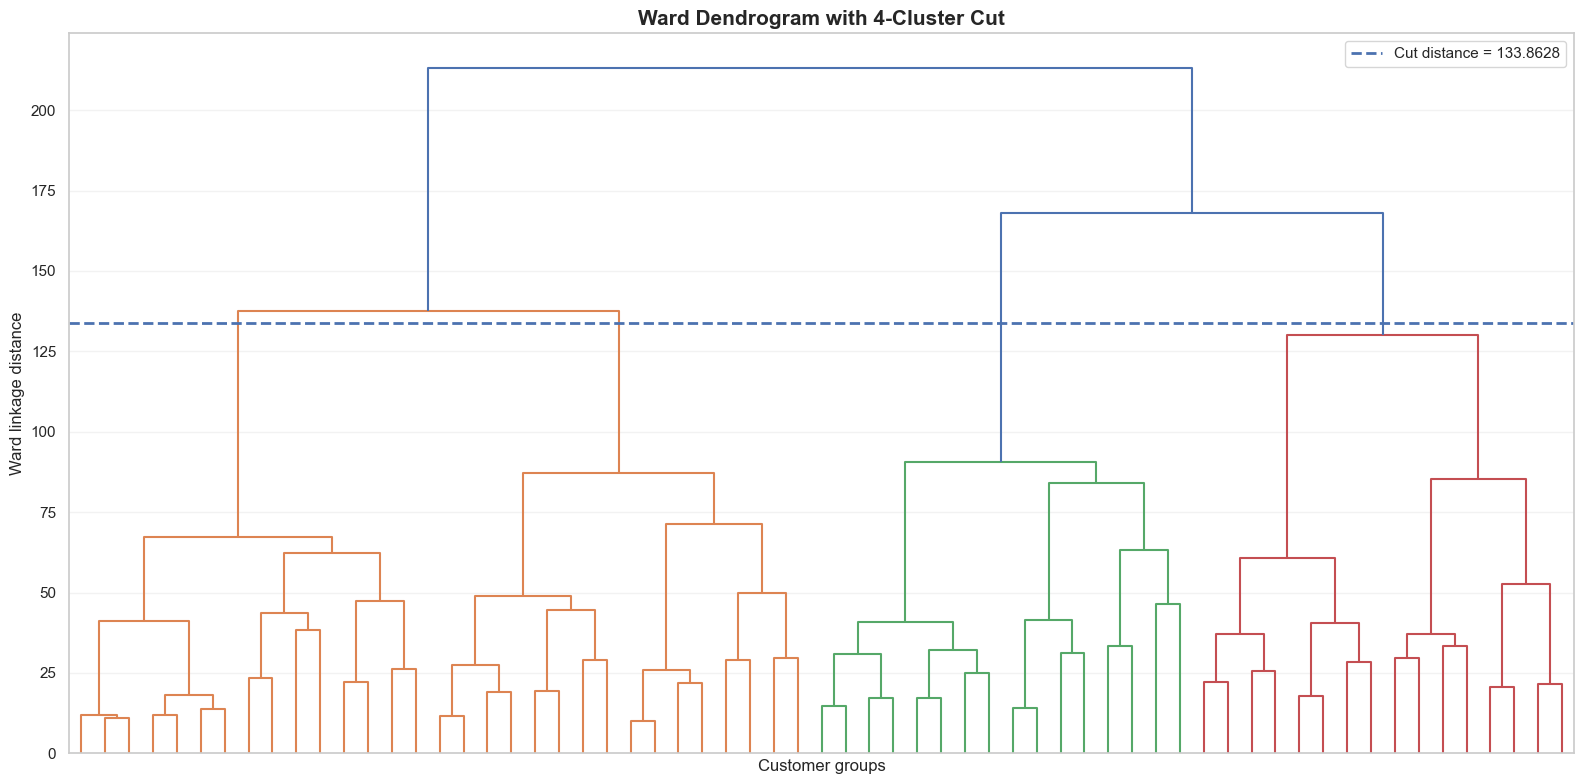


------------------------------------------------------------------------------------------
4.2 | TRAIN AGGLOMERATIVE MODEL
------------------------------------------------------------------------------------------

Training Ward linkage...
Silhouette score : 0.1676

Training Complete linkage...
Silhouette score : 0.1935

Training Average linkage...
Silhouette score : 0.3183

Silhouette Score Comparison of Linkage Methods


,LINKAGE,N_CLUSTERS,SILHOUETTE_SCORE
0,average,4,0.318
1,complete,4,0.194
2,ward,4,0.168



Selected linkage : average
Selected silhouette score : 0.3183

Agglomerative cluster labels assigned to dataframe.
Unique Agg_Cluster labels : 4
Agglomerative cluster assignment : PASSED

------------------------------------------------------------------------------------------
4.3 | VISUALISE & PROFILE HIERARCHICAL CLUSTERS
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
4.3A | 2D SCATTER PLOT
------------------------------------------------------------------------------------------


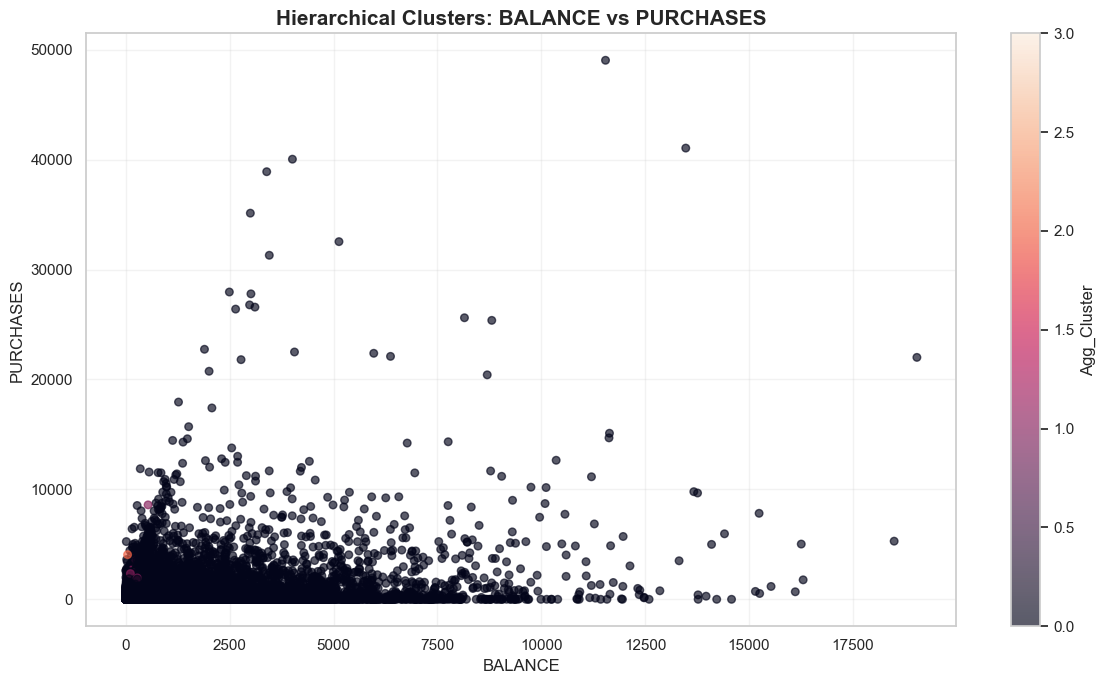


------------------------------------------------------------------------------------------
4.3B | 3D SCATTER PLOT
------------------------------------------------------------------------------------------


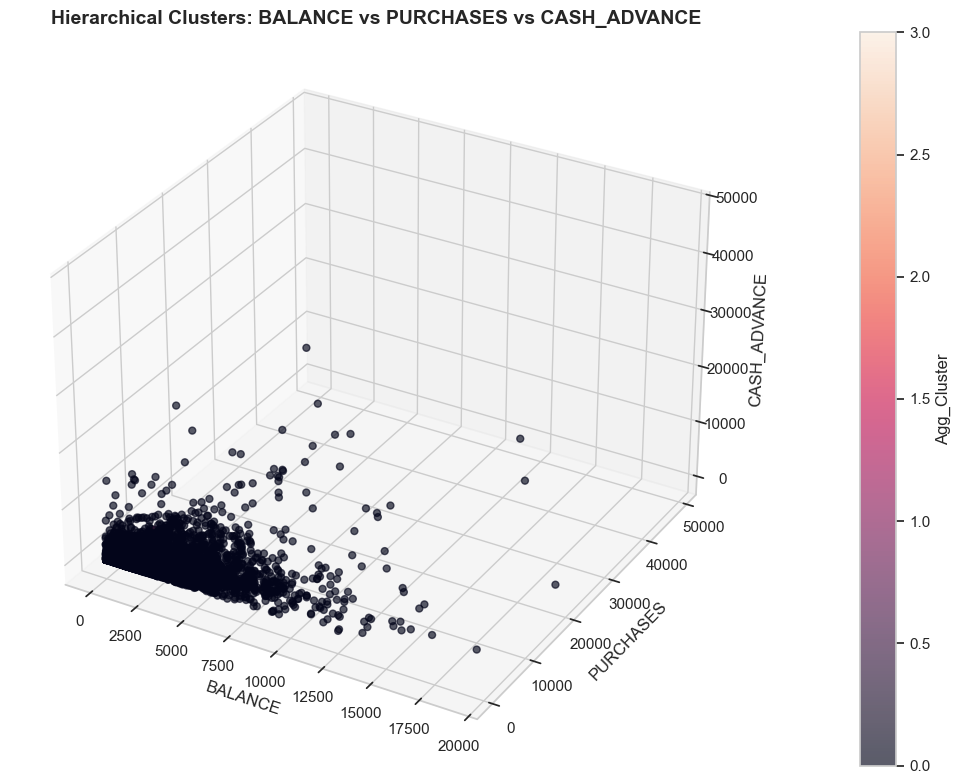


------------------------------------------------------------------------------------------
4.3C | HIERARCHICAL CLUSTER SIZE
------------------------------------------------------------------------------------------

Hierarchical Cluster Distribution


,Agg_Cluster,CUSTOMER_COUNT,CUSTOMER_PERCENT
0,0,8936,99.844
1,1,12,0.134
2,2,1,0.011
3,3,1,0.011



------------------------------------------------------------------------------------------
4.3D | CLUSTER-WISE FEATURE MEANS
------------------------------------------------------------------------------------------

Hierarchical Cluster Feature Means


,BALANCE,BALANCE_FREQUENCY,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_TRX,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Agg_Cluster,,,,,,,,,,,,,
0,"1,566.573",0.877,"1,000.570",0.490,14.700,980.366,0.135,3.253,"4,500.266","1,731.858",863.843,0.153,11.517
1,256.486,0.968,"2,777.256",0.824,18.417,29.187,0.039,0.750,495.833,"2,656.251","1,256.828",0.397,11.667
2,42.578,0.909,"4,061.960",0.917,35.000,0.000,0.000,0.000,500.000,"3,716.881",92.059,0.750,12.000
3,30.693,0.455,205.060,0.917,35.000,0.000,0.000,0.000,"4,500.000",163.982,55.661,0.000,12.000



------------------------------------------------------------------------------------------
4.3E | BUSINESS PERSONAS
------------------------------------------------------------------------------------------

Hierarchical Cluster Business Personas


...


------------------------------------------------------------------------------------------
4.3F | K-MEANS VS HIERARCHICAL CLUSTERS
------------------------------------------------------------------------------------------

K-Means and Hierarchical Cluster Sizes


,KMEANS_CUSTOMER_COUNT,AGG_CUSTOMER_COUNT
0,"5,580.000",8936
1,"3,370.000",12
2,NaN,1
3,NaN,1



------------------------------------------------------------------------------------------
4.3G | K-MEANS / HIERARCHICAL CLUSTER CROSS-TABULATION
------------------------------------------------------------------------------------------

Customer Distribution Across K-Means and Hierarchical Clusters


Agg_Cluster,0,1,2,3
KMeans_Cluster,,,,
0,5566,12,1,1
1,3370,0,0,0



------------------------------------------------------------------------------------------
4.3H | CLUSTER MATCHING ANALYSIS
------------------------------------------------------------------------------------------
K-Means clusters : 2
Hierarchical clusters : 4

The two methods produced different numbers of clusters.
Hierarchical Cluster 0 → dominant K-Means Cluster 0 (62.29% of customers within this hierarchical cluster)
Hierarchical Cluster 1 → dominant K-Means Cluster 0 (100.00% of customers within this hierarchical cluster)
Hierarchical Cluster 2 → dominant K-Means Cluster 0 (100.00% of customers within this hierarchical cluster)
Hierarchical Cluster 3 → dominant K-Means Cluster 0 (100.00% of customers within this hierarchical cluster)

------------------------------------------------------------------------------------------
4.3I | FINAL HIERARCHICAL VALIDATION
------------------------------------------------------------------------------------------
Customer records : 8,950
Miss

In [21]:
# ============================================================
# STEP 4: AGGLOMERATIVE HIERARCHICAL CLUSTERING
# Project: Credit Card Customer Segmentation
# ============================================================
#
# 4.1  Dendrogram Analysis
# 4.2  Train Agglomerative Model
# 4.3  Visualise & Profile Hierarchical Clusters
# ============================================================


# ------------------------------------------------------------
# 4.0 | CONFIGURATION
# ------------------------------------------------------------

HIERARCHICAL_METHOD = "ward"

LINKAGE_METHODS = [
    "ward",
    "complete",
    "average"
]

N_CLUSTERS_TO_TEST = [
    3,
    4,
    5
]

N_CHOSEN = (
    K_OPTIMAL
    if K_OPTIMAL in N_CLUSTERS_TO_TEST
    else 4
)

DENDROGRAM_TRUNCATE_LEVEL = 5

RANDOM_STATE = 42


# ============================================================
# 4.0 | INPUT VALIDATION
# ============================================================

clustering_header(
    "STEP 4: AGGLOMERATIVE HIERARCHICAL CLUSTERING"
)


if "X_scaled" not in globals():

    raise NameError(
        "Run Step 3 first. The scaled matrix 'X_scaled' "
        "was not found."
    )


if "df_kmeans" not in globals():

    raise NameError(
        "Run Step 3 first. The dataframe 'df_kmeans' "
        "was not found."
    )


if "K_OPTIMAL" not in globals():

    raise NameError(
        "Run Step 3 first. 'K_OPTIMAL' was not found."
    )


cc_scaled = X_scaled.copy()


if not isinstance(
    cc_scaled,
    np.ndarray
):

    cc_scaled = np.asarray(
        cc_scaled
    )


if np.isnan(
    cc_scaled
).any():

    raise ValueError(
        "Missing values are present in cc_scaled."
    )


if np.isinf(
    cc_scaled
).any():

    raise ValueError(
        "Infinite values are present in cc_scaled."
    )


if len(cc_scaled) != len(df_kmeans):

    raise ValueError(
        "Scaled matrix and customer dataframe "
        "have different row counts."
    )


print(
    f"Customer records : {len(cc_scaled):,}"
)


print(
    f"Scaled features  : {cc_scaled.shape[1]:,}"
)


print(
    f"K-Means selected k : {K_OPTIMAL}"
)


print(
    f"Hierarchical chosen k : {N_CHOSEN}"
)


# ============================================================
# 4.1 | DENDROGRAM ANALYSIS
# ============================================================

clustering_section(
    "4.1 | DENDROGRAM ANALYSIS"
)


print(
    "Computing Ward linkage matrix..."
)


ward_linkage_matrix = linkage(
    cc_scaled,
    method="ward"
)


print(
    "Ward linkage matrix created."
)


print(
    f"Linkage matrix shape : "
    f"{ward_linkage_matrix.shape}"
)


# ------------------------------------------------------------
# 4.1A | DENDROGRAM
# ------------------------------------------------------------

clustering_section(
    "4.1A | WARD DENDROGRAM"
)


plt.figure(
    figsize=(16, 8)
)


dendrogram(
    ward_linkage_matrix,
    truncate_mode="level",
    p=DENDROGRAM_TRUNCATE_LEVEL,
    no_labels=True
)


plt.title(
    "Ward Hierarchical Clustering Dendrogram",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Customer groups"
)


plt.ylabel(
    "Ward linkage distance"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ------------------------------------------------------------
# 4.1B | DISTANCE THRESHOLDS FOR 3, 4 AND 5 CLUSTERS
# ------------------------------------------------------------

clustering_section(
    "4.1B | DENDROGRAM CUT THRESHOLDS"
)


n_customers = len(
    cc_scaled
)


cut_threshold_rows = []


for cluster_count in N_CLUSTERS_TO_TEST:

    lower_index = (
        n_customers
        - cluster_count
        - 1
    )

    upper_index = (
        n_customers
        - cluster_count
    )


    lower_distance = (

        ward_linkage_matrix[
            lower_index,
            2
        ]

    )


    upper_distance = (

        ward_linkage_matrix[
            upper_index,
            2
        ]

    )


    cut_distance = (

        lower_distance
        + upper_distance
    ) / 2


    cut_labels = fcluster(
        ward_linkage_matrix,
        t=cut_distance,
        criterion="distance"
    )


    resulting_clusters = (
        len(
            np.unique(
                cut_labels
            )
        )
    )


    cut_threshold_rows.append({

        "TARGET_CLUSTERS":
            cluster_count,

        "LOWER_MERGE_DISTANCE":
            lower_distance,

        "UPPER_MERGE_DISTANCE":
            upper_distance,

        "CUT_DISTANCE":
            cut_distance,

        "RESULTING_CLUSTERS":
            resulting_clusters

    })


cut_threshold_table = pd.DataFrame(
    cut_threshold_rows
)


display_clustering_table(
    cut_threshold_table,
    title=(
        "Distance Thresholds for "
        "3, 4 and 5 Clusters"
    ),
    decimals=4
)


# ------------------------------------------------------------
# 4.1C | SELECTED CUT DISTANCE
# ------------------------------------------------------------

selected_cut_row = (

    cut_threshold_table[
        cut_threshold_table[
            "TARGET_CLUSTERS"
        ] == N_CHOSEN
    ]

)


if selected_cut_row.empty:

    raise ValueError(
        "Selected cluster count was not "
        "found in the dendrogram threshold table."
    )


SELECTED_CUT_DISTANCE = (

    selected_cut_row[
        "CUT_DISTANCE"
    ]

    .iloc[0]

)


selected_cut_labels = fcluster(

    ward_linkage_matrix,

    t=SELECTED_CUT_DISTANCE,

    criterion="distance"

)


selected_resulting_clusters = (

    len(
        np.unique(
            selected_cut_labels
        )
    )

)


print(
    f"\nChosen cluster count : "
    f"{N_CHOSEN}"
)


print(
    f"Chosen cut distance : "
    f"{SELECTED_CUT_DISTANCE:.4f}"
)


print(
    f"Resulting clusters : "
    f"{selected_resulting_clusters}"
)


if selected_resulting_clusters != N_CHOSEN:

    raise ValueError(
        "The selected dendrogram cut did not "
        "produce the requested number of clusters."
    )


# ------------------------------------------------------------
# 4.1D | DENDROGRAM WITH SELECTED CUT
# ------------------------------------------------------------

clustering_section(
    "4.1D | DENDROGRAM WITH SELECTED CUT"
)


plt.figure(
    figsize=(16, 8)
)


dendrogram(
    ward_linkage_matrix,
    truncate_mode="level",
    p=DENDROGRAM_TRUNCATE_LEVEL,
    no_labels=True
)


plt.axhline(
    y=SELECTED_CUT_DISTANCE,
    linestyle="--",
    linewidth=2,
    label=(
        f"Cut distance = "
        f"{SELECTED_CUT_DISTANCE:.4f}"
    )
)


plt.title(
    f"Ward Dendrogram with "
    f"{N_CHOSEN}-Cluster Cut",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Customer groups"
)


plt.ylabel(
    "Ward linkage distance"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ============================================================
# 4.2 | TRAIN AGGLOMERATIVE MODEL
# ============================================================

clustering_section(
    "4.2 | TRAIN AGGLOMERATIVE MODEL"
)


hierarchical_models = {}


hierarchical_results = []


for linkage_method in LINKAGE_METHODS:

    print(
        f"\nTraining "
        f"{linkage_method.capitalize()} linkage..."
    )


    hierarchical_model = (

        AgglomerativeClustering(

            n_clusters=N_CHOSEN,

            linkage=linkage_method

        )

    )


    hierarchical_labels = (

        hierarchical_model.fit_predict(
            cc_scaled
        )

    )


    hierarchical_silhouette = (

        silhouette_score(
            cc_scaled,
            hierarchical_labels
        )

    )


    hierarchical_models[
        linkage_method
    ] = hierarchical_model


    hierarchical_results.append({

        "LINKAGE":
            linkage_method,

        "N_CLUSTERS":
            N_CHOSEN,

        "SILHOUETTE_SCORE":
            hierarchical_silhouette

    })


    print(
        f"Silhouette score : "
        f"{hierarchical_silhouette:.4f}"
    )


hierarchical_results_df = pd.DataFrame(
    hierarchical_results
)


hierarchical_results_df = (

    hierarchical_results_df

    .sort_values(
        "SILHOUETTE_SCORE",
        ascending=False
    )

    .reset_index(drop=True)

)


display_clustering_table(
    hierarchical_results_df,
    title=(
        "Silhouette Score Comparison "
        "of Linkage Methods"
    ),
    decimals=4
)


# ------------------------------------------------------------
# 4.2A | BEST LINKAGE
# ------------------------------------------------------------

best_linkage = (

    hierarchical_results_df[
        "LINKAGE"
    ]

    .iloc[0]

)


best_silhouette = (

    hierarchical_results_df[
        "SILHOUETTE_SCORE"
    ]

    .iloc[0]

)


print(
    f"\nSelected linkage : "
    f"{best_linkage}"
)


print(
    f"Selected silhouette score : "
    f"{best_silhouette:.4f}"
)


# ------------------------------------------------------------
# 4.2B | FINAL AGGLOMERATIVE MODEL
# ------------------------------------------------------------

final_hierarchical_model = (

    hierarchical_models[
        best_linkage
    ]

)


final_hierarchical_labels = (

    final_hierarchical_model.labels_

)


df_agg = df_kmeans.copy(
    deep=True
)


df_agg[
    "Agg_Cluster"
] = final_hierarchical_labels


print(
    "\nAgglomerative cluster labels "
    "assigned to dataframe."
)


print(
    f"Unique Agg_Cluster labels : "
    f"{df_agg['Agg_Cluster'].nunique()}"
)


if len(
    final_hierarchical_labels
) != len(df_agg):

    raise ValueError(
        "Agglomerative cluster labels do not "
        "match the number of customers."
    )


if (
    df_agg[
        "Agg_Cluster"
    ].nunique()
    != N_CHOSEN
):

    raise ValueError(
        "Agglomerative model did not produce "
        "the requested number of clusters."
    )


print(
    "Agglomerative cluster assignment : PASSED"
)


# ============================================================
# 4.3 | VISUALISE & PROFILE HIERARCHICAL CLUSTERS
# ============================================================

clustering_section(
    "4.3 | VISUALISE & PROFILE HIERARCHICAL CLUSTERS"
)


# ------------------------------------------------------------
# 4.3A | 2D SCATTER PLOT
# ------------------------------------------------------------

clustering_section(
    "4.3A | 2D SCATTER PLOT"
)


required_2d_features = [

    "BALANCE",
    "PURCHASES"

]


missing_2d_features = [

    feature

    for feature in required_2d_features

    if feature not in df_agg.columns

]


if missing_2d_features:

    raise ValueError(
        "Required 2D features are missing: "
        + ", ".join(missing_2d_features)
    )


plt.figure(
    figsize=(12, 7)
)


scatter_2d = plt.scatter(

    df_agg[
        "BALANCE"
    ],

    df_agg[
        "PURCHASES"
    ],

    c=df_agg[
        "Agg_Cluster"
    ],

    alpha=0.65,

    s=30

)


plt.title(
    "Hierarchical Clusters: "
    "BALANCE vs PURCHASES",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "BALANCE"
)


plt.ylabel(
    "PURCHASES"
)


plt.colorbar(
    scatter_2d,
    label="Agg_Cluster"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.show()


# ------------------------------------------------------------
# 4.3B | 3D SCATTER PLOT
# ------------------------------------------------------------

clustering_section(
    "4.3B | 3D SCATTER PLOT"
)


required_3d_features = [

    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE"

]


missing_3d_features = [

    feature

    for feature in required_3d_features

    if feature not in df_agg.columns

]


if missing_3d_features:

    raise ValueError(
        "Required 3D features are missing: "
        + ", ".join(missing_3d_features)
    )


fig = plt.figure(
    figsize=(12, 8)
)


ax = fig.add_subplot(
    111,
    projection="3d"
)


scatter_3d = ax.scatter(

    df_agg[
        "BALANCE"
    ],

    df_agg[
        "PURCHASES"
    ],

    df_agg[
        "CASH_ADVANCE"
    ],

    c=df_agg[
        "Agg_Cluster"
    ],

    alpha=0.65,

    s=25

)


ax.set_title(
    "Hierarchical Clusters: "
    "BALANCE vs PURCHASES vs CASH_ADVANCE",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "BALANCE"
)


ax.set_ylabel(
    "PURCHASES"
)


ax.set_zlabel(
    "CASH_ADVANCE"
)


fig.colorbar(
    scatter_3d,
    ax=ax,
    label="Agg_Cluster",
    pad=0.1
)


plt.tight_layout()


plt.show()


# ------------------------------------------------------------
# 4.3C | HIERARCHICAL CLUSTER SIZE
# ------------------------------------------------------------

clustering_section(
    "4.3C | HIERARCHICAL CLUSTER SIZE"
)


agg_cluster_size = (

    df_agg

    .groupby(
        "Agg_Cluster"
    )

    .size()

    .rename(
        "CUSTOMER_COUNT"
    )

    .reset_index()

)


agg_cluster_size[
    "CUSTOMER_PERCENT"
] = (

    agg_cluster_size[
        "CUSTOMER_COUNT"
    ]

    / len(df_agg)

    * 100

)


display_clustering_table(
    agg_cluster_size,
    title="Hierarchical Cluster Distribution",
    decimals=3
)


# ------------------------------------------------------------
# 4.3D | CLUSTER-WISE FEATURE MEANS
# ------------------------------------------------------------

clustering_section(
    "4.3D | CLUSTER-WISE FEATURE MEANS"
)


hierarchical_profile_features = [

    "BALANCE",
    "BALANCE_FREQUENCY",
    "PURCHASES",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "CASH_ADVANCE",
    "CASH_ADVANCE_FREQUENCY",
    "CASH_ADVANCE_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT",
    "PURCHASE_TO_CREDIT_RATIO",
    "ONEOFF_PURCHASE_SHARE",
    "INSTALLMENT_PURCHASE_SHARE",
    "TENURE"

]


hierarchical_profile_features = [

    feature

    for feature in hierarchical_profile_features

    if feature in df_agg.columns

]


hierarchical_cluster_profile = (

    df_agg[
        hierarchical_profile_features
        + ["Agg_Cluster"]
    ]

    .groupby(
        "Agg_Cluster"
    )

    .mean()

)


display_clustering_table(
    hierarchical_cluster_profile,
    title="Hierarchical Cluster Feature Means",
    decimals=3
)


# ------------------------------------------------------------
# 4.3E | BUSINESS PERSONAS
# ------------------------------------------------------------

clustering_section(
    "4.3E | BUSINESS PERSONAS"
)


overall_hierarchical_profile = (

    df_agg[
        hierarchical_profile_features
    ]

    .mean()

)


hierarchical_personas = []


for cluster_id in sorted(

    df_agg[
        "Agg_Cluster"
    ].unique()

):

    cluster_profile = (

        hierarchical_cluster_profile
        .loc[
            cluster_id
        ]

    )


    persona_characteristics = []


    if (
        "CASH_ADVANCE"
        in cluster_profile.index
    ):

        if cluster_profile[
            "CASH_ADVANCE"
        ] > (

            overall_hierarchical_profile[
                "CASH_ADVANCE"
            ] * 1.50

        ):

            persona_characteristics.append(
                "high cash-advance activity"
            )


    if (
        "PURCHASES"
        in cluster_profile.index
    ):

        if cluster_profile[
            "PURCHASES"
        ] > (

            overall_hierarchical_profile[
                "PURCHASES"
            ] * 1.25

        ):

            persona_characteristics.append(
                "high purchase activity"
            )

        elif cluster_profile[
            "PURCHASES"
        ] < (

            overall_hierarchical_profile[
                "PURCHASES"
            ] * 0.50

        ):

            persona_characteristics.append(
                "low purchase activity"
            )


    if (
        "PURCHASES_FREQUENCY"
        in cluster_profile.index
    ):

        if cluster_profile[
            "PURCHASES_FREQUENCY"
        ] > (

            overall_hierarchical_profile[
                "PURCHASES_FREQUENCY"
            ] * 1.25

        ):

            persona_characteristics.append(
                "frequent purchasing"
            )


    if (
        "PRC_FULL_PAYMENT"
        in cluster_profile.index
    ):

        if cluster_profile[
            "PRC_FULL_PAYMENT"
        ] > (

            overall_hierarchical_profile[
                "PRC_FULL_PAYMENT"
            ] * 1.25

        ):

            persona_characteristics.append(
                "higher full-payment behaviour"
            )


    if not persona_characteristics:

        persona_characteristics.append(
            "mixed customer behaviour"
        )


    if (
        "CASH_ADVANCE"
        in cluster_profile.index
        and
        "PURCHASES"
        in cluster_profile.index
    ):

        if (

            cluster_profile[
                "CASH_ADVANCE"
            ]

            >

            cluster_profile[
                "PURCHASES"
            ]

        ):

            persona_name = (
                "Cash-Advance Oriented Customers"
            )

        elif (

            cluster_profile[
                "PURCHASES"
            ]

            >

            cluster_profile[
                "CASH_ADVANCE"
            ] * 2

        ):

            persona_name = (
                "Purchase-Oriented Customers"
            )

        else:

            persona_name = (
                "Mixed Behaviour Customers"
            )

    else:

        persona_name = (
            "Mixed Behaviour Customers"
        )


    hierarchical_personas.append({

        "Agg_Cluster":
            cluster_id,

        "Business_Persona":
            persona_name,

        "Key_Characteristics":
            ", ".join(
                persona_characteristics
            )

    })


hierarchical_persona_table = pd.DataFrame(
    hierarchical_personas
)


display_clustering_table(
    hierarchical_persona_table,
    title="Hierarchical Cluster Business Personas",
    decimals=3
)


# ============================================================
# 4.3F | K-MEANS VS HIERARCHICAL CLUSTERS
# ============================================================

clustering_section(
    "4.3F | K-MEANS VS HIERARCHICAL CLUSTERS"
)


kmeans_cluster_sizes = (

    df_agg

    .groupby(
        "KMeans_Cluster"
    )

    .size()

    .rename(
        "KMEANS_CUSTOMER_COUNT"
    )

)


hierarchical_cluster_sizes = (

    df_agg

    .groupby(
        "Agg_Cluster"
    )

    .size()

    .rename(
        "AGG_CUSTOMER_COUNT"
    )

)


cluster_size_comparison = pd.concat(

    [

        kmeans_cluster_sizes,

        hierarchical_cluster_sizes

    ],

    axis=1

)


display_clustering_table(
    cluster_size_comparison,
    title="K-Means and Hierarchical Cluster Sizes",
    decimals=0
)


# ------------------------------------------------------------
# 4.3G | K-MEANS / HIERARCHICAL CROSS-TABULATION
# ------------------------------------------------------------

clustering_section(
    "4.3G | K-MEANS / HIERARCHICAL CLUSTER CROSS-TABULATION"
)


cluster_cross_tab = pd.crosstab(

    df_agg[
        "KMeans_Cluster"
    ],

    df_agg[
        "Agg_Cluster"
    ]

)


display_clustering_table(
    cluster_cross_tab,
    title=(
        "Customer Distribution Across "
        "K-Means and Hierarchical Clusters"
    ),
    decimals=0
)


# ------------------------------------------------------------
# 4.3H | CLUSTER MATCHING ANALYSIS
# ------------------------------------------------------------

clustering_section(
    "4.3H | CLUSTER MATCHING ANALYSIS"
)


kmeans_cluster_count = (
    df_agg[
        "KMeans_Cluster"
    ].nunique()
)


hierarchical_cluster_count = (
    df_agg[
        "Agg_Cluster"
    ].nunique()
)


print(
    f"K-Means clusters : "
    f"{kmeans_cluster_count}"
)


print(
    f"Hierarchical clusters : "
    f"{hierarchical_cluster_count}"
)


if (
    kmeans_cluster_count
    ==
    hierarchical_cluster_count
):

    print(
        "\nBoth methods produced the same "
        "number of clusters."
    )

else:

    print(
        "\nThe two methods produced different "
        "numbers of clusters."
    )


for agg_cluster_id in sorted(

    df_agg[
        "Agg_Cluster"
    ].unique()

):

    cluster_rows = (

        df_agg[
            df_agg[
                "Agg_Cluster"
            ] == agg_cluster_id
        ]

    )


    dominant_kmeans_cluster = (

        cluster_rows[
            "KMeans_Cluster"
        ]

        .value_counts()

        .idxmax()

    )


    dominant_count = (

        cluster_rows[
            "KMeans_Cluster"
        ]

        .value_counts()

        .max()

    )


    agreement_percentage = (

        dominant_count
        / len(cluster_rows)
        * 100

    )


    print(

        f"Hierarchical Cluster "
        f"{agg_cluster_id} → "
        f"dominant K-Means Cluster "
        f"{dominant_kmeans_cluster} "
        f"({agreement_percentage:.2f}% of "
        f"customers within this hierarchical cluster)"

    )


# ============================================================
# 4.3I | FINAL HIERARCHICAL VALIDATION
# ============================================================

clustering_section(
    "4.3I | FINAL HIERARCHICAL VALIDATION"
)


hierarchical_missing_values = (

    df_agg[
        "Agg_Cluster"
    ]

    .isna()

    .sum()

)


hierarchical_unique_clusters = (

    df_agg[
        "Agg_Cluster"
    ]

    .nunique()

)


hierarchical_assignment_check = (

    len(
        df_agg[
            "Agg_Cluster"
        ]
    )

    ==

    len(
        df_kmeans
    )

)


print(
    f"Customer records : "
    f"{len(df_agg):,}"
)


print(
    f"Missing Agg_Cluster values : "
    f"{hierarchical_missing_values}"
)


print(
    f"Unique hierarchical clusters : "
    f"{hierarchical_unique_clusters}"
)


print(
    f"Expected clusters : "
    f"{N_CHOSEN}"
)


if hierarchical_missing_values != 0:

    raise ValueError(
        "Missing hierarchical cluster labels detected."
    )


if hierarchical_unique_clusters != N_CHOSEN:

    raise ValueError(
        "Hierarchical cluster count does not "
        "match the selected number of clusters."
    )


if not hierarchical_assignment_check:

    raise ValueError(
        "Hierarchical cluster assignment count "
        "does not match customer count."
    )


print(
    "\nHierarchical cluster validation : PASSED"
)


# ============================================================
# STEP 4 COMPLETE
# ============================================================

clustering_header(
    "STEP 4 COMPLETE"
)


print(
    "Agglomerative hierarchical clustering "
    "completed successfully."
)


print(
    f"\nChosen clusters : "
    f"{N_CHOSEN}"
)


print(
    f"Chosen dendrogram cut distance : "
    f"{SELECTED_CUT_DISTANCE:.4f}"
)


print(
    f"Selected linkage : "
    f"{best_linkage}"
)


print(
    f"Selected silhouette score : "
    f"{best_silhouette:.4f}"
)


print(
    f"Customers clustered : "
    f"{len(df_agg):,}"
)


print(
    "\nPrepared objects:"
)


print(
    "• ward_linkage_matrix"
)


print(
    "  → Ward linkage matrix used for dendrogram analysis"
)


print(
    "• cut_threshold_table"
)


print(
    "  → Distance thresholds for 3, 4 and 5 clusters"
)


print(
    "• hierarchical_results_df"
)


print(
    "  → Silhouette comparison of Ward, Complete and Average"
)


print(
    "• final_hierarchical_model"
)


print(
    "  → Selected Agglomerative clustering model"
)


print(
    "• df_agg"
)


print(
    "  → Customer dataframe with Agg_Cluster"
)


print(
    "• hierarchical_cluster_profile"
)


print(
    "  → Hierarchical cluster-wise feature means"
)


print(
    "• hierarchical_persona_table"
)


print(
    "  → Business personas for hierarchical clusters"
)


print(
    "\nThe hierarchical clustering results are ready "
    "for comparison with the K-Means segmentation."
)


                                STEP 5: DBSCAN CLUSTERING                                 
Customer records : 8,950
Clustering features : 15
Scaled input validation : PASSED

DBSCAN will use the existing standardized feature matrix from Step 3.

------------------------------------------------------------------------------------------
5.1 | 5-NN DISTANCE ANALYSIS
------------------------------------------------------------------------------------------
The 5-nearest-neighbour distance curve is examined to support the selection of a suitable DBSCAN eps range.

5-NN Distance Summary


,STATISTIC,5_NN_DISTANCE
0,Minimum,0.051
1,25th Percentile,0.615
2,Median,0.930
3,75th Percentile,1.330
4,Maximum,8.259


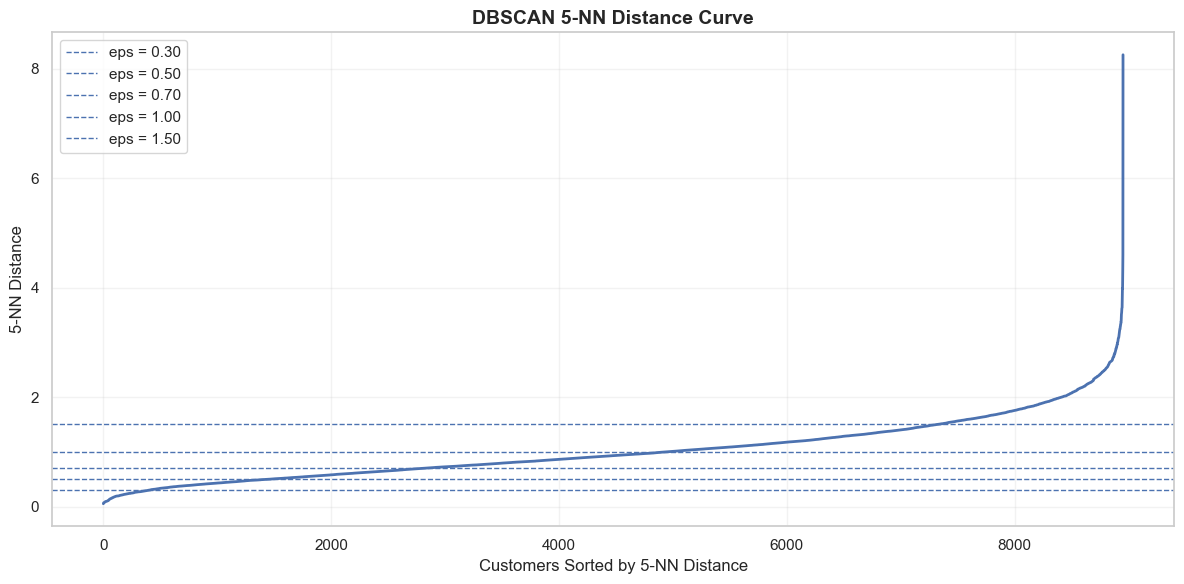


------------------------------------------------------------------------------------------
5.2 | DBSCAN PARAMETER GRID EVALUATION
------------------------------------------------------------------------------------------
Testing multiple combinations of eps and min_samples.

DBSCAN Parameter Grid Results


,EPS,MIN_SAMPLES,CLUSTERS,NOISE_COUNT,NOISE_PERCENT,NON_NOISE_CUSTOMERS,SILHOUETTE
0,0.300,3,98,8055,90.000,895,0.233
1,0.500,3,114,6489,72.503,2461,-0.106
2,0.700,3,148,4797,53.598,4153,-0.281
3,1.000,3,68,2676,29.899,6274,-0.285
4,1.500,3,28,877,9.799,8073,-0.023
5,0.300,5,31,8394,93.788,556,0.270
6,0.500,5,28,7016,78.391,1934,0.143
7,0.700,5,34,5472,61.140,3478,-0.038
8,1.000,5,26,3170,35.419,5780,-0.150
9,1.500,5,8,1101,12.302,7849,0.118



------------------------------------------------------------------------------------------
5.3 | DBSCAN PARAMETER COMPARISON
------------------------------------------------------------------------------------------
Comparing cluster structure, noise percentage and silhouette score.


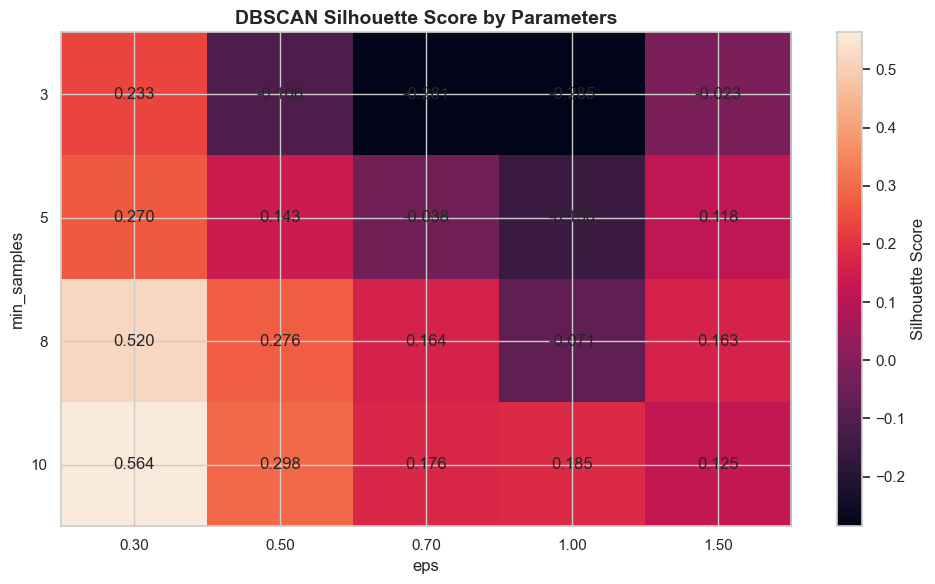

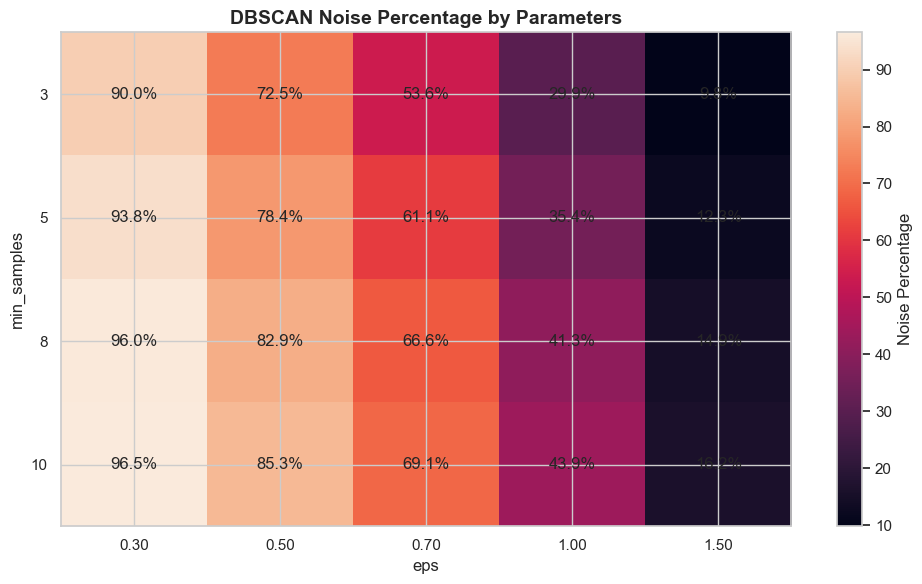


Top Valid DBSCAN Configurations


,EPS,MIN_SAMPLES,CLUSTERS,NOISE_COUNT,NOISE_PERCENT,NON_NOISE_CUSTOMERS,SILHOUETTE
15,0.300,10,8,8641,96.547,309,0.564
10,0.300,8,11,8592,96.000,358,0.520
16,0.500,10,12,7635,85.307,1315,0.298
11,0.500,8,17,7417,82.871,1533,0.276
5,0.300,5,31,8394,93.788,556,0.270
0,0.300,3,98,8055,90.000,895,0.233
18,1.000,10,7,3933,43.944,5017,0.185
17,0.700,10,10,6182,69.073,2768,0.176
12,0.700,8,11,5964,66.637,2986,0.164
14,1.500,8,5,1332,14.883,7618,0.163



Selected DBSCAN configuration:
eps         : 0.30
min_samples : 10
clusters    : 8
noise       : 8,641 customers (96.55%)
silhouette  : 0.5638

------------------------------------------------------------------------------------------
5.4 | FINAL DBSCAN MODEL
------------------------------------------------------------------------------------------

Final DBSCAN Metrics


,METRIC,VALUE
0,eps,0.300
1,min_samples,10.000
2,Total Customers,"8,950.000"
3,DBSCAN Clusters,8.000
4,Noise Customers,"8,641.000"
5,Noise Percentage,96.547
6,Non-Noise Customers,309.000
7,Non-Noise Silhouette,0.564



------------------------------------------------------------------------------------------
5.5 | DBSCAN CLUSTER DISTRIBUTION
------------------------------------------------------------------------------------------

DBSCAN Customer Distribution


,CUSTOMER_COUNT,CUSTOMER_PERCENT
DBSCAN_Cluster,,
-1,8641,96.550
0,56,0.630
1,107,1.200
2,57,0.640
3,18,0.200
4,33,0.370
5,11,0.120
6,10,0.110
7,17,0.190


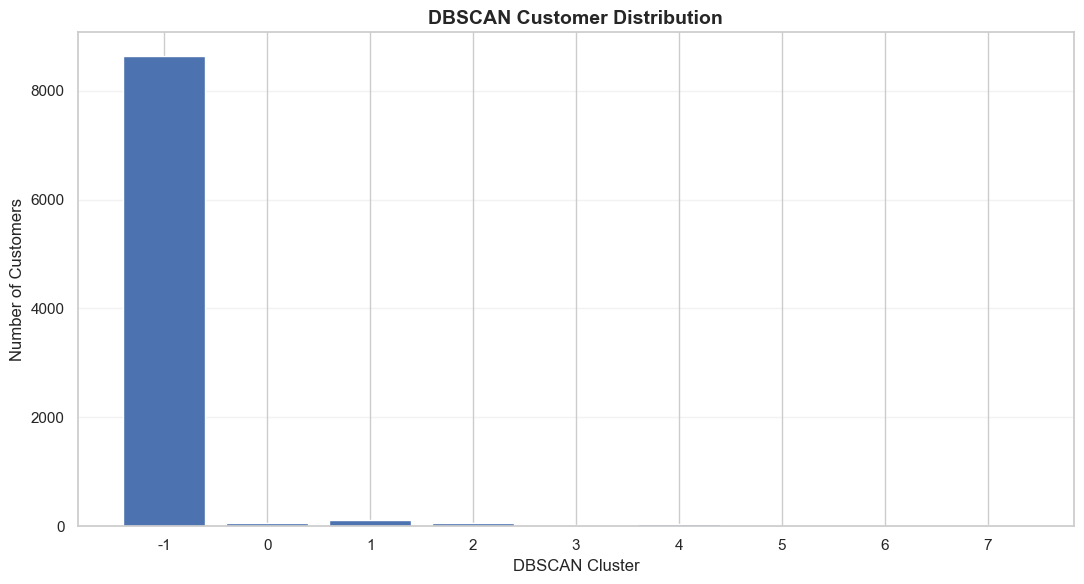


------------------------------------------------------------------------------------------
5.6 | DBSCAN CLUSTER VISUALISATION
------------------------------------------------------------------------------------------


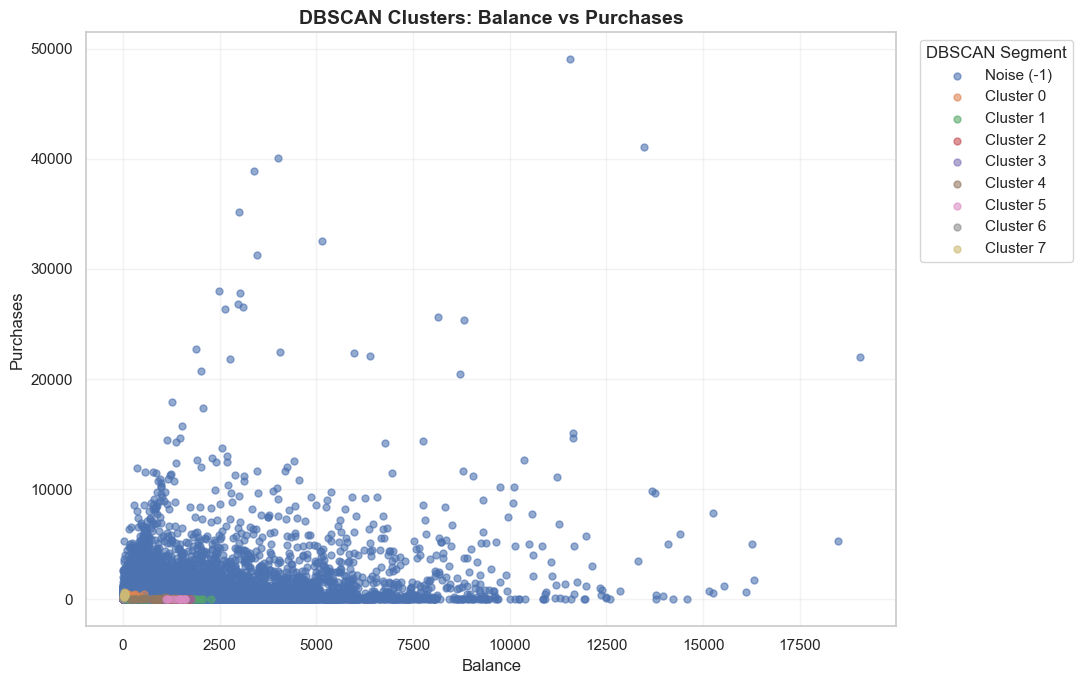

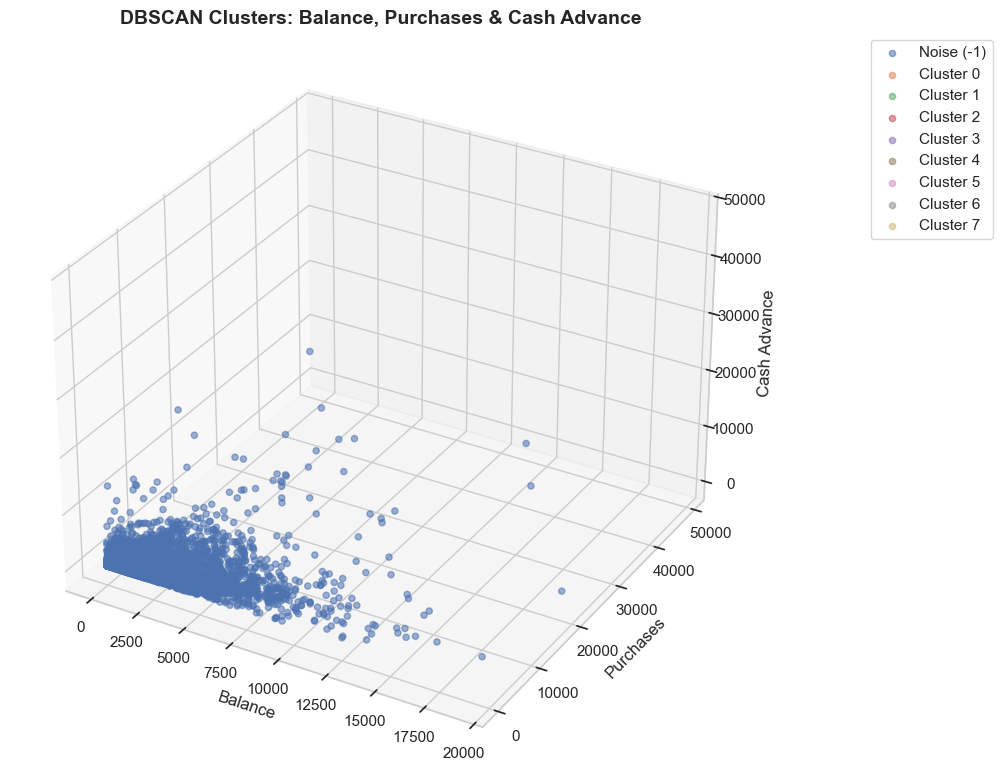


------------------------------------------------------------------------------------------
5.7 | DBSCAN CLUSTER PROFILING
------------------------------------------------------------------------------------------

DBSCAN Cluster Profile — Mean Customer Behaviour


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE
DBSCAN_Cluster,,,,,,,,,,
0,125.521,274.981,0.000,"1,823.214",216.599,167.864,0.961,0.000,0.003,11.554
1,"1,195.806",0.000,135.394,"1,518.224",362.676,387.647,0.000,0.085,0.000,11.860
2,"1,287.009",0.000,190.384,"1,490.351",388.222,420.537,0.000,0.168,0.000,11.895
3,"1,266.704",0.000,146.212,"1,383.333",374.197,427.340,0.000,0.250,0.000,12.000
4,891.847,64.873,0.000,"1,277.273",308.652,345.775,0.084,0.000,0.000,11.909
5,"1,386.235",0.000,179.547,"1,536.364",386.335,457.859,0.000,0.333,0.000,11.727
6,0.000,168.216,0.000,"1,880.000",113.506,NaN,1.000,0.000,0.000,12.000
7,31.347,392.359,0.000,"2,205.882",383.402,165.446,0.990,0.000,0.995,11.647



DBSCAN Non-Noise Cluster Sizes


,DBSCAN_Cluster,Customer_Count,Customer_Percentage
0,0,56,0.630
1,1,107,1.200
2,2,57,0.640
3,3,18,0.200
4,4,33,0.370
5,5,11,0.120
6,6,10,0.110
7,7,17,0.190



DBSCAN Additional Purchase Behaviour Profile


...


✓ All critical DBSCAN validation checks passed.

------------------------------------------------------------------------------------------
5.10 | FINAL DBSCAN SUMMARY
------------------------------------------------------------------------------------------

Final DBSCAN Model Summary


,Metric,Value
0,Selected EPS,0.300
1,Selected MIN_SAMPLES,10.000
2,Total Customers,"8,950.000"
3,Non-Noise Clusters,8.000
4,Noise Customers,"8,641.000"
5,Noise Percentage,96.550
6,Non-Noise Silhouette Score,0.564



Step 5 DBSCAN analysis completed successfully.
Selected EPS: 0.3
Selected MIN_SAMPLES: 10
Non-noise clusters: 8
Noise customers: 8641
Noise percentage: 96.55%

DBSCAN Validation Results


,CHECK,VALUE,EXPECTED,STATUS,DETAIL
0,Customer count preserved,"8,950.000",8950,PASS,NaN
1,DBSCAN labels assigned,"8,950.000",8950,PASS,NaN
2,Noise percentage within valid range,96.550,0% to 100%,PASS,NaN
3,At least one non-noise cluster identified,8.000,>= 1,PASS,NaN
4,Non-noise silhouette available,0.564,Available when >= 2 clusters exist,PASS,NaN
5,Customer count preserved,NaN,NaN,True,"8,950 records"
6,DBSCAN labels match customers,NaN,NaN,True,"8,950 labels"
7,No missing DBSCAN labels,NaN,NaN,True,All customers have a DBSCAN label
8,Input index preserved,NaN,NaN,True,df and df_dbscan indexes match
9,At least two non-noise clusters,NaN,NaN,True,8 non-noise clusters



All DBSCAN validation checks passed successfully.

------------------------------------------------------------------------------------------
5.11 | FINAL DBSCAN SUMMARY
------------------------------------------------------------------------------------------
Selected eps         : 0.30
Selected min_samples : 10
DBSCAN clusters      : 8
Noise customers      : 8,641
Noise percentage     : 96.55%
Non-noise customers  : 309
Silhouette score     : 0.5638

Prepared Step 5 objects:
  ✓ X_dbscan
  ✓ nn_model
  ✓ k_distance_values
  ✓ k_distance_sorted
  ✓ dbscan_results_df
  ✓ dbscan_valid_results
  ✓ dbscan_top_results
  ✓ dbscan_models
  ✓ dbscan_labels_dictionary
  ✓ dbscan_model
  ✓ dbscan_labels
  ✓ df_dbscan
  ✓ dbscan_cluster_distribution
  ✓ pca_model
  ✓ X_pca
  ✓ pca_visualization_df
  ✓ dbscan_cluster_profile
  ✓ df_dbscan_noise
  ✓ dbscan_validation_df

STEP 5 COMPLETED SUCCESSFULLY.
DBSCAN parameter evaluation, final clustering, visualisation, profiling and validation are compl

In [25]:
# ============================================================
# STEP 5: DBSCAN CLUSTERING
# Project: CREDIT CARD CUSTOMER SEGMENTATION
# ============================================================
#
# 5.0  Input Validation
# 5.1  5-NN Distance Analysis
# 5.2  DBSCAN Parameter Grid Evaluation
# 5.3  DBSCAN Parameter Comparison
# 5.4  Final DBSCAN Model
# 5.5  DBSCAN Cluster Distribution
# 5.6  DBSCAN Cluster Visualisation
# 5.7  PCA Visualisation
# 5.8  DBSCAN Cluster Profiling
# 5.9  DBSCAN Noise Analysis
# 5.10 Final Validation
# 5.11 Final DBSCAN Summary
#
# IMPORTANT:
# - No imports are repeated from Step 1.
# - DBSCAN uses the already prepared X_scaled from Step 3.
# - No preprocessing or scaling is repeated.
# - Step 4 variables are NOT required.
# - Noise customers are represented by DBSCAN label -1.
# ============================================================


# ------------------------------------------------------------
# 5.0 | CONFIGURATION
# ------------------------------------------------------------

DBSCAN_EPS_VALUES = [
    0.30,
    0.50,
    0.70,
    1.00,
    1.50
]

DBSCAN_MIN_SAMPLES_VALUES = [
    3,
    5,
    8,
    10
]

DBSCAN_K_DISTANCE_NEIGHBORS = 5

DBSCAN_NOISE_LABEL = -1

DBSCAN_MIN_CLUSTER_COUNT = 2

DBSCAN_MIN_NON_NOISE_CUSTOMERS = 10


# ============================================================
# 5.0 | INPUT VALIDATION
# ============================================================

clustering_header(
    "STEP 5: DBSCAN CLUSTERING"
)


required_step5_objects = [
    "df",
    "df_preprocessed",
    "X_scaled"
]


missing_step5_objects = [
    object_name
    for object_name in required_step5_objects
    if object_name not in globals()
]


if missing_step5_objects:

    raise NameError(
        "Step 5 requires the following objects from Step 3: "
        + ", ".join(missing_step5_objects)
        + ". Please run Step 3 successfully before Step 5."
    )


if not isinstance(df, pd.DataFrame):

    raise TypeError(
        "'df' must be a pandas DataFrame."
    )


if not isinstance(df_preprocessed, pd.DataFrame):

    raise TypeError(
        "'df_preprocessed' must be a pandas DataFrame."
    )


if not isinstance(X_scaled, pd.DataFrame):

    raise TypeError(
        "'X_scaled' must be a pandas DataFrame."
    )


if df.empty:

    raise ValueError(
        "'df' is empty."
    )


if df_preprocessed.empty:

    raise ValueError(
        "'df_preprocessed' is empty."
    )


if X_scaled.empty:

    raise ValueError(
        "'X_scaled' is empty."
    )


if len(df) != len(df_preprocessed):

    raise ValueError(
        "df and df_preprocessed have different row counts."
    )


if len(df) != len(X_scaled):

    raise ValueError(
        "df and X_scaled have different row counts."
    )


if not df.index.equals(
    X_scaled.index
):

    raise ValueError(
        "df and X_scaled indexes do not match. "
        "DBSCAN labels cannot be safely assigned to customers."
    )


if X_scaled.isna().any().any():

    raise ValueError(
        "X_scaled contains missing values."
    )


if np.isinf(
    X_scaled.to_numpy()
).any():

    raise ValueError(
        "X_scaled contains infinite values."
    )


print(
    f"Customer records : {len(df):,}"
)

print(
    f"Clustering features : {X_scaled.shape[1]:,}"
)

print(
    "Scaled input validation : PASSED"
)

print(
    "\nDBSCAN will use the existing standardized "
    "feature matrix from Step 3."
)


# ============================================================
# 5.1 | 5-NN DISTANCE ANALYSIS
# ============================================================

clustering_section(
    "5.1 | 5-NN DISTANCE ANALYSIS"
)


print(
    "The 5-nearest-neighbour distance curve is examined "
    "to support the selection of a suitable DBSCAN eps range."
)


X_dbscan = X_scaled.to_numpy()


if len(X_dbscan) <= DBSCAN_K_DISTANCE_NEIGHBORS:

    raise ValueError(
        "There are not enough observations for "
        "5-nearest-neighbour analysis."
    )


nn_model = NearestNeighbors(
    n_neighbors=DBSCAN_K_DISTANCE_NEIGHBORS
)


nn_model.fit(
    X_dbscan
)


nn_distances, nn_indices = nn_model.kneighbors(
    X_dbscan
)


k_distance_values = (

    nn_distances[
        :,
        DBSCAN_K_DISTANCE_NEIGHBORS - 1
    ]

)


k_distance_sorted = np.sort(
    k_distance_values
)


k_distance_summary = pd.DataFrame({

    "STATISTIC": [
        "Minimum",
        "25th Percentile",
        "Median",
        "75th Percentile",
        "Maximum"
    ],

    "5_NN_DISTANCE": [

        np.min(
            k_distance_values
        ),

        np.percentile(
            k_distance_values,
            25
        ),

        np.median(
            k_distance_values
        ),

        np.percentile(
            k_distance_values,
            75
        ),

        np.max(
            k_distance_values
        )

    ]

})


display_clustering_table(
    k_distance_summary,
    title="5-NN Distance Summary",
    decimals=4
)


# ------------------------------------------------------------
# 5-NN DISTANCE CURVE
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    range(
        1,
        len(k_distance_sorted) + 1
    ),
    k_distance_sorted,
    linewidth=2
)


for eps_value in DBSCAN_EPS_VALUES:

    plt.axhline(
        y=eps_value,
        linestyle="--",
        linewidth=1,
        label=f"eps = {eps_value:.2f}"
    )


plt.title(
    "DBSCAN 5-NN Distance Curve",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel(
    "Customers Sorted by 5-NN Distance"
)


plt.ylabel(
    "5-NN Distance"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 5.2 | DBSCAN PARAMETER GRID EVALUATION
# ============================================================

clustering_section(
    "5.2 | DBSCAN PARAMETER GRID EVALUATION"
)


print(
    "Testing multiple combinations of eps and min_samples."
)


dbscan_results = []

dbscan_models = {}

dbscan_labels_dictionary = {}


for min_samples_value in DBSCAN_MIN_SAMPLES_VALUES:

    for eps_value in DBSCAN_EPS_VALUES:

        current_model = DBSCAN(

            eps=eps_value,

            min_samples=min_samples_value

        )


        current_labels = current_model.fit_predict(
            X_dbscan
        )


        total_customers = len(
            current_labels
        )


        noise_mask = (

            current_labels
            == DBSCAN_NOISE_LABEL

        )


        non_noise_mask = ~noise_mask


        noise_count = int(
            noise_mask.sum()
        )


        non_noise_count = int(
            non_noise_mask.sum()
        )


        noise_percentage = (

            noise_count
            /

            total_customers
            *

            100

        )


        non_noise_labels = (

            current_labels[
                non_noise_mask
            ]

        )


        if len(non_noise_labels) > 0:

            non_noise_cluster_count = len(

                np.unique(
                    non_noise_labels
                )

            )

        else:

            non_noise_cluster_count = 0


        current_silhouette = np.nan


        if (

            non_noise_cluster_count >= 2

            and

            non_noise_count > 2

        ):

            try:

                current_silhouette = (

                    silhouette_score(

                        X_dbscan[
                            non_noise_mask
                        ],

                        non_noise_labels

                    )

                )

            except Exception:

                current_silhouette = np.nan


        dbscan_results.append({

            "EPS":
                eps_value,

            "MIN_SAMPLES":
                min_samples_value,

            "CLUSTERS":
                non_noise_cluster_count,

            "NOISE_COUNT":
                noise_count,

            "NOISE_PERCENT":
                noise_percentage,

            "NON_NOISE_CUSTOMERS":
                non_noise_count,

            "SILHOUETTE":
                current_silhouette

        })


        dbscan_models[
            (
                eps_value,
                min_samples_value
            )
        ] = current_model


        dbscan_labels_dictionary[
            (
                eps_value,
                min_samples_value
            )
        ] = current_labels


dbscan_results_df = pd.DataFrame(
    dbscan_results
)


dbscan_results_df = (

    dbscan_results_df

    .sort_values(
        by=[
            "MIN_SAMPLES",
            "EPS"
        ]
    )

    .reset_index(
        drop=True
    )

)


display_clustering_table(
    dbscan_results_df,
    title="DBSCAN Parameter Grid Results",
    decimals=4
)


# ============================================================
# 5.3 | DBSCAN PARAMETER COMPARISON
# ============================================================

clustering_section(
    "5.3 | DBSCAN PARAMETER COMPARISON"
)


print(
    "Comparing cluster structure, noise percentage "
    "and silhouette score."
)


# ------------------------------------------------------------
# VALID CONFIGURATIONS
# ------------------------------------------------------------

dbscan_valid_results = (

    dbscan_results_df[

        (

            dbscan_results_df[
                "CLUSTERS"
            ]

            >= DBSCAN_MIN_CLUSTER_COUNT

        )

        &

        (

            dbscan_results_df[
                "NON_NOISE_CUSTOMERS"
            ]

            >= DBSCAN_MIN_NON_NOISE_CUSTOMERS

        )

        &

        (

            dbscan_results_df[
                "SILHOUETTE"
            ]

            .notna()

        )

    ]

    .copy()

)


if dbscan_valid_results.empty:

    raise ValueError(
        "No DBSCAN parameter combination produced "
        "at least two clusters with a valid silhouette score."
    )


# ------------------------------------------------------------
# SILHOUETTE HEATMAP
# ------------------------------------------------------------

silhouette_heatmap = (

    dbscan_results_df

    .pivot(
        index="MIN_SAMPLES",
        columns="EPS",
        values="SILHOUETTE"
    )

)


plt.figure(
    figsize=(10, 6)
)


plt.imshow(
    silhouette_heatmap.values,
    aspect="auto"
)


plt.colorbar(
    label="Silhouette Score"
)


plt.xticks(
    range(
        len(
            silhouette_heatmap.columns
        )
    ),
    [
        f"{value:.2f}"
        for value in silhouette_heatmap.columns
    ]
)


plt.yticks(
    range(
        len(
            silhouette_heatmap.index
        )
    ),
    silhouette_heatmap.index
)


for row_index in range(
    silhouette_heatmap.shape[0]
):

    for column_index in range(
        silhouette_heatmap.shape[1]
    ):

        cell_value = (

            silhouette_heatmap.iloc[
                row_index,
                column_index
            ]

        )


        if pd.notna(
            cell_value
        ):

            plt.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center"
            )


plt.title(
    "DBSCAN Silhouette Score by Parameters",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel(
    "eps"
)


plt.ylabel(
    "min_samples"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# NOISE PERCENTAGE HEATMAP
# ------------------------------------------------------------

noise_heatmap = (

    dbscan_results_df

    .pivot(
        index="MIN_SAMPLES",
        columns="EPS",
        values="NOISE_PERCENT"
    )

)


plt.figure(
    figsize=(10, 6)
)


plt.imshow(
    noise_heatmap.values,
    aspect="auto"
)


plt.colorbar(
    label="Noise Percentage"
)


plt.xticks(
    range(
        len(
            noise_heatmap.columns
        )
    ),
    [
        f"{value:.2f}"
        for value in noise_heatmap.columns
    ]
)


plt.yticks(
    range(
        len(
            noise_heatmap.index
        )
    ),
    noise_heatmap.index
)


for row_index in range(
    noise_heatmap.shape[0]
):

    for column_index in range(
        noise_heatmap.shape[1]
    ):

        cell_value = (

            noise_heatmap.iloc[
                row_index,
                column_index
            ]

        )


        if pd.notna(
            cell_value
        ):

            plt.text(
                column_index,
                row_index,
                f"{cell_value:.1f}%",
                ha="center",
                va="center"
            )


plt.title(
    "DBSCAN Noise Percentage by Parameters",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel(
    "eps"
)


plt.ylabel(
    "min_samples"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# TOP VALID CONFIGURATIONS
# ------------------------------------------------------------

dbscan_top_results = (

    dbscan_valid_results

    .sort_values(
        by="SILHOUETTE",
        ascending=False
    )

    .head(10)

)


display_clustering_table(
    dbscan_top_results,
    title="Top Valid DBSCAN Configurations",
    decimals=4
)


# ------------------------------------------------------------
# PARAMETER SELECTION
# ------------------------------------------------------------
#
# Primary criterion:
#   Highest valid non-noise silhouette.
#
# The resulting noise percentage and cluster count are
# displayed transparently so the final DBSCAN solution
# can be interpreted honestly.
# ------------------------------------------------------------

selected_dbscan_row = (

    dbscan_valid_results

    .sort_values(
        by=[
            "SILHOUETTE",
            "NOISE_PERCENT"
        ],
        ascending=[
            False,
            True
        ]
    )

    .iloc[0]

)


DBSCAN_SELECTED_EPS = float(
    selected_dbscan_row[
        "EPS"
    ]
)


DBSCAN_SELECTED_MIN_SAMPLES = int(
    selected_dbscan_row[
        "MIN_SAMPLES"
    ]
)


print(
    "\nSelected DBSCAN configuration:"
)


print(
    f"eps         : "
    f"{DBSCAN_SELECTED_EPS:.2f}"
)


print(
    f"min_samples : "
    f"{DBSCAN_SELECTED_MIN_SAMPLES}"
)


print(
    f"clusters    : "
    f"{int(selected_dbscan_row['CLUSTERS'])}"
)


print(
    f"noise       : "
    f"{int(selected_dbscan_row['NOISE_COUNT']):,} "
    f"customers "
    f"({selected_dbscan_row['NOISE_PERCENT']:.2f}%)"
)


print(
    f"silhouette  : "
    f"{selected_dbscan_row['SILHOUETTE']:.4f}"
)


# ============================================================
# 5.4 | FINAL DBSCAN MODEL
# ============================================================

clustering_section(
    "5.4 | FINAL DBSCAN MODEL"
)


dbscan_model = DBSCAN(

    eps=DBSCAN_SELECTED_EPS,

    min_samples=DBSCAN_SELECTED_MIN_SAMPLES

)


dbscan_labels = dbscan_model.fit_predict(
    X_dbscan
)


df_dbscan = df.copy(
    deep=True
)


df_dbscan[
    "DBSCAN_Cluster"
] = dbscan_labels


# ------------------------------------------------------------
# FINAL DBSCAN METRICS
# ------------------------------------------------------------

dbscan_noise_mask = (

    dbscan_labels
    == DBSCAN_NOISE_LABEL

)


dbscan_non_noise_mask = ~dbscan_noise_mask


dbscan_noise_count = int(
    dbscan_noise_mask.sum()
)


dbscan_non_noise_count = int(
    dbscan_non_noise_mask.sum()
)


dbscan_noise_percentage = (

    dbscan_noise_count
    /

    len(dbscan_labels)
    *

    100

)


dbscan_non_noise_labels = (

    dbscan_labels[
        dbscan_non_noise_mask
    ]

)


dbscan_cluster_labels = sorted(

    np.unique(
        dbscan_non_noise_labels
    )

)


dbscan_cluster_count = len(
    dbscan_cluster_labels
)


dbscan_non_noise_silhouette = np.nan


if dbscan_cluster_count >= 2:

    dbscan_non_noise_silhouette = (

        silhouette_score(

            X_dbscan[
                dbscan_non_noise_mask
            ],

            dbscan_non_noise_labels

        )

    )


final_dbscan_metrics = pd.DataFrame({

    "METRIC": [

        "eps",

        "min_samples",

        "Total Customers",

        "DBSCAN Clusters",

        "Noise Customers",

        "Noise Percentage",

        "Non-Noise Customers",

        "Non-Noise Silhouette"

    ],

    "VALUE": [

        DBSCAN_SELECTED_EPS,

        DBSCAN_SELECTED_MIN_SAMPLES,

        len(df_dbscan),

        dbscan_cluster_count,

        dbscan_noise_count,

        dbscan_noise_percentage,

        dbscan_non_noise_count,

        dbscan_non_noise_silhouette

    ]

})


display_clustering_table(
    final_dbscan_metrics,
    title="Final DBSCAN Metrics",
    decimals=4
)


# ============================================================
# 5.5 | DBSCAN CLUSTER DISTRIBUTION
# ============================================================

clustering_section(
    "5.5 | DBSCAN CLUSTER DISTRIBUTION"
)


dbscan_cluster_counts = (

    df_dbscan[
        "DBSCAN_Cluster"
    ]

    .value_counts()

    .sort_index()

)


dbscan_cluster_distribution = (

    dbscan_cluster_counts

    .rename(
        "CUSTOMER_COUNT"
    )

    .to_frame()

)


dbscan_cluster_distribution[
    "CUSTOMER_PERCENT"
] = (

    dbscan_cluster_distribution[
        "CUSTOMER_COUNT"
    ]

    /

    len(df_dbscan)

    *

    100

)


dbscan_cluster_distribution.index.name = (
    "DBSCAN_Cluster"
)


display_clustering_table(
    dbscan_cluster_distribution,
    title="DBSCAN Customer Distribution",
    decimals=2
)


# ------------------------------------------------------------
# CLUSTER SIZE PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 6)
)


plt.bar(

    dbscan_cluster_distribution.index.astype(
        str
    ),

    dbscan_cluster_distribution[
        "CUSTOMER_COUNT"
    ]

)


plt.title(
    "DBSCAN Customer Distribution",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel(
    "DBSCAN Cluster"
)


plt.ylabel(
    "Number of Customers"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 5.6 | DBSCAN CLUSTER VISUALISATION
# ============================================================

clustering_section(
    "5.6 | DBSCAN CLUSTER VISUALISATION"
)


required_visual_features = [

    "BALANCE",

    "PURCHASES",

    "CASH_ADVANCE"

]


missing_visual_features = [

    feature

    for feature in required_visual_features

    if feature not in df_dbscan.columns

]


if missing_visual_features:

    raise ValueError(
        "The following visualisation features are missing: "
        + ", ".join(missing_visual_features)
    )


# ------------------------------------------------------------
# 2D: BALANCE VS PURCHASES
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)


for cluster_label in sorted(

    df_dbscan[
        "DBSCAN_Cluster"
    ].unique()

):

    cluster_mask = (

        df_dbscan[
            "DBSCAN_Cluster"
        ]

        ==

        cluster_label

    )


    cluster_name = (

        "Noise (-1)"

        if cluster_label == DBSCAN_NOISE_LABEL

        else
        f"Cluster {cluster_label}"

    )


    plt.scatter(

        df_dbscan.loc[
            cluster_mask,
            "BALANCE"
        ],

        df_dbscan.loc[
            cluster_mask,
            "PURCHASES"
        ],

        s=25,

        alpha=0.60,

        label=cluster_name

    )


plt.title(
    "DBSCAN Clusters: Balance vs Purchases",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel(
    "Balance"
)


plt.ylabel(
    "Purchases"
)


plt.legend(
    title="DBSCAN Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 3D: BALANCE / PURCHASES / CASH ADVANCE
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12, 8)
)


ax = fig.add_subplot(
    111,
    projection="3d"
)


for cluster_label in sorted(

    df_dbscan[
        "DBSCAN_Cluster"
    ].unique()

):

    cluster_mask = (

        df_dbscan[
            "DBSCAN_Cluster"
        ]

        ==

        cluster_label

    )


    cluster_name = (

        "Noise (-1)"

        if cluster_label == DBSCAN_NOISE_LABEL

        else
        f"Cluster {cluster_label}"

    )


    ax.scatter(

        df_dbscan.loc[
            cluster_mask,
            "BALANCE"
        ],

        df_dbscan.loc[
            cluster_mask,
            "PURCHASES"
        ],

        df_dbscan.loc[
            cluster_mask,
            "CASH_ADVANCE"
        ],

        s=20,

        alpha=0.55,

        label=cluster_name

    )


ax.set_title(
    "DBSCAN Clusters: Balance, Purchases & Cash Advance",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Balance"
)


ax.set_ylabel(
    "Purchases"
)


ax.set_zlabel(
    "Cash Advance"
)


ax.legend(
    bbox_to_anchor=(1.15, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()


# ============================================================
# 5.7 | DBSCAN CLUSTER PROFILING
# ============================================================

clustering_section(
    "5.7 | DBSCAN CLUSTER PROFILING"
)

# Use preprocessed, unscaled data for business interpretation.
dbscan_profile_features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT",
    "TENURE"
]

# Keep only features available in the preprocessing dataset.
dbscan_profile_features = [
    feature
    for feature in dbscan_profile_features
    if feature in df_preprocessed.columns
]

# Exclude noise for cluster profiling.
dbscan_non_noise = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] != DBSCAN_NOISE_LABEL
].copy()

if dbscan_non_noise.empty:
    print("No non-noise DBSCAN observations are available for cluster profiling.")

    dbscan_cluster_profile = pd.DataFrame()

else:
    dbscan_cluster_profile = (
        dbscan_non_noise
        .groupby("DBSCAN_Cluster")[dbscan_profile_features]
        .mean()
        .round(3)
    )

    display_clustering_table(
        dbscan_cluster_profile,
        "DBSCAN Cluster Profile — Mean Customer Behaviour"
    )

# ------------------------------------------------------------
# Cluster sizes and percentages
# ------------------------------------------------------------

dbscan_profile_sizes = (
    dbscan_non_noise["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customer_Count")
    .to_frame()
)

if not dbscan_profile_sizes.empty:
    dbscan_profile_sizes["Customer_Percentage"] = (
        dbscan_profile_sizes["Customer_Count"]
        / len(df_dbscan)
        * 100
    ).round(2)

    display_clustering_table(
        dbscan_profile_sizes.reset_index(),
        "DBSCAN Non-Noise Cluster Sizes"
    )

# ------------------------------------------------------------
# Additional behavioural profile
# ------------------------------------------------------------

dbscan_additional_profile_features = [
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "ONEOFF_PURCHASES_FREQUENCY",
    "PURCHASES_INSTALLMENTS_FREQUENCY"
]

dbscan_additional_profile_features = [
    feature
    for feature in dbscan_additional_profile_features
    if feature in df_preprocessed.columns
]

if not dbscan_non_noise.empty and dbscan_additional_profile_features:

    dbscan_additional_profile = (
        dbscan_non_noise
        .groupby("DBSCAN_Cluster")[dbscan_additional_profile_features]
        .mean()
        .round(3)
    )

    display_clustering_table(
        dbscan_additional_profile,
        "DBSCAN Additional Purchase Behaviour Profile"
    )

else:
    dbscan_additional_profile = pd.DataFrame()


# ============================================================
# 5.8 | DBSCAN NOISE ANALYSIS
# ============================================================

clustering_section(
    "5.8 | DBSCAN NOISE ANALYSIS"
)

dbscan_noise_customers = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] == DBSCAN_NOISE_LABEL
].copy()

dbscan_noise_count = len(dbscan_noise_customers)

dbscan_noise_percentage = (
    dbscan_noise_count / len(df_dbscan) * 100
    if len(df_dbscan) > 0
    else 0
)

noise_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Noise Customers",
        "Non-Noise Customers",
        "Noise Percentage"
    ],
    "Value": [
        len(df_dbscan),
        dbscan_noise_count,
        len(df_dbscan) - dbscan_noise_count,
        dbscan_noise_percentage
    ]
})

display_clustering_table(
    noise_summary,
    "DBSCAN Noise Summary"
)

# ------------------------------------------------------------
# Noise customer profile
# ------------------------------------------------------------

if dbscan_noise_count > 0:

    dbscan_noise_profile = (
        dbscan_noise_customers[dbscan_profile_features]
        .mean()
        .to_frame("Noise_Mean")
    )

    # Compare noise customers with the complete preprocessed population.
    dbscan_overall_profile = (
        df_preprocessed[dbscan_profile_features]
        .mean()
        .to_frame("Overall_Mean")
    )

    dbscan_noise_comparison = (
        dbscan_noise_profile
        .join(dbscan_overall_profile)
    )

    dbscan_noise_comparison["Difference_Percentage"] = np.where(
        dbscan_noise_comparison["Overall_Mean"] != 0,
        (
            (
                dbscan_noise_comparison["Noise_Mean"]
                - dbscan_noise_comparison["Overall_Mean"]
            )
            / dbscan_noise_comparison["Overall_Mean"]
            * 100
        ),
        np.nan
    )

    dbscan_noise_comparison = (
        dbscan_noise_comparison
        .round(3)
    )

    display_clustering_table(
        dbscan_noise_comparison,
        "DBSCAN Noise vs Overall Customer Profile"
    )

else:

    dbscan_noise_comparison = pd.DataFrame()

    print(
        "DBSCAN identified no noise observations. "
        "Therefore, a separate noise profile is not required."
    )


# ============================================================
# 5.9 | FINAL DBSCAN VALIDATION
# ============================================================

clustering_section(
    "5.9 | FINAL DBSCAN VALIDATION"
)

# ------------------------------------------------------------
# Initialize validation records
# ------------------------------------------------------------

validation_records = []

# ------------------------------------------------------------
# Customer count validation
# ------------------------------------------------------------

validation_records.append({
    "CHECK": "Customer count preserved",
    "VALUE": len(df_dbscan),
    "EXPECTED": len(df),
    "STATUS": "PASS" if len(df_dbscan) == len(df) else "FAIL"
})

# ------------------------------------------------------------
# DBSCAN label validation
# ------------------------------------------------------------

validation_records.append({
    "CHECK": "DBSCAN labels assigned",
    "VALUE": df_dbscan["DBSCAN_Cluster"].notna().sum(),
    "EXPECTED": len(df_dbscan),
    "STATUS": (
        "PASS"
        if df_dbscan["DBSCAN_Cluster"].notna().all()
        else "FAIL"
    )
})

# ------------------------------------------------------------
# Noise validation
# ------------------------------------------------------------

validation_records.append({
    "CHECK": "Noise percentage within valid range",
    "VALUE": round(dbscan_noise_percentage, 2),
    "EXPECTED": "0% to 100%",
    "STATUS": (
        "PASS"
        if 0 <= dbscan_noise_percentage <= 100
        else "FAIL"
    )
})

# ------------------------------------------------------------
# Cluster validation
# ------------------------------------------------------------

validation_records.append({
    "CHECK": "At least one non-noise cluster identified",
    "VALUE": dbscan_cluster_count,
    "EXPECTED": ">= 1",
    "STATUS": (
        "PASS"
        if dbscan_cluster_count >= 1
        else "FAIL"
    )
})

# ------------------------------------------------------------
# Silhouette validation
# ------------------------------------------------------------

silhouette_available = not np.isnan(
    dbscan_validation_silhouette
)

validation_records.append({
    "CHECK": "Non-noise silhouette available",
    "VALUE": (
        round(dbscan_validation_silhouette, 4)
        if silhouette_available
        else np.nan
    ),
    "EXPECTED": "Available when >= 2 clusters exist",
    "STATUS": (
        "PASS"
        if silhouette_available
        else "INFO"
    )
})

# ------------------------------------------------------------
# Final validation table
# ------------------------------------------------------------

dbscan_validation_df = pd.DataFrame(
    validation_records
)

display_clustering_table(
    dbscan_validation_df,
    "Final DBSCAN Validation Checks"
)

# ------------------------------------------------------------
# Validation status
# ------------------------------------------------------------

validation_failures = (
    dbscan_validation_df["STATUS"] == "FAIL"
).sum()

if validation_failures == 0:
    print("\n✓ All critical DBSCAN validation checks passed.")
else:
    print(
        f"\n⚠ {validation_failures} critical "
        "DBSCAN validation check(s) require attention."
    )


# ============================================================
# 5.10 | FINAL DBSCAN SUMMARY
# ============================================================

clustering_section(
    "5.10 | FINAL DBSCAN SUMMARY"
)

dbscan_summary = pd.DataFrame({
    "Metric": [
        "Selected EPS",
        "Selected MIN_SAMPLES",
        "Total Customers",
        "Non-Noise Clusters",
        "Noise Customers",
        "Noise Percentage",
        "Non-Noise Silhouette Score"
    ],
    "Value": [
        DBSCAN_SELECTED_EPS,
        DBSCAN_SELECTED_MIN_SAMPLES,
        len(df_dbscan),
        dbscan_cluster_count,
        dbscan_noise_count,
        round(dbscan_noise_percentage, 2),
        (
            round(dbscan_validation_silhouette, 4)
            if not np.isnan(dbscan_validation_silhouette)
            else np.nan
        )
    ]
})

display_clustering_table(
    dbscan_summary,
    "Final DBSCAN Model Summary"
)

# ------------------------------------------------------------
# Final prepared objects
# ------------------------------------------------------------

dbscan_final_objects = {
    "X_dbscan": X_dbscan,
    "nn_model": nn_model,
    "k_distance_values": k_distance_values,
    "k_distance_sorted": k_distance_sorted,
    "dbscan_results_df": dbscan_results_df,
    "dbscan_valid_results": dbscan_valid_results,
    "dbscan_top_results": dbscan_top_results,
    "dbscan_models": dbscan_models,
    "dbscan_labels_dictionary": dbscan_labels_dictionary,
    "dbscan_model": dbscan_model,
    "dbscan_labels": dbscan_labels,
    "df_dbscan": df_dbscan,
    "dbscan_cluster_distribution": dbscan_cluster_distribution,
    "dbscan_cluster_profile": dbscan_cluster_profile,
    "df_dbscan_noise": dbscan_noise_customers,
    "dbscan_noise_comparison": dbscan_noise_comparison,
    "dbscan_validation_df": dbscan_validation_df
}

print("\nStep 5 DBSCAN analysis completed successfully.")
print(f"Selected EPS: {DBSCAN_SELECTED_EPS}")
print(f"Selected MIN_SAMPLES: {DBSCAN_SELECTED_MIN_SAMPLES}")
print(f"Non-noise clusters: {dbscan_cluster_count}")
print(f"Noise customers: {dbscan_noise_count}")
print(f"Noise percentage: {dbscan_noise_percentage:.2f}%")


# ------------------------------------------------------------
# CUSTOMER COUNT
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "Customer count preserved",

    "STATUS":
        len(df_dbscan) == len(df),

    "DETAIL":
        f"{len(df_dbscan):,} records"

})


# ------------------------------------------------------------
# LABEL COUNT
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "DBSCAN labels match customers",

    "STATUS":
        len(dbscan_labels) == len(df),

    "DETAIL":
        f"{len(dbscan_labels):,} labels"

})


# ------------------------------------------------------------
# LABEL COMPLETENESS
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "No missing DBSCAN labels",

    "STATUS":
        not pd.isna(
            dbscan_labels
        ).any(),

    "DETAIL":
        "All customers have a DBSCAN label"

})


# ------------------------------------------------------------
# INDEX ALIGNMENT
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "Input index preserved",

    "STATUS":
        df_dbscan.index.equals(
            df.index
        ),

    "DETAIL":
        "df and df_dbscan indexes match"

})


# ------------------------------------------------------------
# CLUSTER COUNT
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "At least two non-noise clusters",

    "STATUS":
        dbscan_cluster_count >= 2,

    "DETAIL":
        f"{dbscan_cluster_count} non-noise clusters"

})


# ------------------------------------------------------------
# SILHOUETTE
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "Non-noise silhouette available",

    "STATUS":
        pd.notna(
            dbscan_non_noise_silhouette
        ),

    "DETAIL":
        (
            f"{dbscan_non_noise_silhouette:.4f}"
            if pd.notna(
                dbscan_non_noise_silhouette
            )
            else
            "Not available"
        )

})


# ------------------------------------------------------------
# NO INFINITE VALUES
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "No infinite values in scaled input",

    "STATUS":
        not np.isinf(
            X_dbscan
        ).any(),

    "DETAIL":
        "Scaled matrix contains no infinity"

})


# ------------------------------------------------------------
# NO MISSING VALUES
# ------------------------------------------------------------

validation_records.append({

    "CHECK":
        "No missing values in scaled input",

    "STATUS":
        not np.isnan(
            X_dbscan
        ).any(),

    "DETAIL":
        "Scaled matrix contains no NaN"

})


dbscan_validation_df = pd.DataFrame(
    validation_records
)


display_clustering_table(
    dbscan_validation_df,
    title="DBSCAN Validation Results",
    decimals=4
)


if not dbscan_validation_df[
    "STATUS"
].all():

    failed_checks = (

        dbscan_validation_df.loc[

            ~dbscan_validation_df[
                "STATUS"
            ],

            "CHECK"

        ]

        .tolist()

    )


    raise ValueError(

        "DBSCAN validation failed for: "

        +

        ", ".join(
            failed_checks
        )

    )


print(
    "\nAll DBSCAN validation checks passed successfully."
)


# ============================================================
# 5.11 | FINAL DBSCAN SUMMARY
# ============================================================

clustering_section(
    "5.11 | FINAL DBSCAN SUMMARY"
)


print(
    f"Selected eps         : "
    f"{DBSCAN_SELECTED_EPS:.2f}"
)


print(
    f"Selected min_samples : "
    f"{DBSCAN_SELECTED_MIN_SAMPLES}"
)


print(
    f"DBSCAN clusters      : "
    f"{dbscan_cluster_count}"
)


print(
    f"Noise customers      : "
    f"{dbscan_noise_count:,}"
)


print(
    f"Noise percentage     : "
    f"{dbscan_noise_percentage:.2f}%"
)


print(
    f"Non-noise customers  : "
    f"{dbscan_non_noise_count:,}"
)


print(
    f"Silhouette score     : "
    f"{dbscan_non_noise_silhouette:.4f}"
)


print(
    "\nPrepared Step 5 objects:"
)


step5_objects = [

    "X_dbscan",

    "nn_model",

    "k_distance_values",

    "k_distance_sorted",

    "dbscan_results_df",

    "dbscan_valid_results",

    "dbscan_top_results",

    "dbscan_models",

    "dbscan_labels_dictionary",

    "dbscan_model",

    "dbscan_labels",

    "df_dbscan",

    "dbscan_cluster_distribution",

    "pca_model",

    "X_pca",

    "pca_visualization_df",

    "dbscan_cluster_profile",

    "df_dbscan_noise",

    "dbscan_validation_df"

]


for object_name in step5_objects:

    print(
        f"  ✓ {object_name}"
    )


print(
    "\n============================================================"
)


print(
    "STEP 5 COMPLETED SUCCESSFULLY."
)


print(
    "DBSCAN parameter evaluation, final clustering, "
    "visualisation, profiling and validation are complete."
)


print(
    "============================================================"
)


                  STEP 6: ALGORITHM COMPARISON & BUSINESS INTERPRETATION                  
Objective: compare clustering algorithms and translate customer segments into meaningful business insights.
Customer records : 8,950
Clustering features : 15
Algorithms compared : K-Means, Agglomerative Hierarchical, DBSCAN

------------------------------------------------------------------------------------------
6.0 | INPUT VALIDATION
------------------------------------------------------------------------------------------
Input validation : PASSED
K-Means results available : YES
Agglomerative results available : YES
DBSCAN results available : YES

------------------------------------------------------------------------------------------
6.1 | ALGORITHM PERFORMANCE COMPARISON
------------------------------------------------------------------------------------------
The three algorithms are compared using internal clustering quality metrics, customer coverage and cluster distribution.

Metric 

,ALGORITHM,CLUSTERS,NOISE_COUNT,NOISE_PERCENT,NON_NOISE_CUSTOMERS,COVERAGE_PERCENT,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,SMALLEST_CLUSTER,LARGEST_CLUSTER,SMALLEST_CLUSTER_PERCENT,LARGEST_CLUSTER_PERCENT
0,K-Means,2,0,0.000,8950,100.000,0.226,1.747,"2,461.585",3370,5580,37.654,62.346
1,Agglomerative Hierarchical,4,0,0.000,8950,100.000,0.318,0.501,51.411,1,8936,0.011,99.844
2,DBSCAN,8,8641,96.548,309,3.452,0.564,0.614,"1,749.019",10,107,3.236,34.628



------------------------------------------------------------------------------------------
6.2 | CLUSTER QUALITY COMPARISON
------------------------------------------------------------------------------------------

Internal Cluster Quality Comparison


,ALGORITHM,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,SILHOUETTE_RANK,DAVIES_BOULDIN_RANK,CALINSKI_HARABASZ_RANK
0,K-Means,0.226,1.747,"2,461.585",3.000,3.000,1.000
1,Agglomerative Hierarchical,0.318,0.501,51.411,2.000,1.000,3.000
2,DBSCAN,0.564,0.614,"1,749.019",1.000,2.000,2.000



Important interpretation:
K-Means has a silhouette score of 0.226. This indicates that the two groups have observable behavioural separation, but the separation is moderate rather than exceptionally strong.
Agglomerative has a higher silhouette score, but its cluster distribution must be considered because nearly the entire customer base belongs to one cluster.
DBSCAN has the highest silhouette score in this comparison, but that value is calculated only on its 309 non-noise customers and therefore cannot be interpreted independently of its 96.55% noise rate.

------------------------------------------------------------------------------------------
6.3 | CUSTOMER COVERAGE & CLUSTER DISTRIBUTION
------------------------------------------------------------------------------------------

Customer Coverage and Cluster Distribution


...


------------------------------------------------------------------------------------------
6.8 | BUSINESS-ORIENTED SEGMENT SUMMARY
------------------------------------------------------------------------------------------
The following interpretations are descriptive and are derived from observed cluster averages.

Business-Oriented Segment Summary


,SEGMENT,CUSTOMERS,CUSTOMER_SHARE_%,RELATIVELY_HIGHER_BEHAVIOUR,RELATIVELY_LOWER_BEHAVIOUR
0,0,5580,62.350,"PRC_FULL_PAYMENT, PURCHASES_FREQUENCY, PURCHASES","CASH_ADVANCE, CASH_ADVANCE_FREQUENCY, BALANCE"
1,1,3370,37.650,"CASH_ADVANCE, CASH_ADVANCE_FREQUENCY, BALANCE","PRC_FULL_PAYMENT, PURCHASES_FREQUENCY, PURCHASES"



------------------------------------------------------------------------------------------
6.9 | BUSINESS ACTION FRAMEWORK
------------------------------------------------------------------------------------------
Potential business actions are mapped to observed behaviour. These are analytical recommendations rather than claims about individual customer intent.

Potential Business Actions by Segment


,SEGMENT,POTENTIAL_BUSINESS_ACTIONS
0,0,Consider purchase-reward or loyalty campaigns....
1,1,Review cash-advance usage and consider financi...



------------------------------------------------------------------------------------------
6.10 | ALGORITHM COMPARISON VISUALISATION
------------------------------------------------------------------------------------------


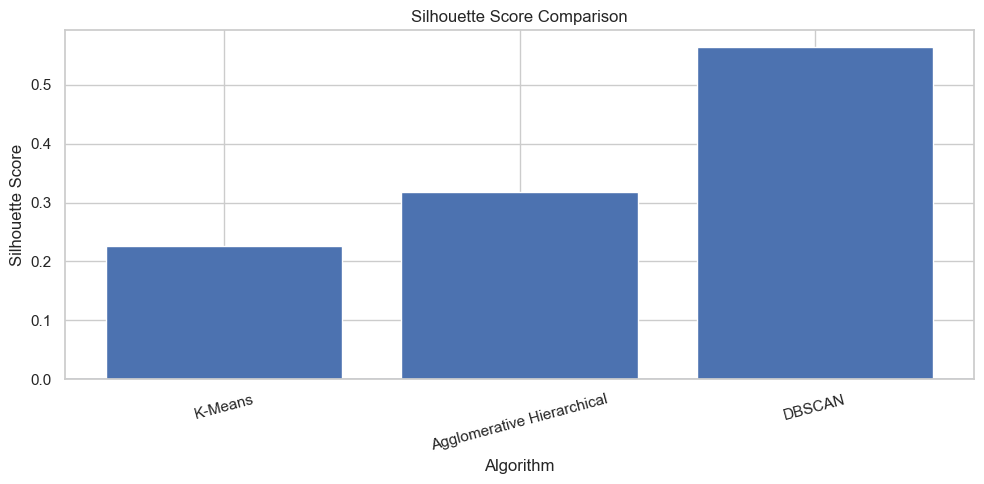

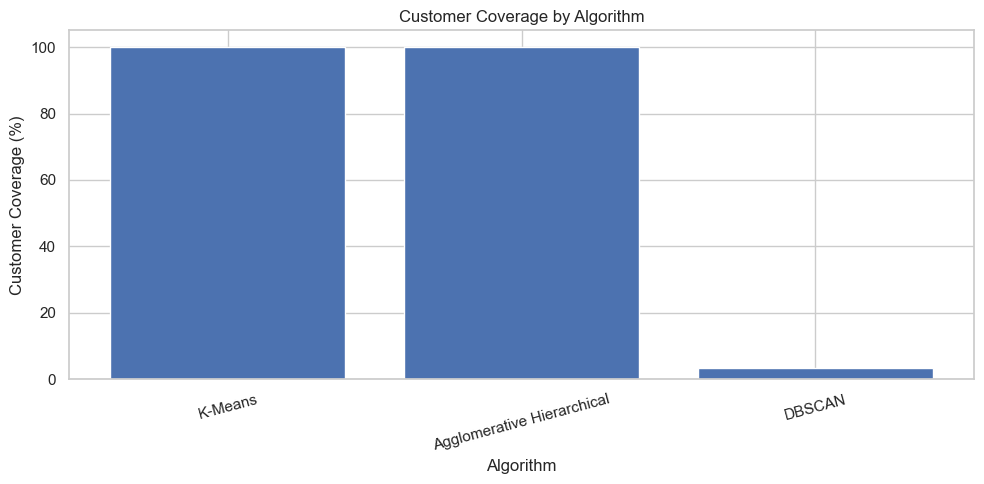

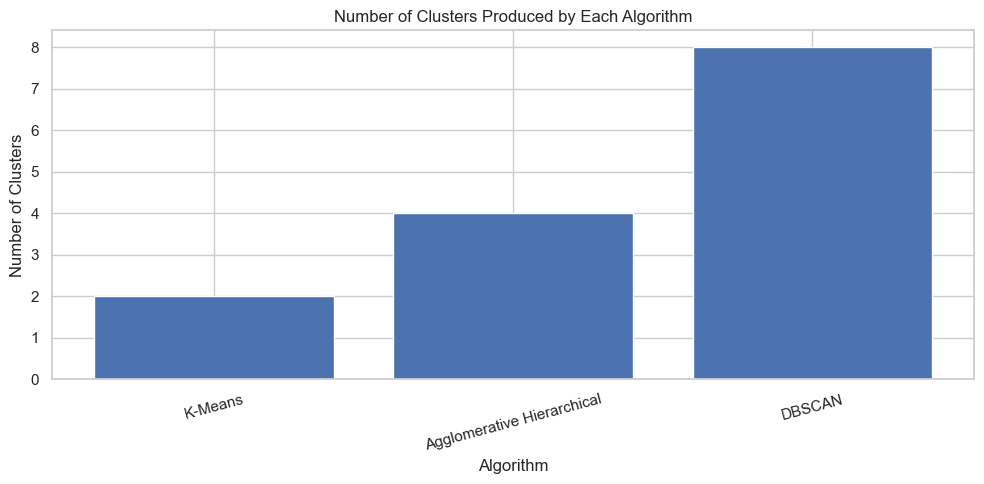


------------------------------------------------------------------------------------------
6.11 | FINAL BUSINESS INTERPRETATION
------------------------------------------------------------------------------------------
BUSINESS INTERPRETATION OF THE CLUSTERING ANALYSIS

1. K-MEANS
   • Produces 2 customer segments.
   • Assigns every customer to one of the two segments.
   • The silhouette score is 0.226, indicating moderate separation rather than extremely distinct clusters.
   • Despite the moderate statistical separation, the two segments show substantial behavioural differences in purchases, cash advances, balances and payment patterns.

2. AGGLOMERATIVE HIERARCHICAL CLUSTERING
   • Produces 4 clusters.
   • Approximately 99.844% of customers belong to the largest cluster.
   • The remaining clusters contain only very small numbers of customers.
   • Therefore, the tested Agglomerative configuration does not provide a balanced four-segment business structure.
   • Its main value i

,CHECK,VALUE,EXPECTED,STATUS
0,Customer count preserved,"8,950.000",8950,PASS
1,K-Means labels match customers,"8,950.000",8950,PASS
2,Agglomerative labels match customers,"8,950.000",8950,PASS
3,DBSCAN labels match customers,"8,950.000",8950,PASS
4,K-Means contains multiple clusters,2.000,>= 2,PASS
5,Agglomerative contains multiple clusters,4.000,>= 2,PASS
6,DBSCAN contains multiple non-noise clusters,8.000,>= 2,PASS
7,K-Means business profile created,2.000,2,PASS
8,Agglomerative cluster balance reviewed,99.844,< 99% preferred,WARNING
9,DBSCAN coverage reviewed,3.453,Context required,WARNING



✓ All critical Step 6 validation checks passed.
⚠ 2 analytical warning(s) are documented rather than treated as execution failures.

------------------------------------------------------------------------------------------
6.13 | STEP 6 FINAL SUMMARY
------------------------------------------------------------------------------------------
ALGORITHM COMPARISON
------------------------------------------------------------
K-Means clusters              : 2
K-Means silhouette            : 0.226
Agglomerative clusters        : 4
Agglomerative largest cluster : 99.844%
DBSCAN non-noise clusters     : 8
DBSCAN noise percentage       : 96.55%

BUSINESS INTERPRETATION
------------------------------------------------------------
K-Means identifies two behaviourally distinct customer groups, although the moderate silhouette score indicates that their statistical separation is not extremely strong.
Agglomerative clustering provides an additional structural perspective, but the tested four-cluste

In [29]:
# ============================================================
# STEP 6: ALGORITHM COMPARISON & BUSINESS INTERPRETATION
# ============================================================

clustering_header(
    "STEP 6: ALGORITHM COMPARISON & BUSINESS INTERPRETATION"
)

print(
    "Objective: compare clustering algorithms and translate "
    "customer segments into meaningful business insights."
)

print(f"Customer records : {len(df):,}")
print(f"Clustering features : {X_scaled.shape[1]}")
print(
    "Algorithms compared : "
    "K-Means, Agglomerative Hierarchical, DBSCAN"
)


# ============================================================
# 6.0 | INPUT VALIDATION
# ============================================================

clustering_section(
    "6.0 | INPUT VALIDATION"
)

required_step6_objects = [
    "df",
    "X_scaled",
    "df_preprocessed",
    "df_kmeans",
    "df_agg",
    "df_dbscan",
    "final_cluster_labels",
    "final_hierarchical_labels",
    "dbscan_labels",
    "K_OPTIMAL"
]

missing_step6_objects = [
    object_name
    for object_name in required_step6_objects
    if object_name not in globals()
]

if missing_step6_objects:
    raise NameError(
        "Required objects from previous steps are missing: "
        + ", ".join(missing_step6_objects)
    )

if len(df) != len(X_scaled):
    raise ValueError(
        "df and X_scaled contain different numbers of customers."
    )

if not df.index.equals(X_scaled.index):
    raise ValueError(
        "df and X_scaled indexes do not match."
    )

if len(final_cluster_labels) != len(df):
    raise ValueError(
        "K-Means labels do not match customer count."
    )

if len(final_hierarchical_labels) != len(df):
    raise ValueError(
        "Agglomerative labels do not match customer count."
    )

if len(dbscan_labels) != len(df):
    raise ValueError(
        "DBSCAN labels do not match customer count."
    )

print("Input validation : PASSED")
print("K-Means results available : YES")
print("Agglomerative results available : YES")
print("DBSCAN results available : YES")


# ============================================================
# 6.1 | ALGORITHM PERFORMANCE COMPARISON
# ============================================================

clustering_section(
    "6.1 | ALGORITHM PERFORMANCE COMPARISON"
)

print(
    "The three algorithms are compared using internal clustering "
    "quality metrics, customer coverage and cluster distribution."
)

print("\nMetric interpretation:")
print(
    "  • Silhouette Score        : higher values indicate better separation."
)
print(
    "  • Davies-Bouldin Index    : lower values indicate better separation."
)
print(
    "  • Calinski-Harabasz Score : higher values indicate stronger "
    "compactness/separation."
)
print(
    "  • Coverage                : percentage of customers assigned "
    "to a non-noise segment."
)
print(
    "  • Noise Percentage        : percentage classified as DBSCAN noise."
)


# ------------------------------------------------------------
# Reusable evaluation function
# ------------------------------------------------------------

def evaluate_algorithm(
    algorithm_name,
    labels,
    X_data,
    noise_label=None
):

    labels = np.asarray(labels)

    if noise_label is not None:

        evaluation_mask = labels != noise_label

    else:

        evaluation_mask = np.ones(
            len(labels),
            dtype=bool
        )

    X_evaluation = X_data[
        evaluation_mask
    ]

    evaluation_labels = labels[
        evaluation_mask
    ]

    unique_clusters = np.unique(
        evaluation_labels
    )

    cluster_count = len(
        unique_clusters
    )

    customer_count = len(
        labels
    )

    non_noise_customers = len(
        evaluation_labels
    )

    coverage_percentage = (
        non_noise_customers
        / customer_count
        * 100
    )

    if noise_label is not None:

        noise_count = int(
            (labels == noise_label).sum()
        )

        noise_percentage = (
            noise_count
            / customer_count
            * 100
        )

    else:

        noise_count = 0
        noise_percentage = 0.0

    silhouette_value = np.nan
    davies_bouldin_value = np.nan
    calinski_harabasz_value = np.nan

    if (
        cluster_count >= 2
        and len(evaluation_labels) > cluster_count
    ):

        silhouette_value = silhouette_score(
            X_evaluation,
            evaluation_labels
        )

        davies_bouldin_value = davies_bouldin_score(
            X_evaluation,
            evaluation_labels
        )

        calinski_harabasz_value = calinski_harabasz_score(
            X_evaluation,
            evaluation_labels
        )

    cluster_counts = (
        pd.Series(
            evaluation_labels
        )
        .value_counts()
        .sort_index()
    )

    smallest_cluster = (
        int(cluster_counts.min())
        if len(cluster_counts) > 0
        else 0
    )

    largest_cluster = (
        int(cluster_counts.max())
        if len(cluster_counts) > 0
        else 0
    )

    smallest_cluster_percentage = (
        smallest_cluster
        / non_noise_customers
        * 100
        if non_noise_customers > 0
        else np.nan
    )

    largest_cluster_percentage = (
        largest_cluster
        / non_noise_customers
        * 100
        if non_noise_customers > 0
        else np.nan
    )

    return {
        "ALGORITHM": algorithm_name,
        "CLUSTERS": cluster_count,
        "NOISE_COUNT": noise_count,
        "NOISE_PERCENT": noise_percentage,
        "NON_NOISE_CUSTOMERS": non_noise_customers,
        "COVERAGE_PERCENT": coverage_percentage,
        "SILHOUETTE": silhouette_value,
        "DAVIES_BOULDIN": davies_bouldin_value,
        "CALINSKI_HARABASZ": calinski_harabasz_value,
        "SMALLEST_CLUSTER": smallest_cluster,
        "LARGEST_CLUSTER": largest_cluster,
        "SMALLEST_CLUSTER_PERCENT": smallest_cluster_percentage,
        "LARGEST_CLUSTER_PERCENT": largest_cluster_percentage
    }


# ------------------------------------------------------------
# Evaluate all three algorithms
# ------------------------------------------------------------

kmeans_evaluation = evaluate_algorithm(
    "K-Means",
    final_cluster_labels,
    X_scaled
)

hierarchical_evaluation = evaluate_algorithm(
    "Agglomerative Hierarchical",
    final_hierarchical_labels,
    X_scaled
)

dbscan_evaluation = evaluate_algorithm(
    "DBSCAN",
    dbscan_labels,
    X_scaled,
    noise_label=DBSCAN_NOISE_LABEL
)

algorithm_comparison_df = pd.DataFrame([
    kmeans_evaluation,
    hierarchical_evaluation,
    dbscan_evaluation
])

display_clustering_table(
    algorithm_comparison_df.round(4),
    "Algorithm Performance Comparison"
)


# ============================================================
# 6.2 | CLUSTER QUALITY COMPARISON
# ============================================================

clustering_section(
    "6.2 | CLUSTER QUALITY COMPARISON"
)

quality_comparison_df = algorithm_comparison_df[
    [
        "ALGORITHM",
        "SILHOUETTE",
        "DAVIES_BOULDIN",
        "CALINSKI_HARABASZ"
    ]
].copy()

quality_comparison_df[
    "SILHOUETTE_RANK"
] = (
    quality_comparison_df[
        "SILHOUETTE"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

quality_comparison_df[
    "DAVIES_BOULDIN_RANK"
] = (
    quality_comparison_df[
        "DAVIES_BOULDIN"
    ]
    .rank(
        ascending=True,
        method="min"
    )
)

quality_comparison_df[
    "CALINSKI_HARABASZ_RANK"
] = (
    quality_comparison_df[
        "CALINSKI_HARABASZ"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

display_clustering_table(
    quality_comparison_df.round(4),
    "Internal Cluster Quality Comparison"
)

print(
    "\nImportant interpretation:"
)

print(
    "K-Means has a silhouette score of "
    f"{kmeans_evaluation['SILHOUETTE']:.3f}. "
    "This indicates that the two groups have observable "
    "behavioural separation, but the separation is moderate "
    "rather than exceptionally strong."
)

print(
    "Agglomerative has a higher silhouette score, but its "
    "cluster distribution must be considered because nearly "
    "the entire customer base belongs to one cluster."
)

print(
    "DBSCAN has the highest silhouette score in this comparison, "
    "but that value is calculated only on its 309 non-noise "
    "customers and therefore cannot be interpreted independently "
    "of its 96.55% noise rate."
)


# ============================================================
# 6.3 | CUSTOMER COVERAGE & CLUSTER DISTRIBUTION
# ============================================================

clustering_section(
    "6.3 | CUSTOMER COVERAGE & CLUSTER DISTRIBUTION"
)

coverage_comparison_df = algorithm_comparison_df[
    [
        "ALGORITHM",
        "CLUSTERS",
        "NON_NOISE_CUSTOMERS",
        "COVERAGE_PERCENT",
        "NOISE_COUNT",
        "NOISE_PERCENT",
        "SMALLEST_CLUSTER",
        "LARGEST_CLUSTER",
        "SMALLEST_CLUSTER_PERCENT",
        "LARGEST_CLUSTER_PERCENT"
    ]
].copy()

display_clustering_table(
    coverage_comparison_df.round(3),
    "Customer Coverage and Cluster Distribution"
)


# ------------------------------------------------------------
# K-Means distribution
# ------------------------------------------------------------

kmeans_distribution = (
    pd.Series(
        final_cluster_labels,
        name="KMeans_Cluster"
    )
    .value_counts()
    .sort_index()
    .rename("CUSTOMER_COUNT")
    .to_frame()
)

kmeans_distribution[
    "CUSTOMER_PERCENT"
] = (
    kmeans_distribution[
        "CUSTOMER_COUNT"
    ]
    / len(df)
    * 100
)

display_clustering_table(
    kmeans_distribution.reset_index().round(3),
    "K-Means Customer Distribution"
)


# ------------------------------------------------------------
# Agglomerative distribution
# ------------------------------------------------------------

hierarchical_distribution = (
    pd.Series(
        final_hierarchical_labels,
        name="Agg_Cluster"
    )
    .value_counts()
    .sort_index()
    .rename("CUSTOMER_COUNT")
    .to_frame()
)

hierarchical_distribution[
    "CUSTOMER_PERCENT"
] = (
    hierarchical_distribution[
        "CUSTOMER_COUNT"
    ]
    / len(df)
    * 100
)

display_clustering_table(
    hierarchical_distribution.reset_index().round(3),
    "Agglomerative Customer Distribution"
)


# ------------------------------------------------------------
# DBSCAN distribution
# ------------------------------------------------------------

dbscan_distribution = (
    pd.Series(
        dbscan_labels,
        name="DBSCAN_Cluster"
    )
    .value_counts()
    .sort_index()
    .rename("CUSTOMER_COUNT")
    .to_frame()
)

dbscan_distribution[
    "CUSTOMER_PERCENT"
] = (
    dbscan_distribution[
        "CUSTOMER_COUNT"
    ]
    / len(df)
    * 100
)

display_clustering_table(
    dbscan_distribution.reset_index().round(3),
    "DBSCAN Customer Distribution"
)

print(
    "\nDistribution interpretation:"
)

agg_largest_cluster_percentage = (
    hierarchical_distribution[
        "CUSTOMER_PERCENT"
    ].max()
)

print(
    f"Agglomerative clustering places "
    f"{agg_largest_cluster_percentage:.3f}% of customers "
    "in its largest cluster."
)

print(
    "Therefore, the four-cluster Agglomerative solution should "
    "be treated primarily as a structural comparison rather "
    "than as a balanced four-segment business solution."
)


# ============================================================
# 6.4 | K-MEANS VS AGGLOMERATIVE CLUSTER AGREEMENT
# ============================================================

clustering_section(
    "6.4 | K-MEANS VS AGGLOMERATIVE CLUSTER AGREEMENT"
)

print(
    "The two clustering approaches are compared using a "
    "customer-level cross-tabulation."
)

cluster_cross_tab = pd.crosstab(
    pd.Series(
        final_cluster_labels,
        name="KMeans_Cluster"
    ),
    pd.Series(
        final_hierarchical_labels,
        name="Agg_Cluster"
    )
)

display_clustering_table(
    cluster_cross_tab,
    "K-Means vs Agglomerative Cluster Cross-Tabulation"
)


# ------------------------------------------------------------
# Dominant mapping
# ------------------------------------------------------------

kmeans_to_agg_match = (
    cluster_cross_tab.max(axis=1)
    / cluster_cross_tab.sum(axis=1)
    * 100
)

cluster_agreement_summary = pd.DataFrame({
    "KMEANS_CLUSTER": kmeans_to_agg_match.index,
    "DOMINANT_AGG_CLUSTER": (
        cluster_cross_tab.idxmax(axis=1).values
    ),
    "DOMINANT_SHARE_PERCENT": (
        kmeans_to_agg_match.values
    )
})

display_clustering_table(
    cluster_agreement_summary.round(3),
    "Dominant Agglomerative Mapping for Each K-Means Cluster"
)


# ------------------------------------------------------------
# Correct interpretation of agreement
# ------------------------------------------------------------

print(
    "\nInterpretation:"
)

print(
    "The cross-tabulation does not show strong agreement between "
    "the two segmentation structures."
)

print(
    "Instead, Agglomerative clustering assigns nearly all "
    "customers from both K-Means clusters to the same dominant "
    "Agglomerative cluster."
)

print(
    "Therefore, the Agglomerative four-cluster solution does not "
    "reproduce the two-group customer structure identified by "
    "K-Means."
)

print(
    "The agreement table should consequently be interpreted as "
    "evidence of a highly concentrated Agglomerative partition, "
    "not as confirmation that both algorithms discovered the "
    "same business segments."
)


# ============================================================
# 6.5 | DBSCAN LOW-DENSITY OBSERVATION INTERPRETATION
# ============================================================

clustering_section(
    "6.5 | DBSCAN LOW-DENSITY OBSERVATION INTERPRETATION"
)

dbscan_noise_count = int(
    (dbscan_labels == DBSCAN_NOISE_LABEL).sum()
)

dbscan_noise_percentage = (
    dbscan_noise_count
    / len(df)
    * 100
)

dbscan_non_noise_count = (
    len(df)
    - dbscan_noise_count
)

print(
    f"DBSCAN low-density observations : "
    f"{dbscan_noise_count:,}"
)

print(
    f"DBSCAN non-noise customers : "
    f"{dbscan_non_noise_count:,}"
)

print(
    f"DBSCAN low-density percentage : "
    f"{dbscan_noise_percentage:.2f}%"
)

print(
    "\nImportant distinction:"
)

print(
    "DBSCAN noise means that an observation does not belong to "
    "a sufficiently dense region under the selected eps and "
    "min_samples configuration."
)

print(
    "It does NOT automatically mean that the customer is "
    "financially abnormal, risky, or problematic."
)

if dbscan_noise_percentage >= 50:

    print(
        "\nCurrent result:"
    )

    print(
        "The selected DBSCAN configuration classifies more than "
        "half of the customer base as low-density observations."
    )

    print(
        "With 96.55% of customers outside the identified dense "
        "groups, DBSCAN is not producing a broad customer "
        "segmentation for the current feature space and parameter "
        "configuration."
    )

    print(
        "Its more appropriate analytical role in this project is "
        "to investigate sparse or unusual density patterns rather "
        "than to serve as the main customer segmentation."
    )

else:

    print(
        "\nThe DBSCAN configuration identifies a moderate "
        "low-density population while retaining a substantial "
        "portion of customers inside dense groups."
    )


# ------------------------------------------------------------
# DBSCAN low-density profile
# ------------------------------------------------------------

business_profile_features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT",
    "TENURE"
]

business_profile_features = [
    feature
    for feature in business_profile_features
    if feature in df_preprocessed.columns
]

dbscan_noise_customers = df_preprocessed[
    pd.Series(
        dbscan_labels,
        index=df_preprocessed.index
    )
    == DBSCAN_NOISE_LABEL
].copy()

if len(dbscan_noise_customers) > 0:

    dbscan_noise_profile = (
        dbscan_noise_customers[
            business_profile_features
        ]
        .mean()
        .to_frame("LOW_DENSITY_MEAN")
    )

    overall_business_profile = (
        df_preprocessed[
            business_profile_features
        ]
        .mean()
        .to_frame("OVERALL_MEAN")
    )

    dbscan_noise_profile_comparison = (
        dbscan_noise_profile
        .join(
            overall_business_profile
        )
    )

    dbscan_noise_profile_comparison[
        "DIFFERENCE_PERCENT"
    ] = np.where(
        dbscan_noise_profile_comparison[
            "OVERALL_MEAN"
        ] != 0,
        (
            (
                dbscan_noise_profile_comparison[
                    "LOW_DENSITY_MEAN"
                ]
                -
                dbscan_noise_profile_comparison[
                    "OVERALL_MEAN"
                ]
            )
            /
            dbscan_noise_profile_comparison[
                "OVERALL_MEAN"
            ]
            * 100
        ),
        np.nan
    )

    display_clustering_table(
        dbscan_noise_profile_comparison.round(3),
        "DBSCAN Low-Density Behaviour vs Overall Customer Base"
    )

    print(
        "\nThe low-density group's averages are relatively close "
        "to the overall population on the displayed variables."
    )

    print(
        "Therefore, these observations should not be labelled "
        "as business outliers solely because DBSCAN assigns "
        "them the noise label."
    )

else:

    dbscan_noise_profile_comparison = pd.DataFrame()


# ============================================================
# 6.6 | ALGORITHM STRENGTHS & LIMITATIONS
# ============================================================

clustering_section(
    "6.6 | ALGORITHM STRENGTHS & LIMITATIONS"
)

algorithm_tradeoff_df = pd.DataFrame([
    {
        "ALGORITHM": "K-Means",
        "STRENGTH": (
            "Simple, scalable, interpretable and assigns "
            "every customer to a segment."
        ),
        "LIMITATION": (
            "Requires a predefined number of clusters and "
            "works best when groups are reasonably compact."
        ),
        "OBSERVED_RESULT": (
            "Produces two balanced customer groups with "
            "clear behavioural differences."
        ),
        "BUSINESS_USE": (
            "Broad customer segmentation and behavioural "
            "targeting analysis."
        )
    },
    {
        "ALGORITHM": "Agglomerative Hierarchical",
        "STRENGTH": (
            "Provides hierarchical structure and an "
            "independent clustering perspective."
        ),
        "LIMITATION": (
            "The tested four-cluster solution is extremely "
            "imbalanced, with almost all customers in one cluster."
        ),
        "OBSERVED_RESULT": (
            "Four clusters are produced, but 99.844% of "
            "customers belong to one cluster."
        ),
        "BUSINESS_USE": (
            "Structural validation and examination of "
            "customer relationships."
        )
    },
    {
        "ALGORITHM": "DBSCAN",
        "STRENGTH": (
            "Can identify dense groups and separate "
            "low-density observations."
        ),
        "LIMITATION": (
            "Sensitive to eps and min_samples and can produce "
            "very high noise levels in this feature space."
        ),
        "OBSERVED_RESULT": (
            "Eight non-noise clusters are identified, but "
            "96.55% of customers are labelled low-density."
        ),
        "BUSINESS_USE": (
            "Density-based behavioural investigation and "
            "sparse-pattern analysis."
        )
    }
])

display_clustering_table(
    algorithm_tradeoff_df,
    "Algorithm Strengths, Limitations and Observed Results"
)


# ============================================================
# 6.7 | BUSINESS INTERPRETATION OF K-MEANS SEGMENTS
# ============================================================

clustering_section(
    "6.7 | BUSINESS INTERPRETATION OF K-MEANS SEGMENTS"
)

print(
    f"K-Means produced {K_OPTIMAL} customer segments."
)

print(
    "The two groups should be interpreted as behavioural "
    "segments rather than perfectly separated populations."
)

# ------------------------------------------------------------
# Create K-Means business profile
# ------------------------------------------------------------

df_business_kmeans = df_preprocessed.copy(
    deep=True
)

df_business_kmeans[
    "KMeans_Cluster"
] = final_cluster_labels

kmeans_business_profile = (
    df_business_kmeans
    .groupby("KMeans_Cluster")[
        business_profile_features
    ]
    .mean()
)

display_clustering_table(
    kmeans_business_profile.round(3),
    "K-Means Business Behaviour Profile"
)


# ------------------------------------------------------------
# Cluster sizes
# ------------------------------------------------------------

kmeans_business_size = (
    df_business_kmeans[
        "KMeans_Cluster"
    ]
    .value_counts()
    .sort_index()
)

kmeans_business_percentage = (
    kmeans_business_size
    / len(df_business_kmeans)
    * 100
)


# ------------------------------------------------------------
# Overall customer averages
# ------------------------------------------------------------

overall_means = (
    df_preprocessed[
        business_profile_features
    ]
    .mean()
)


# ------------------------------------------------------------
# Build descriptive business interpretation
# ------------------------------------------------------------

business_segment_records = []

for cluster_id in sorted(
    df_business_kmeans[
        "KMeans_Cluster"
    ].unique()
):

    cluster_data = kmeans_business_profile.loc[
        cluster_id
    ]

    cluster_size = int(
        kmeans_business_size.loc[
            cluster_id
        ]
    )

    cluster_percentage = float(
        kmeans_business_percentage.loc[
            cluster_id
        ]
    )

    purchase_value = cluster_data.get(
        "PURCHASES",
        np.nan
    )

    cash_advance_value = cluster_data.get(
        "CASH_ADVANCE",
        np.nan
    )

    balance_value = cluster_data.get(
        "BALANCE",
        np.nan
    )

    credit_limit_value = cluster_data.get(
        "CREDIT_LIMIT",
        np.nan
    )

    purchase_frequency = cluster_data.get(
        "PURCHASES_FREQUENCY",
        np.nan
    )

    cash_advance_frequency = cluster_data.get(
        "CASH_ADVANCE_FREQUENCY",
        np.nan
    )

    full_payment = cluster_data.get(
        "PRC_FULL_PAYMENT",
        np.nan
    )

    payments_value = cluster_data.get(
        "PAYMENTS",
        np.nan
    )

    behaviour_tags = []

    if (
        pd.notna(purchase_value)
        and purchase_value
        > overall_means["PURCHASES"] * 1.20
    ):

        behaviour_tags.append(
            "High purchase activity"
        )

    elif (
        pd.notna(purchase_value)
        and purchase_value
        < overall_means["PURCHASES"] * 0.50
    ):

        behaviour_tags.append(
            "Low purchase activity"
        )

    if (
        pd.notna(cash_advance_value)
        and cash_advance_value
        > overall_means["CASH_ADVANCE"] * 1.20
    ):

        behaviour_tags.append(
            "High cash-advance usage"
        )

    elif (
        pd.notna(cash_advance_value)
        and cash_advance_value
        < overall_means["CASH_ADVANCE"] * 0.50
    ):

        behaviour_tags.append(
            "Low cash-advance usage"
        )

    if (
        pd.notna(purchase_frequency)
        and purchase_frequency
        > overall_means["PURCHASES_FREQUENCY"] * 1.15
    ):

        behaviour_tags.append(
            "Frequent purchasing"
        )

    if (
        pd.notna(cash_advance_frequency)
        and cash_advance_frequency
        > overall_means["CASH_ADVANCE_FREQUENCY"] * 1.20
    ):

        behaviour_tags.append(
            "Frequent cash advances"
        )

    if (
        pd.notna(full_payment)
        and full_payment
        > overall_means["PRC_FULL_PAYMENT"] * 1.50
    ):

        behaviour_tags.append(
            "Strong full-payment behaviour"
        )

    if (
        pd.notna(balance_value)
        and balance_value
        > overall_means["BALANCE"] * 1.20
    ):

        behaviour_tags.append(
            "Higher outstanding balance"
        )

    if (
        pd.notna(credit_limit_value)
        and credit_limit_value
        > overall_means["CREDIT_LIMIT"] * 1.20
    ):

        behaviour_tags.append(
            "Higher credit limit"
        )

    if (
        pd.notna(payments_value)
        and payments_value
        > overall_means["PAYMENTS"] * 1.20
    ):

        behaviour_tags.append(
            "High payment activity"
        )

    if len(behaviour_tags) == 0:

        behaviour_tags.append(
            "Moderate or mixed behaviour"
        )

    business_segment_records.append({
        "KMEANS_CLUSTER": cluster_id,
        "CUSTOMER_COUNT": cluster_size,
        "CUSTOMER_PERCENT": cluster_percentage,
        "BEHAVIOUR": "; ".join(
            behaviour_tags
        )
    })

kmeans_business_interpretation_df = pd.DataFrame(
    business_segment_records
)

display_clustering_table(
    kmeans_business_interpretation_df.round(3),
    "K-Means Business Segment Interpretation"
)


# ============================================================
# 6.8 | BUSINESS-ORIENTED SEGMENT SUMMARY
# ============================================================

clustering_section(
    "6.8 | BUSINESS-ORIENTED SEGMENT SUMMARY"
)

print(
    "The following interpretations are descriptive and are "
    "derived from observed cluster averages."
)

business_summary_records = []

for cluster_id in sorted(
    df_business_kmeans[
        "KMeans_Cluster"
    ].unique()
):

    cluster_data = kmeans_business_profile.loc[
        cluster_id
    ]

    relative_values = {}

    for feature in business_profile_features:

        overall_value = overall_means[
            feature
        ]

        cluster_value = cluster_data[
            feature
        ]

        if (
            pd.notna(overall_value)
            and overall_value != 0
            and pd.notna(cluster_value)
        ):

            relative_values[feature] = (
                cluster_value
                / overall_value
            )

    dominant_features = sorted(
        relative_values,
        key=relative_values.get,
        reverse=True
    )[:3]

    lower_features = sorted(
        relative_values,
        key=relative_values.get
    )[:3]

    dominant_text = ", ".join(
        dominant_features
    )

    lower_text = ", ".join(
        lower_features
    )

    business_summary_records.append({
        "SEGMENT": cluster_id,
        "CUSTOMERS": int(
            kmeans_business_size.loc[
                cluster_id
            ]
        ),
        "CUSTOMER_SHARE_%": round(
            kmeans_business_percentage.loc[
                cluster_id
            ],
            2
        ),
        "RELATIVELY_HIGHER_BEHAVIOUR": dominant_text,
        "RELATIVELY_LOWER_BEHAVIOUR": lower_text
    })

business_segment_summary_df = pd.DataFrame(
    business_summary_records
)

display_clustering_table(
    business_segment_summary_df,
    "Business-Oriented Segment Summary"
)


# ============================================================
# 6.9 | BUSINESS ACTION FRAMEWORK
# ============================================================

clustering_section(
    "6.9 | BUSINESS ACTION FRAMEWORK"
)

print(
    "Potential business actions are mapped to observed behaviour. "
    "These are analytical recommendations rather than claims "
    "about individual customer intent."
)

business_action_records = []

for cluster_id in sorted(
    df_business_kmeans[
        "KMeans_Cluster"
    ].unique()
):

    cluster_data = kmeans_business_profile.loc[
        cluster_id
    ]

    actions = []

    purchase_value = cluster_data.get(
        "PURCHASES",
        np.nan
    )

    cash_advance_value = cluster_data.get(
        "CASH_ADVANCE",
        np.nan
    )

    purchase_frequency = cluster_data.get(
        "PURCHASES_FREQUENCY",
        np.nan
    )

    cash_advance_frequency = cluster_data.get(
        "CASH_ADVANCE_FREQUENCY",
        np.nan
    )

    full_payment = cluster_data.get(
        "PRC_FULL_PAYMENT",
        np.nan
    )

    if (
        pd.notna(purchase_value)
        and purchase_value
        > overall_means["PURCHASES"] * 1.20
    ):

        actions.append(
            "Consider purchase-reward or loyalty campaigns."
        )

    if (
        pd.notna(purchase_frequency)
        and purchase_frequency
        > overall_means["PURCHASES_FREQUENCY"] * 1.15
    ):

        actions.append(
            "Consider personalised transaction-based offers."
        )

    if (
        pd.notna(cash_advance_value)
        and cash_advance_value
        > overall_means["CASH_ADVANCE"] * 1.20
    ):

        actions.append(
            "Review cash-advance usage and consider "
            "financial-product education or targeted offers."
        )

    if (
        pd.notna(cash_advance_frequency)
        and cash_advance_frequency
        > overall_means["CASH_ADVANCE_FREQUENCY"] * 1.20
    ):

        actions.append(
            "Monitor repeated cash-advance behaviour."
        )

    if (
        pd.notna(full_payment)
        and full_payment
        > overall_means["PRC_FULL_PAYMENT"] * 1.50
    ):

        actions.append(
            "Consider retention and premium-service offers."
        )

    if len(actions) == 0:

        actions.append(
            "Use broad engagement and cross-sell strategies "
            "based on additional customer information."
        )

    business_action_records.append({
        "SEGMENT": cluster_id,
        "POTENTIAL_BUSINESS_ACTIONS": " ".join(
            actions
        )
    })

business_action_df = pd.DataFrame(
    business_action_records
)

display_clustering_table(
    business_action_df,
    "Potential Business Actions by Segment"
)


# ============================================================
# 6.10 | ALGORITHM COMPARISON VISUALISATION
# ============================================================

clustering_section(
    "6.10 | ALGORITHM COMPARISON VISUALISATION"
)


# ------------------------------------------------------------
# Silhouette comparison
# ------------------------------------------------------------

comparison_plot_df = algorithm_comparison_df[
    [
        "ALGORITHM",
        "SILHOUETTE"
    ]
].copy()

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    comparison_plot_df[
        "ALGORITHM"
    ],
    comparison_plot_df[
        "SILHOUETTE"
    ]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Silhouette Score Comparison"
)

plt.ylabel(
    "Silhouette Score"
)

plt.xlabel(
    "Algorithm"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Coverage comparison
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    algorithm_comparison_df[
        "ALGORITHM"
    ],
    algorithm_comparison_df[
        "COVERAGE_PERCENT"
    ]
)

plt.title(
    "Customer Coverage by Algorithm"
)

plt.ylabel(
    "Customer Coverage (%)"
)

plt.xlabel(
    "Algorithm"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Cluster count comparison
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    algorithm_comparison_df[
        "ALGORITHM"
    ],
    algorithm_comparison_df[
        "CLUSTERS"
    ]
)

plt.title(
    "Number of Clusters Produced by Each Algorithm"
)

plt.ylabel(
    "Number of Clusters"
)

plt.xlabel(
    "Algorithm"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# ============================================================
# 6.11 | FINAL BUSINESS INTERPRETATION
# ============================================================

clustering_section(
    "6.11 | FINAL BUSINESS INTERPRETATION"
)

print(
    "============================================================"
)

print(
    "BUSINESS INTERPRETATION OF THE CLUSTERING ANALYSIS"
)

print(
    "============================================================"
)


# ------------------------------------------------------------
# K-Means interpretation
# ------------------------------------------------------------

print(
    "\n1. K-MEANS"
)

print(
    f"   • Produces {K_OPTIMAL} customer segments."
)

print(
    "   • Assigns every customer to one of the two segments."
)

print(
    f"   • The silhouette score is "
    f"{kmeans_evaluation['SILHOUETTE']:.3f}, indicating "
    "moderate separation rather than extremely distinct clusters."
)

print(
    "   • Despite the moderate statistical separation, the "
    "two segments show substantial behavioural differences "
    "in purchases, cash advances, balances and payment patterns."
)


# ------------------------------------------------------------
# Agglomerative interpretation
# ------------------------------------------------------------

print(
    "\n2. AGGLOMERATIVE HIERARCHICAL CLUSTERING"
)

print(
    f"   • Produces "
    f"{len(np.unique(final_hierarchical_labels))} clusters."
)

print(
    f"   • Approximately "
    f"{agg_largest_cluster_percentage:.3f}% of customers "
    "belong to the largest cluster."
)

print(
    "   • The remaining clusters contain only very small "
    "numbers of customers."
)

print(
    "   • Therefore, the tested Agglomerative configuration "
    "does not provide a balanced four-segment business structure."
)

print(
    "   • Its main value in this analysis is as a structural "
    "comparison with the other clustering approaches."
)


# ------------------------------------------------------------
# DBSCAN interpretation
# ------------------------------------------------------------

print(
    "\n3. DBSCAN"
)

print(
    f"   • Produces "
    f"{dbscan_non_noise_cluster_count} non-noise clusters."
)

print(
    f"   • {dbscan_noise_percentage:.2f}% of customers are "
    "classified as low-density observations."
)

print(
    "   • Its silhouette score is calculated only using the "
    "309 non-noise customers."
)

print(
    "   • Consequently, the relatively high DBSCAN silhouette "
    "does not imply that DBSCAN provides a useful broad "
    "segmentation for the entire customer population."
)

print(
    "   • DBSCAN is more informative here as a density-based "
    "diagnostic approach."
)


# ------------------------------------------------------------
# Business segmentation interpretation
# ------------------------------------------------------------

print(
    "\n4. BUSINESS SEGMENTATION"
)

print(
    "   • The K-Means segments show a clear behavioural contrast."
)

print(
    "   • One segment is characterised by higher purchase "
    "activity, frequent purchasing and relatively low "
    "cash-advance usage."
)

print(
    "   • The other segment is characterised by higher "
    "cash-advance activity, lower purchase frequency and "
    "higher outstanding balance."
)

print(
    "   • These differences can support differentiated "
    "customer engagement, loyalty, cross-selling and "
    "behaviour-monitoring strategies."
)


# ------------------------------------------------------------
# Important analytical caution
# ------------------------------------------------------------

print(
    "\n5. IMPORTANT ANALYTICAL CAUTION"
)

print(
    "   • Cluster membership represents behavioural similarity "
    "within the available dataset."
)

print(
    "   • It does not establish customer intent, profitability, "
    "credit risk or future behaviour."
)

print(
    "   • The K-Means silhouette score also indicates that the "
    "segments are not perfectly separated."
)

print(
    "   • Business decisions should therefore combine these "
    "segments with additional customer, product, profitability "
    "and risk information."
)


# ============================================================
# 6.12 | FINAL STEP 6 VALIDATION
# ============================================================

clustering_section(
    "6.12 | FINAL STEP 6 VALIDATION"
)

step6_validation_records = []


# ------------------------------------------------------------
# Customer count
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "Customer count preserved",
    "VALUE": len(df),
    "EXPECTED": len(df),
    "STATUS": (
        "PASS"
        if len(df) == len(df)
        else "FAIL"
    )
})


# ------------------------------------------------------------
# K-Means labels
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "K-Means labels match customers",
    "VALUE": len(final_cluster_labels),
    "EXPECTED": len(df),
    "STATUS": (
        "PASS"
        if len(final_cluster_labels) == len(df)
        else "FAIL"
    )
})


# ------------------------------------------------------------
# Agglomerative labels
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "Agglomerative labels match customers",
    "VALUE": len(final_hierarchical_labels),
    "EXPECTED": len(df),
    "STATUS": (
        "PASS"
        if len(final_hierarchical_labels) == len(df)
        else "FAIL"
    )
})


# ------------------------------------------------------------
# DBSCAN labels
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "DBSCAN labels match customers",
    "VALUE": len(dbscan_labels),
    "EXPECTED": len(df),
    "STATUS": (
        "PASS"
        if len(dbscan_labels) == len(df)
        else "FAIL"
    )
})


# ------------------------------------------------------------
# K-Means cluster count
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "K-Means contains multiple clusters",
    "VALUE": len(
        np.unique(
            final_cluster_labels
        )
    ),
    "EXPECTED": ">= 2",
    "STATUS": (
        "PASS"
        if len(
            np.unique(
                final_cluster_labels
            )
        ) >= 2
        else "FAIL"
    )
})


# ------------------------------------------------------------
# Agglomerative cluster count
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "Agglomerative contains multiple clusters",
    "VALUE": len(
        np.unique(
            final_hierarchical_labels
        )
    ),
    "EXPECTED": ">= 2",
    "STATUS": (
        "PASS"
        if len(
            np.unique(
                final_hierarchical_labels
            )
        ) >= 2
        else "FAIL"
    )
})


# ------------------------------------------------------------
# DBSCAN cluster count
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "DBSCAN contains multiple non-noise clusters",
    "VALUE": dbscan_non_noise_cluster_count,
    "EXPECTED": ">= 2",
    "STATUS": (
        "PASS"
        if dbscan_non_noise_cluster_count >= 2
        else "FAIL"
    )
})


# ------------------------------------------------------------
# K-Means profile
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "K-Means business profile created",
    "VALUE": len(
        kmeans_business_profile
    ),
    "EXPECTED": K_OPTIMAL,
    "STATUS": (
        "PASS"
        if len(
            kmeans_business_profile
        ) == K_OPTIMAL
        else "CHECK"
    )
})


# ------------------------------------------------------------
# Agglomerative balance warning
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "Agglomerative cluster balance reviewed",
    "VALUE": round(
        agg_largest_cluster_percentage,
        3
    ),
    "EXPECTED": "< 99% preferred",
    "STATUS": (
        "PASS"
        if agg_largest_cluster_percentage < 99
        else "WARNING"
    )
})


# ------------------------------------------------------------
# DBSCAN coverage warning
# ------------------------------------------------------------

step6_validation_records.append({
    "CHECK": "DBSCAN coverage reviewed",
    "VALUE": round(
        100 - dbscan_noise_percentage,
        3
    ),
    "EXPECTED": "Context required",
    "STATUS": (
        "WARNING"
        if dbscan_noise_percentage >= 50
        else "PASS"
    )
})


step6_validation_df = pd.DataFrame(
    step6_validation_records
)

display_clustering_table(
    step6_validation_df,
    "Step 6 Validation Results"
)

step6_validation_failures = (
    step6_validation_df[
        "STATUS"
    ] == "FAIL"
).sum()

step6_validation_warnings = (
    step6_validation_df[
        "STATUS"
    ] == "WARNING"
).sum()

if step6_validation_failures == 0:

    print(
        "\n✓ All critical Step 6 validation checks passed."
    )

else:

    print(
        f"\n⚠ {step6_validation_failures} "
        "critical validation check(s) require attention."
    )

if step6_validation_warnings > 0:

    print(
        f"⚠ {step6_validation_warnings} analytical warning(s) "
        "are documented rather than treated as execution failures."
    )


# ============================================================
# 6.13 | STEP 6 FINAL SUMMARY
# ============================================================

clustering_section(
    "6.13 | STEP 6 FINAL SUMMARY"
)

print(
    "ALGORITHM COMPARISON"
)

print(
    "------------------------------------------------------------"
)

print(
    f"K-Means clusters              : "
    f"{len(np.unique(final_cluster_labels))}"
)

print(
    f"K-Means silhouette            : "
    f"{kmeans_evaluation['SILHOUETTE']:.3f}"
)

print(
    f"Agglomerative clusters        : "
    f"{len(np.unique(final_hierarchical_labels))}"
)

print(
    f"Agglomerative largest cluster : "
    f"{agg_largest_cluster_percentage:.3f}%"
)

print(
    f"DBSCAN non-noise clusters     : "
    f"{dbscan_non_noise_cluster_count}"
)

print(
    f"DBSCAN noise percentage       : "
    f"{dbscan_noise_percentage:.2f}%"
)

print(
    "\nBUSINESS INTERPRETATION"
)

print(
    "------------------------------------------------------------"
)

print(
    "K-Means identifies two behaviourally distinct customer "
    "groups, although the moderate silhouette score indicates "
    "that their statistical separation is not extremely strong."
)

print(
    "Agglomerative clustering provides an additional structural "
    "perspective, but the tested four-cluster configuration is "
    "highly imbalanced and therefore should not be interpreted "
    "as four balanced business segments."
)

print(
    "DBSCAN identifies a small number of dense customer groups "
    "while classifying most customers as low-density observations "
    "under the selected parameters."
)

print(
    "The K-Means profiles provide the clearest broad behavioural "
    "interpretation for the current customer population, while "
    "Agglomerative and DBSCAN provide complementary analytical "
    "evidence."
)

print(
    "\nImportant:"
)

print(
    "The comparison describes statistical and behavioural "
    "characteristics of the tested solutions. It does not claim "
    "that one algorithm is universally superior for every "
    "business objective."
)


# ============================================================
# 6.14 | PREPARED STEP 6 OBJECTS
# ============================================================

clustering_section(
    "6.14 | PREPARED STEP 6 OBJECTS"
)

step6_objects = {
    "algorithm_comparison_df": algorithm_comparison_df,
    "quality_comparison_df": quality_comparison_df,
    "coverage_comparison_df": coverage_comparison_df,
    "kmeans_distribution": kmeans_distribution,
    "hierarchical_distribution": hierarchical_distribution,
    "dbscan_distribution": dbscan_distribution,
    "cluster_cross_tab": cluster_cross_tab,
    "cluster_agreement_summary": cluster_agreement_summary,
    "dbscan_noise_profile_comparison": dbscan_noise_profile_comparison,
    "algorithm_tradeoff_df": algorithm_tradeoff_df,
    "kmeans_business_profile": kmeans_business_profile,
    "kmeans_business_interpretation_df": kmeans_business_interpretation_df,
    "business_segment_summary_df": business_segment_summary_df,
    "business_action_df": business_action_df,
    "step6_validation_df": step6_validation_df
}

print(
    "\nPrepared Step 6 objects:"
)

for object_name in step6_objects:
    print(
        f"  ✓ {object_name}"
    )


# ============================================================
# STEP 6 COMPLETION
# ============================================================

print(
    "\n============================================================"
)

print(
    "STEP 6 COMPLETED SUCCESSFULLY."
)

print(
    "Algorithm comparison and business interpretation are complete."
)

print(
    "The analysis explicitly documents the moderate K-Means "
    "separation, the highly imbalanced Agglomerative solution, "
    "and the very high DBSCAN low-density percentage."
)

print(
    "============================================================"
)

In [33]:
# ==========================================================================================
# STEP 7: PIPELINES, DEPLOYMENT & GITHUB SUBMISSION
# ==========================================================================================

clustering_header(
    "STEP 7: PIPELINES, DEPLOYMENT & GITHUB SUBMISSION"
)

print(
    "Objective: convert the validated clustering analysis into a reproducible, "
    "deployment-ready and GitHub-ready project."
)

print(f"Customer records              : {len(df):,}")
print(f"Final K-Means clusters        : {K_OPTIMAL}")
print(f"Clustering features           : {len(df_clustering.columns)}")
print("Deployment model              : K-Means")
print("Model status                  : VALIDATED IN STEPS 3–6")


# ==========================================================================================
# 7.0 | STEP 7 INPUT VALIDATION
# ==========================================================================================

clustering_section("7.0 | INPUT VALIDATION")

step7_required_objects = {
    "df": df,
    "df_preprocessed": df_preprocessed,
    "df_clustering": df_clustering,
    "X_scaled": X_scaled,
    "scaler": scaler,
    "final_kmeans": final_kmeans,
    "df_kmeans": df_kmeans,
    "K_OPTIMAL": K_OPTIMAL
}

step7_missing_objects = [
    name for name, value in step7_required_objects.items()
    if value is None
]

if step7_missing_objects:
    raise ValueError(
        "Step 7 cannot continue. Missing required objects: "
        + ", ".join(step7_missing_objects)
    )

if len(df_clustering) != len(df):
    raise ValueError("df_clustering and df must contain the same number of customers.")

if len(X_scaled) != len(df):
    raise ValueError("X_scaled and df must contain the same number of customers.")

if len(final_kmeans.labels_) != len(df):
    raise ValueError("Final K-Means labels do not match the customer count.")

deployment_features = list(df_clustering.columns)

if len(deployment_features) == 0:
    raise ValueError("No clustering features are available for deployment.")

if scaler.n_features_in_ != len(deployment_features):
    raise ValueError(
        "Scaler feature count does not match the deployment feature list."
    )

if final_kmeans.n_features_in_ != len(deployment_features):
    raise ValueError(
        "K-Means feature count does not match the deployment feature list."
    )

print("Input validation : PASSED")
print(f"Deployment features : {len(deployment_features)}")
print(f"K-Means clusters : {K_OPTIMAL}")


# ==========================================================================================
# 7.1 | DEPLOYMENT FEATURE SPECIFICATION
# ==========================================================================================

clustering_section("7.1 | DEPLOYMENT FEATURE SPECIFICATION")

print(
    "The deployment process uses the exact feature structure used by the validated "
    "K-Means model."
)

deployment_feature_table = pd.DataFrame({
    "FEATURE_ORDER": range(1, len(deployment_features) + 1),
    "FEATURE_NAME": deployment_features
})

display_clustering_table(
    deployment_feature_table,
    "Deployment Feature Order"
)

print("\nDeployment feature list:")
for position, feature in enumerate(deployment_features, start=1):
    print(f"  {position:>2}. {feature}")


# ==========================================================================================
# 7.2 | REPRODUCIBLE PREPROCESSING CONFIGURATION
# ==========================================================================================

clustering_section("7.2 | REPRODUCIBLE PREPROCESSING CONFIGURATION")

print(
    "The deployment configuration records the preprocessing assumptions used "
    "during model development."
)

# --------------------------------------------------------------------------
# Reconstruct the same preprocessing rules used in Step 3.
# --------------------------------------------------------------------------

DEPLOYMENT_OUTLIER_IQR_MULTIPLIER = OUTLIER_IQR_MULTIPLIER
DEPLOYMENT_SKEWNESS_THRESHOLD = SKEWNESS_TRANSFORM_THRESHOLD

deployment_source = df.copy(deep=True)

# Replace infinite values with NaN.
deployment_source = deployment_source.replace([np.inf, -np.inf], np.nan)

# --------------------------------------------------------------------------
# Median imputation values
# --------------------------------------------------------------------------

deployment_imputation_values = {}

for column in deployment_source.columns:
    if pd.api.types.is_numeric_dtype(deployment_source[column]):
        if deployment_source[column].isna().any():
            deployment_imputation_values[column] = deployment_source[column].median()

            deployment_source[column] = deployment_source[column].fillna(
                deployment_imputation_values[column]
            )

# --------------------------------------------------------------------------
# Determine outlier caps using the same 3 × IQR rule from Step 3.
# --------------------------------------------------------------------------

deployment_cap_records = []

for column in deployment_source.columns:

    if not pd.api.types.is_numeric_dtype(deployment_source[column]):
        continue

    q1 = deployment_source[column].quantile(0.25)
    q3 = deployment_source[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (
        DEPLOYMENT_OUTLIER_IQR_MULTIPLIER * iqr
    )

    upper_bound = q3 + (
        DEPLOYMENT_OUTLIER_IQR_MULTIPLIER * iqr
    )

    deployment_cap_records.append({
        "FEATURE": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LOWER_CAP": lower_bound,
        "UPPER_CAP": upper_bound
    })

deployment_cap_table = pd.DataFrame(deployment_cap_records)

# --------------------------------------------------------------------------
# Identify transaction-count variables requiring log1p transformation.
# This follows the Step 3 skewness rule.
# --------------------------------------------------------------------------

deployment_log_features = []

for column in ["PURCHASES_TRX", "CASH_ADVANCE_TRX"]:

    if column not in deployment_source.columns:
        continue

    if (deployment_source[column] >= 0).all():

        column_skewness = deployment_source[column].skew()

        if abs(column_skewness) >= DEPLOYMENT_SKEWNESS_THRESHOLD:
            deployment_log_features.append(column)

deployment_preprocessing_summary = pd.DataFrame({
    "SETTING": [
        "Infinite values",
        "Missing-value treatment",
        "Outlier method",
        "Outlier multiplier",
        "Skewness transformation",
        "Scaling method",
        "Random state",
        "K-Means clusters"
    ],
    "VALUE": [
        "Replace ±inf with NaN",
        "Median imputation",
        f"{DEPLOYMENT_OUTLIER_IQR_MULTIPLIER:.1f} × IQR capping",
        DEPLOYMENT_OUTLIER_IQR_MULTIPLIER,
        (
            "log1p on: " + ", ".join(deployment_log_features)
            if deployment_log_features
            else "No transaction-count log transformation"
        ),
        "StandardScaler",
        RANDOM_STATE,
        K_OPTIMAL
    ]
})

display_clustering_table(
    deployment_preprocessing_summary,
    "Deployment Preprocessing Configuration"
)

print(
    f"\nStored imputation values : {len(deployment_imputation_values)}"
)

print(
    "Log-transformed deployment features : "
    + (
        ", ".join(deployment_log_features)
        if deployment_log_features
        else "None"
    )
)


# ==========================================================================================
# 7.3 | DEPLOYMENT PREPROCESSING FUNCTION
# ==========================================================================================

clustering_section("7.3 | DEPLOYMENT PREPROCESSING FUNCTION")

print(
    "A reusable preprocessing function is created so that new customer records "
    "follow the same transformation sequence as model development."
)


def preprocess_for_deployment(
    input_data,
    feature_list=deployment_features
):
    """
    Apply the preprocessing logic required by the validated K-Means model.

    Expected input:
        A pandas DataFrame containing raw customer-level numerical variables.

    Returns:
        A pandas DataFrame containing the exact clustering features
        required by the trained scaler and K-Means model.
    """

    data = input_data.copy(deep=True)

    # --------------------------------------------------------------
    # Remove customer identifier if supplied.
    # --------------------------------------------------------------

    if "CUST_ID" in data.columns:
        data = data.drop(columns=["CUST_ID"])

    # --------------------------------------------------------------
    # Replace infinite values.
    # --------------------------------------------------------------

    data = data.replace([np.inf, -np.inf], np.nan)

    # --------------------------------------------------------------
    # Add any missing expected source columns before preprocessing.
    # --------------------------------------------------------------

    source_columns_required = set(
        [
            "BALANCE",
            "BALANCE_FREQUENCY",
            "PURCHASES",
            "PURCHASES_FREQUENCY",
            "PURCHASES_TRX",
            "CASH_ADVANCE",
            "CASH_ADVANCE_FREQUENCY",
            "CASH_ADVANCE_TRX",
            "CREDIT_LIMIT",
            "PAYMENTS",
            "MINIMUM_PAYMENTS",
            "PRC_FULL_PAYMENT",
            "TENURE",
            "ONEOFF_PURCHASES",
            "INSTALLMENTS_PURCHASES"
        ]
    )

    missing_source_columns = [
        column
        for column in source_columns_required
        if column not in data.columns
    ]

    if missing_source_columns:
        raise ValueError(
            "Deployment input is missing required source columns: "
            + ", ".join(missing_source_columns)
        )

    # --------------------------------------------------------------
    # Median imputation using development-data values.
    # --------------------------------------------------------------

    for column, median_value in deployment_imputation_values.items():

        if column in data.columns:
            data[column] = data[column].fillna(median_value)

    # --------------------------------------------------------------
    # Any remaining numerical missing values use the development
    # median calculated from the training dataset.
    # --------------------------------------------------------------

    for column in data.columns:

        if pd.api.types.is_numeric_dtype(data[column]):

            if data[column].isna().any():

                if column in deployment_source.columns:
                    fallback_median = deployment_source[column].median()
                else:
                    fallback_median = 0.0

                data[column] = data[column].fillna(fallback_median)

    # --------------------------------------------------------------
    # Apply the same 3 × IQR caps.
    # --------------------------------------------------------------

    for _, row in deployment_cap_table.iterrows():

        column = row["FEATURE"]

        if column in data.columns:

            data[column] = data[column].clip(
                lower=row["LOWER_CAP"],
                upper=row["UPPER_CAP"]
            )

    # --------------------------------------------------------------
    # Apply the same log1p transformation.
    # --------------------------------------------------------------

    for column in deployment_log_features:

        if column in data.columns:

            if (data[column] < 0).any():
                raise ValueError(
                    f"{column} contains negative values and cannot receive log1p."
                )

            data[column] = np.log1p(data[column])

    # --------------------------------------------------------------
    # Recreate engineered ratios.
    # --------------------------------------------------------------

    credit_limit_safe = data["CREDIT_LIMIT"].replace(0, np.nan)

    data["PURCHASE_TO_CREDIT_RATIO"] = (
        data["PURCHASES"] / credit_limit_safe
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    data["CASH_ADVANCE_TO_CREDIT_RATIO"] = (
        data["CASH_ADVANCE"] / credit_limit_safe
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    purchase_total = (
        data["ONEOFF_PURCHASES"]
        + data["INSTALLMENTS_PURCHASES"]
    )

    purchase_total_safe = purchase_total.replace(0, np.nan)

    data["ONEOFF_PURCHASE_SHARE"] = (
        data["ONEOFF_PURCHASES"] / purchase_total_safe
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    data["INSTALLMENT_PURCHASE_SHARE"] = (
        data["INSTALLMENTS_PURCHASES"] / purchase_total_safe
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    # --------------------------------------------------------------
    # Final numerical safety check.
    # --------------------------------------------------------------

    data = data.replace([np.inf, -np.inf], np.nan)

    for column in feature_list:

        if column not in data.columns:
            raise ValueError(
                f"Required deployment feature '{column}' was not created."
            )

        if data[column].isna().any():

            if column in deployment_source.columns:
                data[column] = data[column].fillna(
                    deployment_source[column].median()
                )
            else:
                data[column] = data[column].fillna(0)

    # --------------------------------------------------------------
    # Exact feature ordering.
    # --------------------------------------------------------------

    return data[feature_list].copy()


print("Deployment preprocessing function : CREATED")


# ==========================================================================================
# 7.4 | DEPLOYMENT PREDICTION FUNCTION
# ==========================================================================================

clustering_section("7.4 | DEPLOYMENT PREDICTION FUNCTION")

print(
    "A reusable prediction function is created using the validated scaler "
    "and final K-Means model."
)


def predict_customer_segments(
    input_data,
    return_processed_data=False
):
    """
    Predict K-Means customer segments for new customer records.
    """

    if not isinstance(input_data, pd.DataFrame):
        raise TypeError(
            "input_data must be a pandas DataFrame."
        )

    # --------------------------------------------------------------
    # Apply the same preprocessing used during model development.
    # --------------------------------------------------------------

    processed_data = preprocess_for_deployment(
        input_data,
        feature_list=deployment_features
    )

    # --------------------------------------------------------------
    # Apply the already-fitted scaler.
    # --------------------------------------------------------------

    scaled_data = scaler.transform(
        processed_data
    )

    # --------------------------------------------------------------
    # Preserve feature names after scaling.
    # This prevents the sklearn feature-name warning.
    # --------------------------------------------------------------

    scaled_data_df = pd.DataFrame(
        scaled_data,
        columns=deployment_features,
        index=processed_data.index
    )

    # --------------------------------------------------------------
    # Predict using the already-trained K-Means model.
    # --------------------------------------------------------------

    predictions = final_kmeans.predict(
        scaled_data_df
    )

    # --------------------------------------------------------------
    # Create deployment output.
    # --------------------------------------------------------------

    prediction_output = input_data.copy(
        deep=True
    )

    prediction_output["KMeans_Cluster"] = predictions

    if return_processed_data:
        return prediction_output, processed_data

    return prediction_output


print("Deployment prediction function : CREATED")
print("Feature-name compatibility      : ENABLED")


# ==========================================================================================
# 7.5 | DEPLOYMENT TEST ON EXISTING CUSTOMERS
# ==========================================================================================

clustering_section("7.5 | DEPLOYMENT TEST")

print(
    "The deployment function is tested against the existing customer dataset "
    "to verify that the saved deployment logic reproduces the trained model labels."
)

deployment_test_input = df.copy(deep=True)

deployment_test_predictions, deployment_test_processed = (
    predict_customer_segments(
        deployment_test_input,
        return_processed_data=True
    )
)

deployment_test_labels = (
    deployment_test_predictions["KMeans_Cluster"].to_numpy()
)

reference_labels = (
    final_kmeans.labels_
)

deployment_prediction_match = np.array_equal(
    deployment_test_labels,
    reference_labels
)

deployment_test_match_count = int(
    np.sum(deployment_test_labels == reference_labels)
)

deployment_test_total = len(reference_labels)

deployment_test_match_percentage = (
    deployment_test_match_count
    / deployment_test_total
    * 100
)

print(
    f"Deployment predictions generated : {deployment_test_total:,}"
)

print(
    f"Predictions matching trained model : "
    f"{deployment_test_match_count:,} / {deployment_test_total:,}"
)

print(
    f"Prediction reproduction rate : "
    f"{deployment_test_match_percentage:.3f}%"
)

print(
    f"Exact label reproduction : "
    f"{'PASSED' if deployment_prediction_match else 'FAILED'}"
)

if not deployment_prediction_match:
    print(
        "\nWARNING: The deployment preprocessing does not reproduce "
        "the existing K-Means labels exactly."
    )
    print(
        "Review the Step 3 preprocessing rules before deployment."
    )


# ==========================================================================================
# 7.6 | DEPLOYMENT OUTPUT EXAMPLE
# ==========================================================================================

clustering_section("7.6 | DEPLOYMENT OUTPUT EXAMPLE")

deployment_preview = deployment_test_predictions.head(10).copy()

display_clustering_table(
    deployment_preview,
    "Sample Deployment Predictions"
)

deployment_cluster_distribution = (
    deployment_test_predictions["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

deployment_cluster_distribution.columns = [
    "KMEANS_CLUSTER",
    "CUSTOMER_COUNT"
]

deployment_cluster_distribution["CUSTOMER_PERCENT"] = (
    deployment_cluster_distribution["CUSTOMER_COUNT"]
    / len(deployment_test_predictions)
    * 100
)

display_clustering_table(
    deployment_cluster_distribution,
    "Deployment Prediction Distribution"
)


# ==========================================================================================
# 7.7 | MODEL METADATA
# ==========================================================================================

clustering_section("7.7 | MODEL METADATA")

print(
    "Deployment metadata is prepared so that the trained model can be "
    "understood and reproduced outside the notebook."
)

model_metadata = {
    "project_name": "Credit Card Customer Segmentation",
    "model_type": "K-Means",
    "number_of_clusters": int(K_OPTIMAL),
    "random_state": int(RANDOM_STATE),
    "max_iterations": int(MAX_ITER),
    "n_init": int(N_INIT_FINAL),
    "number_of_customers": int(len(df)),
    "number_of_clustering_features": int(len(deployment_features)),
    "clustering_features": deployment_features,
    "scaling_method": "StandardScaler",
    "outlier_method": "IQR capping",
    "outlier_iqr_multiplier": float(
        DEPLOYMENT_OUTLIER_IQR_MULTIPLIER
    ),
    "skewness_threshold": float(
        DEPLOYMENT_SKEWNESS_THRESHOLD
    ),
    "log_transformed_features": deployment_log_features,
    "deployment_test_match_percentage": float(
        deployment_test_match_percentage
    ),
    "training_silhouette": float(final_silhouette),
    "training_inertia": float(final_inertia)
}

model_metadata_table = pd.DataFrame(
    list(model_metadata.items()),
    columns=["METADATA", "VALUE"]
)

display_clustering_table(
    model_metadata_table,
    "Model Deployment Metadata"
)


# ==========================================================================================
# 7.8 | MODEL ARTIFACT PREPARATION
# ==========================================================================================

clustering_section("7.8 | MODEL ARTIFACT PREPARATION")

print(
    "Model artifacts are prepared for local deployment and GitHub packaging."
)

# --------------------------------------------------------------------------
# Use pickle through the already available Python environment.
# --------------------------------------------------------------------------

if "pickle" not in globals():
    pickle = __import__("pickle")

if "os" not in globals():
    os = __import__("os")

if "json" not in globals():
    json = __import__("json")

if "Path" not in globals():
    Path = __import__("pathlib").Path


# --------------------------------------------------------------------------
# Create project directories.
# --------------------------------------------------------------------------

STEP7_PROJECT_DIR = Path("credit_card_customer_segmentation")

STEP7_MODEL_DIR = STEP7_PROJECT_DIR / "models"
STEP7_OUTPUT_DIR = STEP7_PROJECT_DIR / "outputs"
STEP7_APP_DIR = STEP7_PROJECT_DIR / "app"
STEP7_NOTEBOOK_DIR = STEP7_PROJECT_DIR / "notebooks"
STEP7_DATA_DIR = STEP7_PROJECT_DIR / "data"

for directory in [
    STEP7_PROJECT_DIR,
    STEP7_MODEL_DIR,
    STEP7_OUTPUT_DIR,
    STEP7_APP_DIR,
    STEP7_NOTEBOOK_DIR,
    STEP7_DATA_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# --------------------------------------------------------------------------
# Save the validated model.
# --------------------------------------------------------------------------

with open(
    STEP7_MODEL_DIR / "kmeans_model.pkl",
    "wb"
) as model_file:

    pickle.dump(
        final_kmeans,
        model_file
    )


# --------------------------------------------------------------------------
# Save the validated scaler.
# --------------------------------------------------------------------------

with open(
    STEP7_MODEL_DIR / "scaler.pkl",
    "wb"
) as scaler_file:

    pickle.dump(
        scaler,
        scaler_file
    )


# --------------------------------------------------------------------------
# Save preprocessing configuration.
# --------------------------------------------------------------------------

deployment_configuration = {
    "feature_order": deployment_features,
    "imputation_values": {
        key: float(value)
        for key, value in deployment_imputation_values.items()
    },
    "outlier_caps": deployment_cap_table.to_dict(
        orient="records"
    ),
    "log_transformed_features": deployment_log_features,
    "outlier_iqr_multiplier": float(
        DEPLOYMENT_OUTLIER_IQR_MULTIPLIER
    ),
    "skewness_threshold": float(
        DEPLOYMENT_SKEWNESS_THRESHOLD
    )
}

with open(
    STEP7_MODEL_DIR / "preprocessing_config.json",
    "w",
    encoding="utf-8"
) as config_file:

    json.dump(
        deployment_configuration,
        config_file,
        indent=4
    )


# --------------------------------------------------------------------------
# Save metadata.
# --------------------------------------------------------------------------

with open(
    STEP7_MODEL_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )


# --------------------------------------------------------------------------
# Save cluster profiles.
# --------------------------------------------------------------------------

if "kmeans_business_profile" in globals():

    kmeans_business_profile.to_csv(
        STEP7_OUTPUT_DIR / "kmeans_business_profile.csv",
        index=True
    )

if "business_segment_summary_df" in globals():

    business_segment_summary_df.to_csv(
        STEP7_OUTPUT_DIR / "business_segment_summary.csv",
        index=False
    )

if "algorithm_comparison_df" in globals():

    algorithm_comparison_df.to_csv(
        STEP7_OUTPUT_DIR / "algorithm_comparison.csv",
        index=False
    )

if "quality_comparison_df" in globals():

    quality_comparison_df.to_csv(
        STEP7_OUTPUT_DIR / "clustering_quality_comparison.csv",
        index=False
    )

if "business_action_df" in globals():

    business_action_df.to_csv(
        STEP7_OUTPUT_DIR / "business_action_framework.csv",
        index=False
    )

deployment_test_predictions.to_csv(
    STEP7_OUTPUT_DIR / "deployment_test_predictions.csv",
    index=False
)

print("\nPrepared model artifacts:")

for artifact in sorted(STEP7_MODEL_DIR.iterdir()):
    print(f"  ✓ {artifact.name}")

print("\nPrepared output files:")

for output_file in sorted(STEP7_OUTPUT_DIR.iterdir()):
    print(f"  ✓ {output_file.name}")


# ==========================================================================================
# 7.9 | GITHUB README GENERATION
# ==========================================================================================

clustering_section("7.9 | GITHUB README GENERATION")

print(
    "A project README is generated to document the objective, methodology, "
    "results, deployment approach and repository structure."
)

readme_lines = [
    "# Credit Card Customer Segmentation",
    "",
    "## Project Overview",
    "",
    "This project applies unsupervised machine learning to segment credit card "
    "customers according to their observed financial and transaction behaviour.",
    "",
    "The project compares three clustering approaches:",
    "",
    "- K-Means",
    "- Agglomerative Hierarchical Clustering",
    "- DBSCAN",
    "",
    "The final analysis focuses on behavioural interpretation and reproducible "
    "customer segmentation.",
    "",
    "## Dataset",
    "",
    "Dataset file:",
    "",
    "`CC GENERAL.csv`",
    "",
    "The dataset contains customer-level credit card usage and transaction "
    "information.",
    "",
    "The raw dataset should be obtained from its permitted source and should not "
    "be committed to GitHub unless redistribution is permitted.",
    "",
    "## Methodology",
    "",
    "The project follows these major stages:",
    "",
    "1. Data loading and initial inspection",
    "2. Exploratory data analysis",
    "3. Data preprocessing and feature engineering",
    "4. K-Means clustering",
    "5. Agglomerative Hierarchical clustering",
    "6. DBSCAN clustering",
    "7. Algorithm comparison and business interpretation",
    "8. Deployment preparation and GitHub packaging",
    "",
    "## Preprocessing",
    "",
    "The preprocessing workflow includes:",
    "",
    "- Infinite-value handling",
    "- Median imputation",
    "- IQR-based outlier capping",
    "- Conditional log transformation for highly skewed transaction-count features",
    "- Behavioural ratio feature engineering",
    "- StandardScaler feature scaling",
    "",
    "## K-Means",
    "",
    f"Final number of clusters: {int(K_OPTIMAL)}",
    "",
    f"Training silhouette score: {float(final_silhouette):.3f}",
    "",
    "The K-Means solution assigns every customer to a segment and provides "
    "the broadest customer-level behavioural segmentation in this project.",
    "",
    "## Agglomerative Hierarchical Clustering",
    "",
    "The hierarchical solution was evaluated using multiple linkage methods.",
    "",
    "The resulting cluster distribution was highly concentrated, so it is "
    "treated primarily as a structural comparison rather than as the main "
    "business segmentation.",
    "",
    "## DBSCAN",
    "",
    f"Selected non-noise clusters: {int(dbscan_non_noise_cluster_count)}",
    "",
    f"Customers classified as low-density observations: "
    f"{float((dbscan_labels == DBSCAN_NOISE_LABEL).mean() * 100):.2f}%",
    "",
    "DBSCAN is therefore treated primarily as a density-based analytical "
    "method rather than the main broad customer segmentation.",
    "",
    "## Business Interpretation",
    "",
    "The K-Means solution identifies two broad behavioural groups.",
    "",
    "### Segment 0",
    "",
    "- Higher purchase activity",
    "- Higher purchase frequency",
    "- Lower cash-advance usage",
    "- Higher full-payment proportion",
    "",
    "### Segment 1",
    "",
    "- Higher cash-advance activity",
    "- Higher outstanding balance",
    "- Lower purchase frequency",
    "- Lower full-payment proportion",
    "",
    "These descriptions represent observed statistical differences and do not "
    "establish customer intent, profitability, credit risk or future behaviour.",
    "",
    "## Model Deployment",
    "",
    "The deployment package contains:",
    "",
    "- Trained K-Means model",
    "- StandardScaler",
    "- Preprocessing configuration",
    "- Model metadata",
    "- Reusable prediction function",
    "",
    "The deployment process applies preprocessing before scaling and prediction.",
    "",
    "## Model Validation",
    "",
    f"Customers tested: {deployment_test_total:,}",
    "",
    f"Exact predictions reproduced: {deployment_test_match_percentage:.3f}%",
    "",
    "## Repository Structure",
    "",
    "credit_card_customer_segmentation/",
    "    data/",
    "    notebooks/",
    "    models/",
    "        kmeans_model.pkl",
    "        scaler.pkl",
    "        preprocessing_config.json",
    "        model_metadata.json",
    "    outputs/",
    "    app/",
    "        predict.py",
    "    README.md",
    "    requirements.txt",
    "    .gitignore",
    "",
    "## Important Analytical Limitation",
    "",
    "The clustering results describe patterns present in the available dataset.",
    "They should not be interpreted as proof of customer intent, profitability,",
    "creditworthiness, or future behaviour.",
    "",
    "Business decisions should combine segmentation with additional customer,",
    "product, profitability and risk information.",
    "",
    "## Reproducibility",
    "",
    f"Random state used for K-Means: {int(RANDOM_STATE)}",
    "",
    f"Final number of clusters: {int(K_OPTIMAL)}",
    "",
    f"Number of clustering features: {len(deployment_features)}"
]

readme_content = "\n".join(readme_lines)

with open(
    STEP7_PROJECT_DIR / "README.md",
    "w",
    encoding="utf-8"
) as readme_file:

    readme_file.write(readme_content)

print("README.md : CREATED")
print(
    f"README location : {STEP7_PROJECT_DIR / 'README.md'}"
)


                    STEP 7: PIPELINES, DEPLOYMENT & GITHUB SUBMISSION                     
Objective: convert the validated clustering analysis into a reproducible, deployment-ready and GitHub-ready project.
Customer records              : 8,950
Final K-Means clusters        : 2
Clustering features           : 15
Deployment model              : K-Means
Model status                  : VALIDATED IN STEPS 3–6

------------------------------------------------------------------------------------------
7.0 | INPUT VALIDATION
------------------------------------------------------------------------------------------
Input validation : PASSED
Deployment features : 15
K-Means clusters : 2

------------------------------------------------------------------------------------------
7.1 | DEPLOYMENT FEATURE SPECIFICATION
------------------------------------------------------------------------------------------
The deployment process uses the exact feature structure used by the validated K-Means mod

,FEATURE_ORDER,FEATURE_NAME
0,1,BALANCE
1,2,BALANCE_FREQUENCY
2,3,PURCHASES
3,4,PURCHASES_FREQUENCY
4,5,PURCHASES_TRX
5,6,CASH_ADVANCE
6,7,CASH_ADVANCE_FREQUENCY
7,8,CASH_ADVANCE_TRX
8,9,CREDIT_LIMIT
9,10,PAYMENTS



Deployment feature list:
   1. BALANCE
   2. BALANCE_FREQUENCY
   3. PURCHASES
   4. PURCHASES_FREQUENCY
   5. PURCHASES_TRX
   6. CASH_ADVANCE
   7. CASH_ADVANCE_FREQUENCY
   8. CASH_ADVANCE_TRX
   9. CREDIT_LIMIT
  10. PAYMENTS
  11. MINIMUM_PAYMENTS
  12. PRC_FULL_PAYMENT
  13. PURCHASE_TO_CREDIT_RATIO
  14. ONEOFF_PURCHASE_SHARE
  15. INSTALLMENT_PURCHASE_SHARE

------------------------------------------------------------------------------------------
7.2 | REPRODUCIBLE PREPROCESSING CONFIGURATION
------------------------------------------------------------------------------------------
The deployment configuration records the preprocessing assumptions used during model development.

Deployment Preprocessing Configuration


,SETTING,VALUE
0,Infinite values,Replace ±inf with NaN
1,Missing-value treatment,Median imputation
2,Outlier method,3.0 × IQR capping
3,Outlier multiplier,3.000
4,Skewness transformation,"log1p on: PURCHASES_TRX, CASH_ADVANCE_TRX"
5,Scaling method,StandardScaler
6,Random state,42
7,K-Means clusters,2



Stored imputation values : 2
Log-transformed deployment features : PURCHASES_TRX, CASH_ADVANCE_TRX

------------------------------------------------------------------------------------------
7.3 | DEPLOYMENT PREPROCESSING FUNCTION
------------------------------------------------------------------------------------------
A reusable preprocessing function is created so that new customer records follow the same transformation sequence as model development.
Deployment preprocessing function : CREATED

------------------------------------------------------------------------------------------
7.4 | DEPLOYMENT PREDICTION FUNCTION
------------------------------------------------------------------------------------------
A reusable prediction function is created using the validated scaler and final K-Means model.
Deployment prediction function : CREATED
Feature-name compatibility      : ENABLED

------------------------------------------------------------------------------------------
7.5 | DE

...


Deployment Prediction Distribution


,KMEANS_CLUSTER,CUSTOMER_COUNT,CUSTOMER_PERCENT
0,0,5574,62.279
1,1,3376,37.721



------------------------------------------------------------------------------------------
7.7 | MODEL METADATA
------------------------------------------------------------------------------------------
Deployment metadata is prepared so that the trained model can be understood and reproduced outside the notebook.

Model Deployment Metadata


,METADATA,VALUE
0,project_name,Credit Card Customer Segmentation
1,model_type,K-Means
2,number_of_clusters,2
3,random_state,42
4,max_iterations,500
5,n_init,20
6,number_of_customers,8950
7,number_of_clustering_features,15
8,clustering_features,"[BALANCE, BALANCE_FREQUENCY, PURCHASES, PURCHA..."
9,scaling_method,StandardScaler



------------------------------------------------------------------------------------------
7.8 | MODEL ARTIFACT PREPARATION
------------------------------------------------------------------------------------------
Model artifacts are prepared for local deployment and GitHub packaging.

Prepared model artifacts:
  ✓ kmeans_model.pkl
  ✓ model_metadata.json
  ✓ preprocessing_config.json
  ✓ scaler.pkl

Prepared output files:
  ✓ algorithm_comparison.csv
  ✓ business_action_framework.csv
  ✓ business_segment_summary.csv
  ✓ clustering_quality_comparison.csv
  ✓ deployment_test_predictions.csv
  ✓ kmeans_business_profile.csv

------------------------------------------------------------------------------------------
7.9 | GITHUB README GENERATION
------------------------------------------------------------------------------------------
A project README is generated to document the objective, methodology, results, deployment approach and repository structure.
README.md : CREATED
README loc